# Histórico de suertes: EDA y preprocesamiento

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/01_eda_suertes.ipynb)

Este notebook cubre el inventario, la calidad de datos, el EDA y la selección de predictores sobre `HISTORICO_SUERTES.xlsx`: el histórico de cortes del Ingenio Providencia y dos indicadores de cada lote (suerte):

- **TCH:** toneladas de caña por hectárea (productividad).
- **%Sac.Caña:** porcentaje de sacarosa (calidad).

Cada fila es **un lote de caña (suerte) cosechado en un mes concreto (periodo)**. El flujo es inventario y calidad de datos, EDA y selección de predictores (pasos 1–14). Los modelos de regresión (pasos 15–23: hold-out, lineal, validación cruzada y Random Forest) están en `02_modelos_regresion.ipynb`, que parte de `datos/suertes_limpio.parquet`, el archivo que este notebook guarda al final.

En Colab hay que subir `HISTORICO_SUERTES.xlsx` al directorio de trabajo (el Excel no está en el repositorio).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline


In [2]:
# Lectura del histórico de suertes
df_suertes = pd.read_excel("HISTORICO_SUERTES.xlsx", sheet_name="Hoja1")
print("HISTORICO_SUERTES:", df_suertes.shape)


HISTORICO_SUERTES: (21027, 85)


## 1. Inventario

Primera mirada a la estructura: dimensiones, columnas, tipos y cruce con el diccionario `BD_cana.pdf`. En este paso no se descarta ninguna variable.


In [3]:
# Inventario: estructura del histórico de suertes
print("Dimensiones:", df_suertes.shape)
print("Filas:", df_suertes.shape[0], "| Columnas:", df_suertes.shape[1])
print("Memoria (MB):", round(df_suertes.memory_usage(deep=True).sum() / 1e6, 2))

print("\nResumen de tipos:")
print(df_suertes.dtypes.astype(str).value_counts().to_string())

print("\nColumnas y tipo:")
inventario = pd.DataFrame({
    "columna": df_suertes.columns,
    "dtype": df_suertes.dtypes.astype(str).values,
    "n_nulos": df_suertes.isna().sum().values,
    "n_no_nulos": df_suertes.notna().sum().values,
    "n_unicos": [df_suertes[c].nunique(dropna=True) for c in df_suertes.columns],
})
display(inventario)

display(df_suertes.head(3))

# Columnas que sí nombra BD_cana.pdf (el documento se corta en TAH / TAHM)
cols_pdf = [
    "Período", "Hacienda", "Nombre", "Zona", "Tenencia", "Suerte", "Suelo",
    "Area Neta", "Dist Km", "Variedad", "Cod.Estado #", "Cod.Estado",
    "F.Siembra", "Ult.Riego", "Edad Ult Cos", "F.Ult.Corte", "Destino 1=Semilla",
    "Cod. T.Cultivo", "Cultivo", "Fec.Madur.", "Producto", "Dosis Madurante",
    "Semanas mad.", "TonUltCorte", "TCH", "TCHM", "Ton.Azucar", "Rdto", "TAH", "TAHM",
]

cols_en_datos = set(df_suertes.columns)
cols_en_pdf = set(cols_pdf)

print("Documentadas en BD_cana.pdf y presentes en el Excel:", len(cols_en_pdf & cols_en_datos))
print("Nombradas en el PDF pero ausentes en el Excel:", sorted(cols_en_pdf - cols_en_datos))
print(f"\nColumnas en el Excel no cubiertas por el PDF ({len(cols_en_datos - cols_en_pdf)}):")
print(sorted(cols_en_datos - cols_en_pdf))


Dimensiones: (21027, 85)
Filas: 21027 | Columnas: 85
Memoria (MB): 16.36

Resumen de tipos:
float64           62
str               14
int64              5
datetime64[us]     4

Columnas y tipo:


,columna,dtype,n_nulos,n_no_nulos,n_unicos
0,Período,int64,0,21027,91
1,Hacienda,int64,0,21027,926
2,Nombre,str,0,21027,914
3,Zona,str,0,21027,7
4,Tenencia,float64,1,21026,7
5,Suerte,str,0,21027,1220
6,Suelo,str,3758,17269,102
7,Area Neta,float64,0,21027,2397
8,Dist Km,float64,5,21022,339
9,Variedad,str,0,21027,58


,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,Cod.Estado #,Cod.Estado,F.Siembra,D.S.,Ult.Riego,Edad Ult Cos,F.Ult.Corte,Destino 1=Semilla,Cod. T.Cultivo,Cultivo,Fec.Madur.,Producto,Dosis Madurante,Semanas mad.,TonUltCorte,TCH,TCHM,Ton.Azucar,Rdto,TAH,TAHM,Sac.Caña Precosecha,Edad.Precosecha,%Sac.Caña,%Sac.Muestreadora,%ATR,KATRHM,%Fibra Caña,%AR Jugo,%ME Min,%ME Veg,%ME Tot,Brix,Pureza,Vejez,Tipo Quema,T.Corte,Cerca de,Cosechó,Num.Riegos,M3 Riego,DDUlt.Riego,Lluvias (2 Meses Ant.),Lluvias Ciclo,Lluvias 0 -3,Lluvias tres a seis,Lluvias seis a nueve,Luvias 9 -FC,%Infest.Diatrea,Fosfato Jugo,Fert.Nitrogen.,Urea 46%,MEZ,Boro Granul.,MicroZinc,NITO_XTEND,Sul.Amonio,NITRAX-S,Vinaza,Codigo Estacion,Temp. Media 0-3,Temp. Media Ciclo,Temp Max Ciclo,Temp Min Ciclo,Humedad Rel Media 0-3,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,5,Corte 5,2010-08-20,NaN,NaT,12.81,2017-01-02,0,1.0,Normal,2016-11-04,BONUS 250 EC REGULADOR FISIOLÓGICO,1.0,8.428571,727.19,121.198333,9.461228,86.050,11.8332,14.341666,1.119567,16.8172,NaN,13.7582,13.508,15.1653,1434.823641,16.910,0.84,0.355,10.198,10.553,15.7464,87.2241,2.735,VERDE,MECANIZADO,El Cerrito,AI08,NaN,0.0,0,258.0,1038.0,0.0,454.0,102.0,482.0,NaN,178.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,5,Corte 5,2011-01-27,NaN,NaT,11.14,2017-01-02,0,1.0,Normal,NaT,NaN,0.0,NaN,136.00,93.793103,8.419488,14.728,10.8294,10.157241,0.911781,NaN,NaN,12.8430,12.551,14.0410,1182.180399,16.936,0.55,2.298,7.273,9.571,15.2240,84.3602,73.823,Q.ACCIDENTAL,MANUAL,Candelaria,AI08,NaN,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,382.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,4,Corte 4,2011-10-25,1.65,2016-09-17,12.32,2017-01-02,0,1.0,Normal,2016-11-04,BONUS 250 EC REGULADOR FISIOLÓGICO,1.1,8.428571,1436.62,174.347087,14.151549,145.268,10.1117,17.629611,1.430974,14.7749,12.02,11.9364,11.940,13.1236,1857.192723,15.512,0.61,3.000,9.323,12.323,14.1130,84.4527,2.108,VERDE,MECANIZADO,Palmira,AI08,5.0,48513.6,107,246.0,1002.0,106.0,326.0,113.0,457.0,NaN,226.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Documentadas en BD_cana.pdf y presentes en el Excel: 30
Nombradas en el PDF pero ausentes en el Excel: []

Columnas en el Excel no cubiertas por el PDF (55):
['%AR Jugo', '%ATR', '%Fibra Caña', '%Infest.Diatrea', '%ME Min', '%ME Tot', '%ME Veg', '%Sac.Caña', '%Sac.Muestreadora', 'Boro Granul.', 'Brix', 'Cerca de', 'Codigo Estacion', 'Cosechó', 'D.S.', 'DDUlt.Riego', 'Edad.Precosecha', 'Evaporacion 0-3', 'Evaporacion Ciclo', 'Fert.Nitrogen.', 'Fosfato Jugo', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'KATRHM', 'Lluvias (2 Meses Ant.)', 'Lluvias 0 -3', 'Lluvias Ciclo', 'Lluvias seis a nueve', 'Lluvias tres a seis', 'Luvias 9 -FC', 'M3 Riego', 'MEZ', 'MicroZinc', 'NITO_XTEND', 'NITRAX-S', 'Num.Riegos', 'Oscilacion Temp Ciclo', 'Oscilacion Temp Med 0-3', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Pureza', 'Radiacion Solar Ciclo', 'Radicion Solar 0-3', 'Sac.Caña Precosecha', 'Sul.Amonio', 'Sum Oscilacion Temp Ciclo', 'T.Corte', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Temp. Media 0-

**Qué muestra este inventario**

- El archivo tiene **21.027 filas y 85 columnas**. Cada fila parece un corte de una suerte (lote) en un periodo; eso se confirma en el siguiente paso con la llave `Hacienda + Suerte + Período`.
- Los tipos están mezclados de forma coherente con un histórico agrícola: mayoría **numérica** (`float64` / `int64`), varias **categóricas** (`str`) y **4 fechas** (`F.Siembra`, `Ult.Riego`, `F.Ult.Corte`, `Fec.Madur.`).
- Los dos indicadores a modelar son **`TCH`** (productividad) y **`%Sac.Caña`** (calidad). `TCH` está en `BD_cana.pdf`; **`%Sac.Caña` no**, porque el documento se corta en `TAH` / `TAHM`. El Excel trae más variables de calidad, clima, riego y fertilización de las que el PDF describe.
- Hay **~55 columnas sin ficha en el PDF** (lluvias, laboratorio, insumos, estación meteorológica). No se descartan por ausencia de diccionario: primero se inspeccionan en los datos.
- Nombres con detalle de captura: espacio al final en `Humedad Rel Media 0-3 `, y un posible typo en `Luvias 9 -FC` / `Radicion Solar 0-3`. Conviene no renombrar todavía, para no romper el cruce con el diccionario.

**Qué no se decide aquí.** No se elimina ninguna columna. El siguiente paso es revisar tipos, nulos de los dos targets y si `(Hacienda, Suerte, Período)` identifica bien cada registro.


## 2. Tipos, targets y llave

Se confirma si cada fila es un lote cosechado en un mes, cómo están guardados los identificadores y si `TCH` y `%Sac.Caña` están completos. Todavía no se descartan predictores.


In [4]:
# Suerte es identificador de lote (002A, 007); se fuerza a texto para no perder ceros a la izquierda
df_suertes["Suerte"] = df_suertes["Suerte"].astype("string")

llave = ["Hacienda", "Suerte", "Período"]
n_filas = len(df_suertes)
n_llave = df_suertes.duplicated(llave).sum()
n_lotes = df_suertes[["Hacienda", "Suerte"]].drop_duplicates().shape[0]
cortes_por_lote = df_suertes.groupby(["Hacienda", "Suerte"]).size()

print("Tipo de Suerte:", df_suertes["Suerte"].dtype)
print("Ejemplos:", df_suertes["Suerte"].head(8).tolist())
print("Valores de Suerte que empiezan en 0:", int(df_suertes["Suerte"].str.match(r"^0").sum()))

print("\nLlave Hacienda + Suerte + Período")
print("Filas:", n_filas)
print("Duplicados de la llave:", n_llave)
print("Combinaciones distintas:", df_suertes[llave].drop_duplicates().shape[0])
print("Lotes distintos (Hacienda + Suerte):", n_lotes)
print(cortes_por_lote.describe().to_string())
print("Lotes con un solo corte:", int((cortes_por_lote == 1).sum()))
print("Lotes con más de un corte:", int((cortes_por_lote > 1).sum()))

print("\nPeríodo (parece AAAAMM)")
print("Mínimo:", df_suertes["Período"].min(), "| Máximo:", df_suertes["Período"].max())
print("Meses distintos:", df_suertes["Período"].nunique())

print("\nTargets")
for col in ["TCH", "%Sac.Caña"]:
    n_na = int(df_suertes[col].isna().sum())
    pct = 100 * n_na / n_filas
    print(f"{col}: dtype={df_suertes[col].dtype} | nulos={n_na} ({pct:.2f}%)")

display(df_suertes[["TCH", "%Sac.Caña"]].describe().T)

Tipo de Suerte: string
Ejemplos: ['002A', '039B', '007', '013A', '025A', '003A', '002A', '003B']
Valores de Suerte que empiezan en 0: 17689

Llave Hacienda + Suerte + Período
Filas: 21027
Duplicados de la llave: 0
Combinaciones distintas: 21027
Lotes distintos (Hacienda + Suerte): 5799
count    5799.000000
mean        3.625970
std         2.400045
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max         9.000000
Lotes con un solo corte: 1806
Lotes con más de un corte: 3993

Período (parece AAAAMM)
Mínimo: 201701 | Máximo: 202407
Meses distintos: 91

Targets
TCH: dtype=float64 | nulos=0 (0.00%)
%Sac.Caña: dtype=float64 | nulos=449 (2.14%)


,count,mean,std,min,25%,50%,75%,max
TCH,21027.0,129.608509,32.846029,1.573653,108.691426,129.47960,150.407607,401.045947
%Sac.Caña,20578.0,12.320202,1.145738,7.086000,11.619000,12.37065,13.087500,18.400000


In [5]:
# ¿El faltante se concentra en algún período?
display(df_suertes.groupby(df_suertes["%Sac.Caña"].isna())["Período"].describe())

# ¿Se concentra en lotes destinados a semilla?
display(pd.crosstab(df_suertes["%Sac.Caña"].isna(), df_suertes["Destino 1=Semilla"], normalize="index"))

# ¿Se concentra en alguna zona? (usar una copia temporal en mayúsculas, sin tocar df_suertes todavía —
# la recodificación oficial de Zona ocurre más adelante en el paso 5)
zona_temp = df_suertes["Zona"].str.upper()
display(pd.crosstab(df_suertes["%Sac.Caña"].isna(), zona_temp, normalize="index"))

# ¿El patrón por zona es independiente del destino, o solo refleja dónde se siembra más semilla?
# (controlar por destino: mirar el faltante SOLO dentro de los lotes de molino)
solo_molino = df_suertes[df_suertes["Destino 1=Semilla"] == 0]
zona_molino_temp = solo_molino["Zona"].str.upper()
display(pd.crosstab(zona_molino_temp, solo_molino["%Sac.Caña"].isna(), normalize="index"))


,count,mean,std,min,25%,50%,75%,max
%Sac.Caña,,,,,,,,
False,20578.0,202037.465594,216.087850,201701.0,201812.0,202010.0,202209.0,202406.0
True,449.0,202142.512249,217.364963,201701.0,202001.0,202202.0,202307.0,202407.0


Destino 1=Semilla,0,1
%Sac.Caña,,
False,0.999951,0.000049
True,0.347439,0.652561


Zona,IC07,IP01,IP02,IP03,IP05,IP06
%Sac.Caña,,,,,,
False,0.000049,0.107591,0.076003,0.249004,0.373992,0.193362
True,0.000000,0.207127,0.069042,0.133630,0.291759,0.298441


%Sac.Caña,False,True
Zona,,
IC07,1.000000,0.000000
IP01,0.987071,0.012929
IP02,0.992386,0.007614
IP03,0.991486,0.008514
IP05,0.992263,0.007737
IP06,0.997243,0.002757


**Por qué falta `%Sac.Caña` en 449 filas (2.14%)**

El hueco **no es aleatorio en el tiempo**. Con dato (`False` en la tabla), n = 20.578 y la mediana de `Período` es **202010.0** (octubre 2020). Sin dato (`True`), n = 449 y la mediana es **202202.0** (febrero 2022): unos **16 meses** más tarde. El máximo del faltante es 202407.0; el de las filas con sacarosa, 202406.0.

La causa principal es el **destino semilla**. Entre las filas sin `%Sac.Caña`, `Destino 1=Semilla = 1` es **0.652561 (65.3%)** y el molino **0.347439 (34.7%)**. Entre las que sí tienen sacarosa, el destino semilla es **0.000049**. Los lotes de semilla no se muelen: no pasan por el laboratorio que mide sacarosa. Eso explica la mayoría del faltante.

El patrón aparente por zona (sin dato: IP01 **0.207** e IP06 **0.298**, frente a **0.108** y **0.193** con dato) es **en su mayor parte siembra de semilla**, no un fallo independiente de captura. Controlando solo molino, el faltante por zona queda bajo: IP02 **0.0076**, IP03 **0.0085**, IP05 **0.0077**, IP06 **0.0028**. **IP01** queda un poco más alto (**0.0129**, ~1.3%). Puede ser un rezago residual de laboratorio; la proporción es chica y no alcanza para afirmarlo con certeza.

**Por eso no se imputa el target.** En semilla el dato no está “perdido”: la medición **nunca se generó**, porque el lote no se procesó como azúcar. Inventar `%Sac.Caña` ahí mezclaría un proceso (semillero) con otro (molino). El modelo de sacarosa usa las 20.578 filas con medición; el de TCH, las 21.027.


**Qué muestra este paso**

- `(Hacienda, Suerte, Período)` no se repite: **21.027 filas = 21.027 cosechas**. La unidad de análisis queda fijada: un lote (`Suerte` dentro de una `Hacienda`) cortado en un mes (`Período`, formato AAAAMM, de 201701 a 202407).
- El mismo lote sí vuelve a aparecer en otros meses: hay **5.799 lotes** y, en promedio, **3.6 cortes** por lote (hasta 9). Son cosechas distintas, no filas duplicadas.
- `Suerte` ya venía como texto (`002A`, `007`). Se deja explícitamente como `string` porque 17.689 códigos empiezan por 0: tratarlos como número convertiría `007` en `7`.
- **`TCH` está completo** (0 nulos). Media ≈ 130 t/ha; el máximo 401 se revisa después en el univariado, no se borra aquí.
- **`%Sac.Caña` tiene 449 nulos (2.14%)**. No se imputa: la mayoría son lotes de semilla que no pasan por el laboratorio (celda anterior). El modelo de sacarosa usa las 20.578 filas con dato; el de TCH, las 21.027.

**Qué no se decide aquí.** No se elimina ningún predictor. El siguiente paso es la completitud del resto de columnas: qué tan vacías están y cuáles se pueden descartar solo por falta de dato.


## 3. Completitud

Primera tijera **solo por nulos**: qué tan vacía está cada columna y cuáles fallan juntas. Imputar una columna con ≥70 % de huecos introduce más ruido que señal; esas casi vacías salen. El resto sigue, sin imputar todavía.


Antes de aplicar el umbral de nulos se buscan **faltantes disfrazados** en columnas de texto: `isna()` no ve un string vacío, un espacio ni etiquetas tipo `NA`, `N/A`, `None`, `null`, `?`, `-`, `S/D` o `SIN DATO`. Si aparecen, se pasan a `NaN` de verdad para que el % de nulos y el corte del 70% cuenten el hueco real, no una celda “llena” de texto vacío.


In [6]:
# Placeholders que isna() no ve (tras strip, para no fallar por espacios).
placeholders = ["", " ", "NA", "N/A", "None", "none", "null", "NULL", "?", "-", "S/D", "SIN DATO"]
placeholders_norm = {p.strip().upper() for p in placeholders}

cols_texto = [
    c for c in df_suertes.columns
    if pd.api.types.is_object_dtype(df_suertes[c]) or pd.api.types.is_string_dtype(df_suertes[c])
]

resumen_ph = []
for col in cols_texto:
    s = df_suertes[col]
    as_str = s.astype("string").str.strip()
    mask = as_str.str.upper().isin(placeholders_norm)
    mask = mask.fillna(False)
    n = int(mask.sum())
    if n == 0:
        continue
    crudos = s.loc[mask].unique().tolist()
    df_suertes[col] = df_suertes[col].replace(crudos, np.nan)
    resumen_ph.append({"columna": col, "n_filas": n, "valores": crudos})

if resumen_ph:
    display(pd.DataFrame(resumen_ph).sort_values("n_filas", ascending=False))
    print(f"Placeholders convertidos a NaN en {len(resumen_ph)} columna(s).")
else:
    print("no se encontraron nulos disfrazados")


no se encontraron nulos disfrazados


Columnas con algún nulo: 58 de 85
Columnas completas: 27


,pct_nulos,n_nulos
Fert.Nitrogen.,100.000000,21027
Sum Oscilacion Temp Ciclo,100.000000,21027
Urea 46%,96.561564,20304
NITRAX-S,96.442669,20279
MEZ,95.382128,20056
MicroZinc,94.535597,19878
Boro Granul.,93.888810,19742
Sul.Amonio,93.546393,19670
NITO_XTEND,82.503448,17348
Vinaza,80.510772,16929



Columnas que fallan juntas (mismo % de nulos):
  0.01% (2): ['Cultivo', 'Cod. T.Cultivo']
  1.15% (3): ['TAHM', 'Ton.Azucar', 'TAH']
  1.27% (2): ['Brix', 'Rdto']
  2.48% (2): ['%ATR', 'KATRHM']
  8.18% (2): ['%ME Veg', '%ME Tot']
  8.84% (3): ['%Sac.Muestreadora', '%Fibra Caña', 'Fosfato Jugo']
  46.49% (2): ['Semanas mad.', 'Fec.Madur.']
  78.46% (14): ['Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Evaporacion Ciclo', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Humedad Rel Media 0-3 ']
  100.00% (2): ['Fert.Nitrogen.', 'Sum Oscilacion Temp Ciclo']


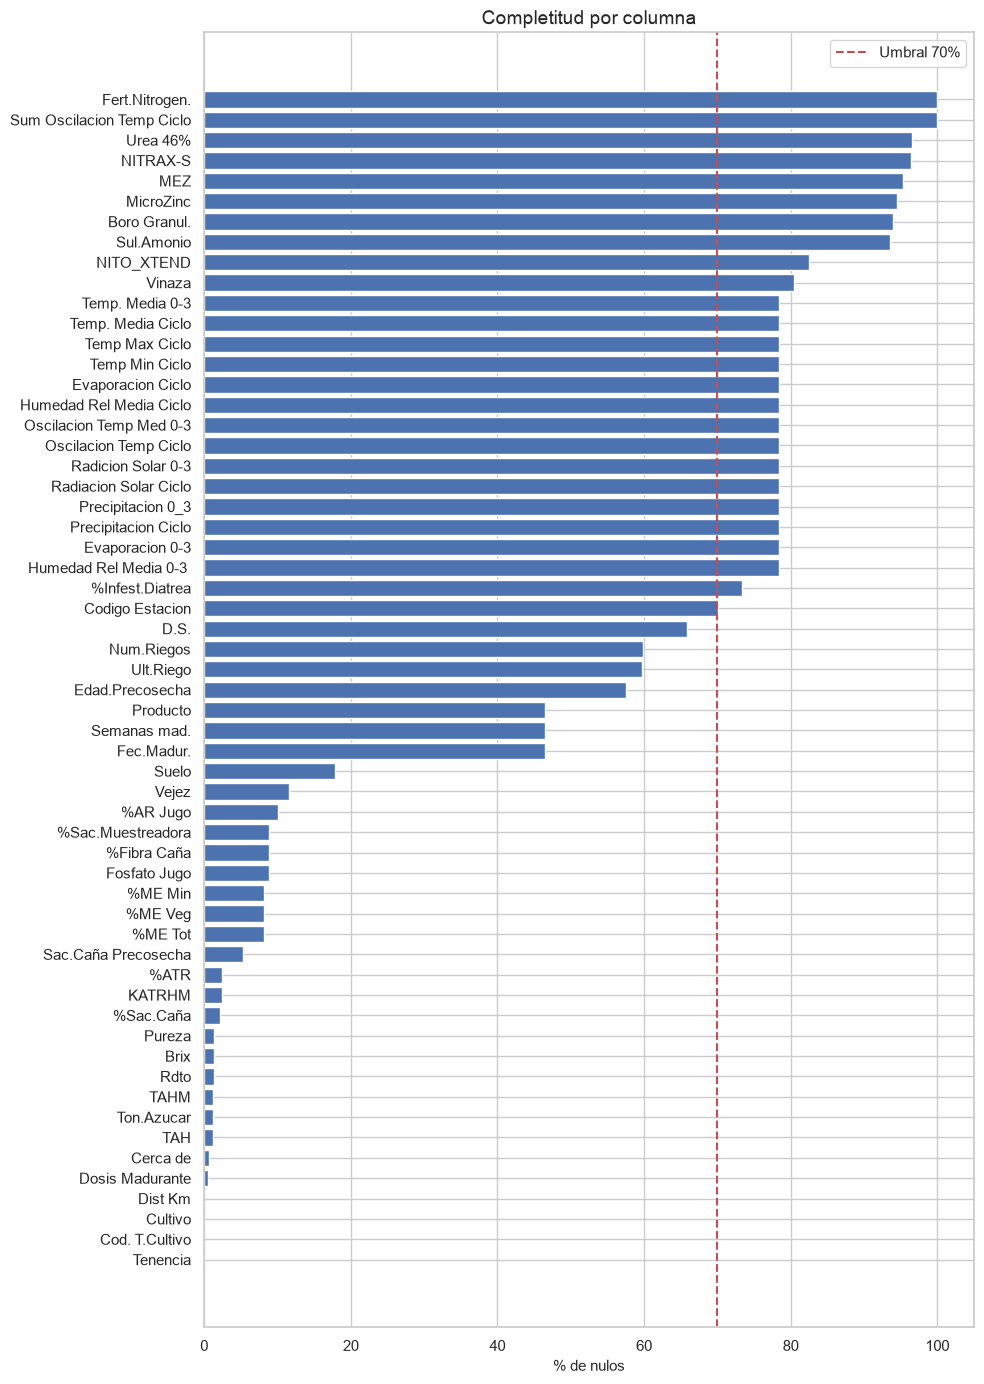


--- Trazabilidad | 3. Completitud ---
Motivo:            nulos ≥ 70%
Columnas antes:    85
Columnas borradas: 26
Columnas quedan:   59
Borradas: ['Fert.Nitrogen.', 'Sum Oscilacion Temp Ciclo', 'Urea 46%', 'NITRAX-S', 'MEZ', 'MicroZinc', 'Boro Granul.', 'Sul.Amonio', 'NITO_XTEND', 'Vinaza', 'Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Evaporacion Ciclo', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Humedad Rel Media 0-3 ', '%Infest.Diatrea', 'Codigo Estacion']
Quedan: ['Período', 'Hacienda', 'Nombre', 'Zona', 'Tenencia', 'Suerte', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'Cod.Estado', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cod. T.Cultivo', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM', 'Ton.

In [7]:
UMBRAL_NULOS = 0.70  # columnas con ≥70 % nulos salen (fertilizantes, estación)

trazabilidad = []


def registrar_recorte(paso, motivo, n_antes, cols_fuera, n_despues):
    """Lleva la cuenta antes / borradas / quedan cada vez que sale un predictor. No modifica el Excel."""
    n_b = len(cols_fuera)
    print(f"\n--- Trazabilidad | {paso} ---")
    print(f"Motivo:            {motivo}")
    print(f"Columnas antes:    {n_antes}")
    print(f"Columnas borradas: {n_b}")
    print(f"Columnas quedan:   {n_despues}")
    trazabilidad.append({
        "paso": paso,
        "motivo": motivo,
        "antes": n_antes,
        "borradas": n_b,
        "quedan": n_despues,
    })

completitud = (
    df_suertes.isna()
    .mean()
    .rename("pct_nulos")
    .to_frame()
    .assign(n_nulos=df_suertes.isna().sum())
    .sort_values("pct_nulos", ascending=False)
)
completitud["pct_nulos"] = completitud["pct_nulos"] * 100

print(f"Columnas con algún nulo: {(completitud['n_nulos'] > 0).sum()} de {len(completitud)}")
print(f"Columnas completas: {(completitud['n_nulos'] == 0).sum()}")
display(completitud[completitud["n_nulos"] > 0])

# Bloques que fallan con el mismo porcentaje (mismo hueco)
con_nulos = completitud[completitud["n_nulos"] > 0]
print("\nColumnas que fallan juntas (mismo % de nulos):")
for pct, g in con_nulos.groupby(con_nulos["pct_nulos"].round(2)):
    if len(g) > 1:
        print(f"  {pct:.2f}% ({len(g)}): {list(g.index)}")

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(con_nulos.index[::-1], con_nulos["pct_nulos"].iloc[::-1], color="#4C72B0")
ax.axvline(UMBRAL_NULOS * 100, color="#C44E52", linestyle="--", label=f"Umbral {UMBRAL_NULOS:.0%}")
ax.set_xlabel("% de nulos")
ax.set_title("Completitud por columna")
ax.legend()
plt.tight_layout()
plt.show()

cols_fuera_nulos = completitud.index[completitud["pct_nulos"] >= UMBRAL_NULOS * 100].tolist()
cols_trabajo_1 = [c for c in df_suertes.columns if c not in cols_fuera_nulos]

registrar_recorte(
    "3. Completitud",
    "nulos ≥ 70%",
    len(df_suertes.columns),
    cols_fuera_nulos,
    len(cols_trabajo_1),
)
print("Borradas:", cols_fuera_nulos)
print("Quedan:", cols_trabajo_1)

**Qué muestra este paso**

Hay **58 columnas con nulos** y **27 completas**. Los faltantes no están repartidos al azar: se ven bloques con el mismo porcentaje, o sea el mismo hueco.

| Bloque | % nulos | Qué es |
|---|---|---|
| Fertilizantes (`Urea 46%`, `MEZ`, boro, zinc, vinaza, …) y `Fert.Nitrogen.` | 80–100% | Insumos casi sin registrar |
| Temperatura, humedad, radiación, evaporación, `Precipitacion Ciclo` | **78.46%** (14 columnas iguales) | Estación meteorológica vacía en ~4 de cada 5 filas |
| `%Infest.Diatrea`, `Codigo Estacion` | 73% y 70% | Plaga y código de la estación que no está |
| `D.S.`, riego (`Num.Riegos`, `Ult.Riego`), `Edad.Precosecha` | 58–66% | Intermedio: se quedan |
| Maduración (`Producto`, `Semanas mad.`, `Fec.Madur.`) | ~46% | Intermedio: se quedan |
| `Suelo` y laboratorio | 2–18% | Poco faltante: se quedan |
| Lluvias del lote (ciclo y ventanas) | **0%** | Clima que sí está medido |

**Decisión.** Umbral **≥ 70% nulos → fuera**. **Antes 85 → se borran 26 → quedan 59** (`cols_trabajo_1`, con los dos targets). Imputar fertilizantes o el clima de estación sería inventar la mayor parte de la serie. Las **lluvias del lote** siguen.

**Qué sigue.** Distinguir identificadores (`Nombre`, `Suerte`, `Hacienda`) de medidas del cultivo, usando cardinalidad y el diccionario.

## 4. Identificadores vs medidas

Sobre `cols_trabajo_1`, se separan columnas que **nombran el lote o la finca** de las que describen el cultivo. Un identificador (p. ej. `Nombre`, `Hacienda`) no aporta mecanismo agronómico. La evidencia aquí es cardinalidad + diccionario, no correlación con el target.


In [8]:
n_filas = len(df_suertes)

cardinalidad = pd.DataFrame({
    "columna": cols_trabajo_1,
    "dtype": [str(df_suertes[c].dtype) for c in cols_trabajo_1],
    "n_unicos": [df_suertes[c].nunique(dropna=True) for c in cols_trabajo_1],
    "n_nulos": [int(df_suertes[c].isna().sum()) for c in cols_trabajo_1],
})
cardinalidad["pct_unicos"] = 100 * cardinalidad["n_unicos"] / n_filas
cardinalidad = cardinalidad.sort_values("n_unicos", ascending=False)
display(cardinalidad)

print("Cod.Estado # vs Cod.Estado (¿es el mismo dato en dos formatos?)")
pares_estado = df_suertes[["Cod.Estado #", "Cod.Estado"]].drop_duplicates().sort_values("Cod.Estado #")
display(pares_estado.head(12))
print("Pares distintos:", len(pares_estado))
print(
    "Máximo textos por código:",
    df_suertes.groupby("Cod.Estado #")["Cod.Estado"].nunique().max(),
    "| Máximo códigos por texto:",
    df_suertes.groupby("Cod.Estado")["Cod.Estado #"].nunique().max(),
)

print("\nCod. T.Cultivo vs Cultivo")
display(df_suertes[["Cod. T.Cultivo", "Cultivo"]].drop_duplicates())

print("\nHacienda vs Nombre")
pares_finca = df_suertes[["Hacienda", "Nombre"]].drop_duplicates()
print("Pares distintos:", len(pares_finca),
      "| Haciendas:", df_suertes["Hacienda"].nunique(),
      "| Nombres:", df_suertes["Nombre"].nunique())

print("\nZona (agrupación geográfica, pocos niveles):")
print(df_suertes["Zona"].value_counts(dropna=False).to_string())

cols_fuera_ids = ["Nombre", "Suerte", "Hacienda", "Cod.Estado", "Cod. T.Cultivo"]
cols_trabajo_2 = [c for c in cols_trabajo_1 if c not in cols_fuera_ids]

registrar_recorte(
    "4. Identificadores",
    "IDs y textos duplicados",
    len(cols_trabajo_1),
    cols_fuera_ids,
    len(cols_trabajo_2),
)
print("Borradas:", cols_fuera_ids)
print("Quedan:", cols_trabajo_2)

,columna,dtype,n_unicos,n_nulos,pct_unicos
26,TCHM,float64,20992,0,99.833547
25,TCH,float64,20931,0,99.543444
36,KATRHM,float64,20505,522,97.517478
24,TonUltCorte,float64,20460,0,97.303467
29,TAH,float64,20444,241,97.227374
30,TAHM,float64,20353,241,96.794597
27,Ton.Azucar,float64,19832,241,94.316831
43,Pureza,float64,16695,269,79.397917
28,Rdto,float64,15448,267,73.467447
41,%ME Tot,float64,15101,1720,71.817187


Cod.Estado # vs Cod.Estado (¿es el mismo dato en dos formatos?)


,Cod.Estado #,Cod.Estado
13,0,Plantilla
8,1,Corte 1
3,2,Corte 2
4,3,Corte 3
2,4,Corte 4
0,5,Corte 5
21,6,Corte 6
23,7,Corte 7
116,8,Corte 8
41,9,Corte 9


Pares distintos: 32
Máximo textos por código: 1 | Máximo códigos por texto: 1

Cod. T.Cultivo vs Cultivo


,Cod. T.Cultivo,Cultivo
0,1.0,Normal
13971,2.0,Organico
18052,NaN,NaN



Hacienda vs Nombre
Pares distintos: 935 | Haciendas: 926 | Nombres: 914

Zona (agrupación geográfica, pocos niveles):
Zona
IP05    7813
IP03    5184
IP06    4113
IP01    2307
IP02    1595
ip05      14
IC07       1

--- Trazabilidad | 4. Identificadores ---
Motivo:            IDs y textos duplicados
Columnas antes:    59
Columnas borradas: 5
Columnas quedan:   54
Borradas: ['Nombre', 'Suerte', 'Hacienda', 'Cod.Estado', 'Cod. T.Cultivo']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num

**Qué muestra este paso**

La cardinalidad parte el set en tres familias:

1. **Identificadores de finca/lote.** `Nombre` (914), `Hacienda` (926) y `Suerte` (1.220) distinguen *quién* es el registro, no cómo se cultivó. El diccionario describe `Nombre` como etiqueta descriptiva. `Hacienda` es el código de esa misma finca (`Nombre` y `Hacienda` van casi 1 a 1). `Suerte` ya es parte de la llave. La ubicación agronómica queda en **`Zona`** (7 niveles: IP01–IP06). `ip05` vs `IP05` es un error de mayúsculas: se unifica en recodificación, no se tira la columna.

2. **El mismo dato dos veces.** `Cod.Estado` y `Cod.Estado #` son 32 pares 1 a 1 (`5` = `Corte 5`). El texto parece un ID; en realidad es la etiqueta del **número de corte**, que sí importa para TCH. Se deja **`Cod.Estado #`** (ordenado: plantilla, corte 1, 2, …) y se saca el texto. Igual con `Cod. T.Cultivo` / `Cultivo` (Normal vs Orgánico): se deja **`Cultivo`**, más legible.

3. **Medidas y categorías de cultivo.** `Zona`, `Tenencia`, `Variedad`, `Suelo`, `T.Corte`, `Tipo Quema`, `Cerca de`, `Período`, etc. tienen pocos niveles o son atributos del ciclo. Siguen, aunque `Cosechó` esté muy concentrado en `AI08`: eso se verá en el univariado.

**Decisión.** Salen del set de predictores: `Nombre`, `Suerte`, `Hacienda`, `Cod.Estado`, `Cod. T.Cultivo`. No se borran del DataFrame (la llave sigue haciendo falta). **Antes 59 → se borran 5 → quedan 54** (`cols_trabajo_2`).

**Qué no se decide aquí.** No se tiran `TCHM`, `Rdto` ni laboratorio: todavía no se miró su relación con el target. Siguiente: univariado de `TCH` y `%Sac.Caña`.


## 5. Calidad de categorías

Antes del univariado se unifican etiquetas rotas (mayúsculas, espacios, el mismo producto con y sin tilde). No se descarta ninguna columna: solo se corrige el texto para no partir una categoría en dos.

In [9]:
def mostrar_conteo(col, titulo):
    """Top 12 de frecuencias (con NA) y cuántos niveles tiene una categoría, para ver typos antes de recodificar."""
    print(titulo)
    print(df_suertes[col].value_counts(dropna=False).head(12).to_string())
    print("Niveles:", df_suertes[col].nunique(dropna=True), "\n")

print("Antes de recodificar\n")
mostrar_conteo("Zona", "Zona")
mostrar_conteo("Cosechó", "Cosechó")
print("Suelo: niveles =", df_suertes["Suelo"].nunique(dropna=True),
      "| filas con espacio al final =",
      int(df_suertes["Suelo"].dropna().astype(str).str.endswith(" ").sum()))
print("\nProducto (dos escrituras de BONUS):")
print(
    df_suertes["Producto"]
    .value_counts(dropna=False)
    .loc[lambda s: s.index.astype(str).str.contains("BONUS", case=False, na=False)]
    .to_string()
)

df_suertes["Zona"] = df_suertes["Zona"].str.upper()
df_suertes["Cosechó"] = df_suertes["Cosechó"].str.upper()
df_suertes["Suelo"] = df_suertes["Suelo"].str.strip()
df_suertes["Producto"] = (
    df_suertes["Producto"]
    .str.replace("FISIOLOGICO", "FISIOLÓGICO", regex=False)
)

print("\nDespués de recodificar\n")
mostrar_conteo("Zona", "Zona")
mostrar_conteo("Cosechó", "Cosechó")
print("Suelo: niveles =", df_suertes["Suelo"].nunique(dropna=True))
print("\nProducto BONUS unificado:")
print(
    df_suertes["Producto"]
    .value_counts(dropna=False)
    .loc[lambda s: s.index.astype(str).str.contains("BONUS", case=False, na=False)]
    .to_string()
)

Antes de recodificar

Zona
Zona
IP05    7813
IP03    5184
IP06    4113
IP01    2307
IP02    1595
ip05      14
IC07       1
Niveles: 7 

Cosechó
Cosechó
AI08    19043
2000     1416
ai08      373
AI01       77
0011       42
0010       18
0001       14
0004       11
2200        9
aI08        9
0006        7
0005        4
Niveles: 14 

Suelo: niveles = 102 | filas con espacio al final = 10932

Producto (dos escrituras de BONUS):
Producto
BONUS 250 EC REGULADOR FISIOLÓGICO    7001
BONUS 250 EC REGULADOR FISIOLOGICO    3380

Después de recodificar

Zona
Zona
IP05    7827
IP03    5184
IP06    4113
IP01    2307
IP02    1595
IC07       1
Niveles: 6 

Cosechó
Cosechó
AI08    19425
2000     1416
AI01       79
0011       42
0010       18
0001       14
0004       11
2200        9
0006        7
0005        4
0003        2
Niveles: 11 

Suelo: niveles = 102

Producto BONUS unificado:
Producto
BONUS 250 EC REGULADOR FISIOLÓGICO    10381


**Qué muestra este paso**

- `Zona`: 14 filas `ip05` pasan a `IP05`. Quedan 6 zonas reales de Providencia (IP01–IP06) y **una fila** `IC07` (posible código de otro ingenio o error). No se borra aún; el univariado dirá si conviene sacarla.
- `Cosechó`: `AI08`, `ai08` y `aI08` son el mismo frente de cosecha. Tras unificar, `AI08` concentra casi todo el histórico.
- `Suelo`: miles de celdas traían espacio al final (`CORINTIAS `). El número de niveles no baja (102), pero las etiquetas quedan comparables. Los nulos (~18%) siguen.
- `Producto`: `BONUS 250 EC REGULADOR FISIOLÓGICO` estaba partido por la tilde. Se unifica; los NA de “no maduró” no se tocan.

**Decisión.** Recodificación in-place sobre `df_suertes`. `cols_trabajo_2` no cambia. Siguiente: marcar, con la evidencia agronómica de la revisión de literatura, cuáles de esas columnas **deberían** ser predictores, antes de mirar correlaciones.


## 6. Candidatos según el contexto de negocio

Los predictores no se eligen solo por estar en el Excel: se cruzan los factores agronómicos de TCH y sacarosa (edad, variedad, suelo, clima, maduración, riego, distancia) con `cols_trabajo_2`. Todavía no se descarta laboratorio ni `Rdto`/`TCHM`: eso espera al análisis de relaciones.


In [10]:
# Factores agronómicos de TCH / sacarosa (edad, variedad, suelo, clima, maduración, riego, distancia)
cols_candidatos = [
    "Edad Ult Cos",
    "F.Siembra",
    "F.Ult.Corte",
    "Cod.Estado #",
    "Variedad",
    "Suelo",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "Producto",
    "Lluvias Ciclo",
    "Lluvias 0 -3",
    "Lluvias tres a seis",
    "Lluvias seis a nueve",
    "Luvias 9 -FC",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos",
    "M3 Riego",
    "Zona",
    "Tenencia",
    "T.Corte",
    "Tipo Quema",
    "Cultivo",
    "Destino 1=Semilla",
    "Período",
]

faltan = [c for c in cols_candidatos if c not in cols_trabajo_2]
cols_candidatos = [c for c in cols_candidatos if c in cols_trabajo_2]
cols_pendientes = [c for c in cols_trabajo_2 if c not in cols_candidatos and c not in ["TCH", "%Sac.Caña"]]

print("Candidatos presentes en el set de trabajo 2:", len(cols_candidatos))
print(cols_candidatos)
if faltan:
    print("\nCandidatos que ya no están (nulos u IDs):", faltan)

print(f"\nOtras columnas aún en juego (laboratorio, toneladas, fechas extra): {len(cols_pendientes)}")
print(cols_pendientes)

mapa_tarea1 = pd.DataFrame({
    "factor_negocio": [
        "Edad del cultivo",
        "Edad (derivar / validar)",
        "Número de corte (soca)",
        "Variedad",
        "Suelo",
        "Distancia al ingenio",
        "Maduración (dosis)",
        "Maduración (semanas)",
        "Clima / lluvias del lote",
        "Riego",
        "Zona / tenencia / manejo",
    ],
    "columnas": [
        "Edad Ult Cos",
        "F.Siembra, F.Ult.Corte",
        "Cod.Estado #",
        "Variedad",
        "Suelo",
        "Dist Km",
        "Dosis Madurante, Producto",
        "Semanas mad.",
        "Lluvias Ciclo y ventanas; Lluvias (2 Meses Ant.) para sacarosa",
        "Num.Riegos, M3 Riego",
        "Zona, Tenencia, T.Corte, Tipo Quema, Cultivo, Destino 1=Semilla, Período",
    ],
})
display(mapa_tarea1)

Candidatos presentes en el set de trabajo 2: 25
['Edad Ult Cos', 'F.Siembra', 'F.Ult.Corte', 'Cod.Estado #', 'Variedad', 'Suelo', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'Producto', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC', 'Lluvias (2 Meses Ant.)', 'Num.Riegos', 'M3 Riego', 'Zona', 'Tenencia', 'T.Corte', 'Tipo Quema', 'Cultivo', 'Destino 1=Semilla', 'Período']

Otras columnas aún en juego (laboratorio, toneladas, fechas extra): 27
['Area Neta', 'D.S.', 'Ult.Riego', 'Fec.Madur.', 'TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'Cerca de', 'Cosechó', 'DDUlt.Riego', 'Fosfato Jugo']


,factor_negocio,columnas
0,Edad del cultivo,Edad Ult Cos
1,Edad (derivar / validar),"F.Siembra, F.Ult.Corte"
2,Número de corte (soca),Cod.Estado #
3,Variedad,Variedad
4,Suelo,Suelo
5,Distancia al ingenio,Dist Km
6,Maduración (dosis),"Dosis Madurante, Producto"
7,Maduración (semanas),Semanas mad.
8,Clima / lluvias del lote,Lluvias Ciclo y ventanas; Lluvias (2 Meses Ant...
9,Riego,"Num.Riegos, M3 Riego"


**Qué muestra este paso**

Los factores agronómicos (clima, suelo, variedad, edad, riego, maduración) **sí tienen columnas** en este Excel, salvo fertilización: esa salió en el paso 3 por 80–100% nulos. Limitación del dato, no del planteamiento.

En `cols_candidatos` quedan `Edad Ult Cos`, `Variedad`, `Suelo`, `Dist Km`, `Dosis Madurante`, `Semanas mad.`, `F.Siembra`. Las lluvias del lote sustituyen a la estación vacía. `F.Siembra` y `F.Ult.Corte` sirven para **validar** la edad, no como 1.400 fechas crudas en el lineal.

Lo demás en `cols_pendientes` (TCHM, TAH, Rdto, Brix, ATR, toneladas, vejez, etc.) no se tira aquí. Puede ser resultado de la misma cosecha: eso se ve en correlaciones y scatters.

**Decisión.** El EDA profundo se concentra en `cols_candidatos` + los dos targets. El resto se revisa en relaciones para justificar descarte. Siguiente: histogramas y boxplots de `TCH` y `%Sac.Caña` (¿normales? ¿outliers de error o de rendimiento extremo?).


## 7. Distribuciones de `TCH` y `%Sac.Caña`

Se inspeccionan forma y colas de los dos targets: si se parecen a una normal, y si los atípicos son errores de registro o cosechas realmente altas/bajas. El TCH extremo se cruza con área y destino (caña vs semilla).


,n,nulos,media,mediana,desv,min,max,asimetría,IQR,límite inf.,límite sup.,n outliers IQR,% outliers,Shapiro W (n=5000),Shapiro p
TCH,21027.0,0,129.608509,129.47960,32.846029,1.573653,401.045947,0.127109,41.716181,46.117155,212.981878,304.0,1.445760,0.996684,4.191008e-09
%Sac.Caña,20578.0,449,12.320202,12.37065,1.145738,7.086000,18.400000,-0.257637,1.468500,9.416250,15.290250,313.0,1.521042,0.994652,1.149441e-12


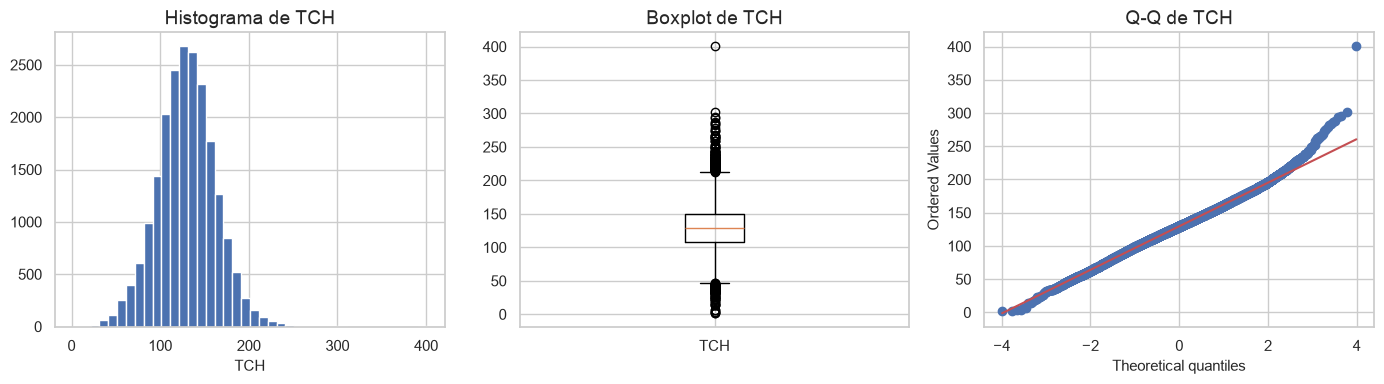

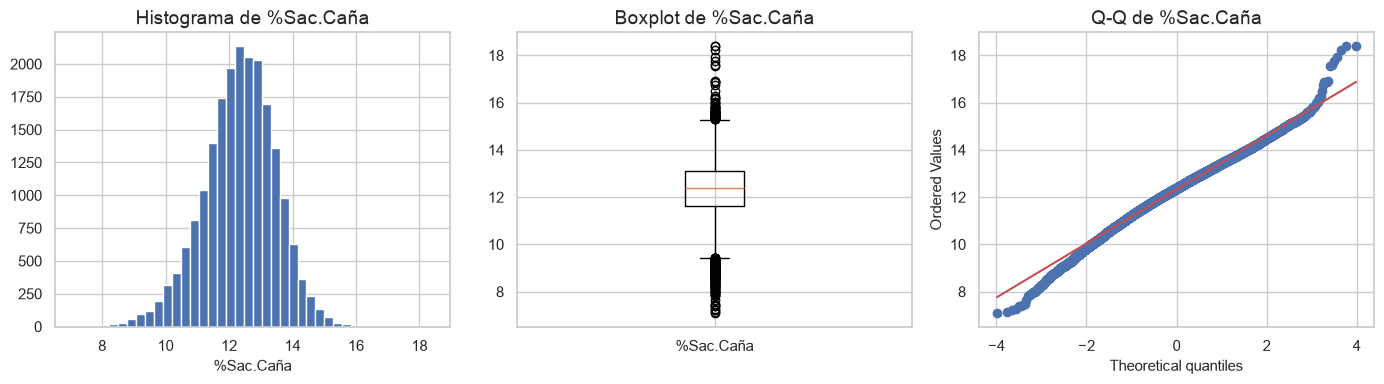

Máxima diferencia |TCH − TonUltCorte/Area Neta|: 9.99637819631971e-07

Outliers IQR de TCH: 304  |  TCH < 50: 172  |  TCH > 250: 28
Más bajos:


,Nombre,Suerte,Período,Area Neta,TonUltCorte,TCH,%Sac.Caña,Destino 1=Semilla,Edad Ult Cos,Variedad
7061,EL JAPON,550,201903,15.41,24.25,1.573653,NaN,1,11.37,RB73-2223
7867,PARANÁ SERVIAGRO,012,201911,2.52,4.62,1.833333,NaN,1,8.25,CC09-235
3208,EL TESORO,002,201803,6.32,19.31,3.055379,11.737,0,5.85,CC85-92
20864,LA PAZ,081H,202406,0.19,0.65,3.421052,NaN,1,9.40,CC09-535
3709,EL TESORITO CAMPOX,130,201805,15.71,94.09,5.989178,11.232,0,15.18,CC01-1940
20681,LA MERCED GARCES,001A,202405,0.38,2.45,6.447368,11.715,0,12.02,CC09-702


Más altos:


,Nombre,Suerte,Período,Area Neta,TonUltCorte,TCH,%Sac.Caña,Destino 1=Semilla,Edad Ult Cos,Variedad
2509,MADROÑAL CASAS INCAUCA,014A,201712,0.10,28.5900,285.900000,12.0390,0,12.91,CC85-92
15645,SAN PABLO AZCARATE,009B,202209,2.00,575.7550,287.877500,10.8830,0,10.45,CC05-430
11535,BETANIA,328,202103,0.88,258.6000,293.863636,9.9326,0,11.56,CC97-7170
8115,FUNDUNGO INVENSA,410,201912,4.99,1471.1500,294.819639,11.7948,0,12.39,PR61-632
5545,LA UNION 1,006B,201901,1.00,301.6080,301.608000,13.6811,0,14.00,CC01-1940
10931,MARSELLA,512B,202012,1.53,613.6003,401.045947,NaN,1,9.89,CC01-1940



TCH medio según destino (0 = molino, 1 = semilla):


,count,mean,50%,min,max
Destino 1=Semilla,,,,,
0,20733.0,130.076288,129.819548,3.055379,301.608000
1,294.0,96.620507,96.734686,1.573653,401.045947



Outliers IQR de %Sac.Caña: 313  |  < 9.42: 244  |  > 15.29: 69
Más bajos:


,Nombre,Suerte,Período,TCH,%Sac.Caña,Dosis Madurante,Tipo Quema,T.Corte,Destino 1=Semilla
18040,ESPERANZA INESA,350B,202306,99.914772,7.0860,0.0,Q.ACCIDENTAL,MECANIZADO,0
2755,EL RANCHO EMPRESA,005A,201801,132.632352,7.1440,0.0,VERDE,MECANIZADO,0
15390,LA PALOMERA OSORIO,001E,202208,107.077777,7.2100,1.2,Q.ACCIDENTAL,MANUAL,0
19949,ZABALETAS EMPRESA,009A,202402,109.557142,7.2700,0.0,NO DEF.,MECANIZADO,0
2513,GALICIA,333,201712,156.200396,7.3761,1.3,VERDE,MECANIZADO,0
1163,LA MARIA MEJIA,001,201707,82.633040,7.4017,0.0,Q.ACCIDENTAL,MECANIZADO,0


Más altos:


,Nombre,Suerte,Período,TCH,%Sac.Caña,Dosis Madurante,Tipo Quema,T.Corte,Destino 1=Semilla
18312,LA LOMA,005,202307,94.450909,17.58,1.2,Q.ACCIDENTAL,MANUAL,0
12903,MALABAR,005A,202110,126.616369,17.77,0.0,VERDE,MECANIZADO,0
12926,MALABAR,001,202110,95.569262,17.92,0.0,VERDE,MECANIZADO,0
12873,AGRICOLA DON MIGUEL,001,202109,119.609911,18.21,0.0,VERDE,MANUAL,0
13040,MALABAR,006A,202110,94.174000,18.39,0.0,VERDE,MECANIZADO,0
12925,MALABAR,002,202110,109.033882,18.40,0.0,VERDE,MECANIZADO,0


In [11]:
def resumen_target(s):
    """Centro, dispersión, outliers IQR (k=1.5) y Shapiro-Wilk sobre una muestra de hasta 5.000 (el test no admite n≈21.000)."""
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    muestra = s.sample(min(5000, len(s)), random_state=0)
    w, p = stats.shapiro(muestra)
    return {
        "n": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "desv": s.std(),
        "min": s.min(),
        "max": s.max(),
        "asimetría": s.skew(),
        "IQR": iqr,
        "límite inf.": lo,
        "límite sup.": hi,
        "n outliers IQR": n_out,
        "% outliers": 100 * n_out / len(s),
        "Shapiro W (n=5000)": w,
        "Shapiro p": p,
    }


resumen = pd.DataFrame({
    "TCH": resumen_target(df_suertes["TCH"]),
    "%Sac.Caña": resumen_target(df_suertes["%Sac.Caña"]),
}).T
resumen.insert(1, "nulos", [df_suertes["TCH"].isna().sum(), df_suertes["%Sac.Caña"].isna().sum()])
display(resumen)

def graficar_target(s, nombre):
    """Histograma, boxplot y Q-Q normal del target (sin nulos). El Q-Q es el supuesto de normalidad a ojo."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(s, bins=40, color="#4C72B0", edgecolor="white")
    axes[0].set_title(f"Histograma de {nombre}")
    axes[0].set_xlabel(nombre)
    axes[1].boxplot(s, orientation="vertical", tick_labels=[nombre])
    axes[1].set_title(f"Boxplot de {nombre}")
    stats.probplot(s, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q de {nombre}")
    plt.tight_layout()
    plt.show()


graficar_target(df_suertes["TCH"].dropna(), "TCH")
graficar_target(df_suertes["%Sac.Caña"].dropna(), "%Sac.Caña")

# El TCH coincide con toneladas / ha; los extremos se miran con área y destino
df_suertes["_tch_calc"] = df_suertes["TonUltCorte"] / df_suertes["Area Neta"]
print(
    "Máxima diferencia |TCH − TonUltCorte/Area Neta|:",
    (df_suertes["TCH"] - df_suertes["_tch_calc"]).abs().max(),
)

q1, q3 = df_suertes["TCH"].quantile(0.25), df_suertes["TCH"].quantile(0.75)
lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
extremos = df_suertes.loc[
    (df_suertes["TCH"] < lo) | (df_suertes["TCH"] > hi),
    ["Nombre", "Suerte", "Período", "Area Neta", "TonUltCorte", "TCH", "%Sac.Caña",
     "Destino 1=Semilla", "Edad Ult Cos", "Variedad"],
].sort_values("TCH")
print(f"\nOutliers IQR de TCH: {len(extremos)}  |  TCH < 50: {(df_suertes['TCH'] < 50).sum()}  |  TCH > 250: {(df_suertes['TCH'] > 250).sum()}")
print("Más bajos:")
display(extremos.head(6))
print("Más altos:")
display(extremos.tail(6))

print("\nTCH medio según destino (0 = molino, 1 = semilla):")
display(df_suertes.groupby("Destino 1=Semilla")["TCH"].describe()[["count", "mean", "50%", "min", "max"]])

q1s, q3s = df_suertes["%Sac.Caña"].quantile(0.25), df_suertes["%Sac.Caña"].quantile(0.75)
lo_s, hi_s = q1s - 1.5 * (q3s - q1s), q3s + 1.5 * (q3s - q1s)
extremos_sac = df_suertes.loc[
    df_suertes["%Sac.Caña"].notna()
    & ((df_suertes["%Sac.Caña"] < lo_s) | (df_suertes["%Sac.Caña"] > hi_s)),
    ["Nombre", "Suerte", "Período", "TCH", "%Sac.Caña", "Dosis Madurante",
     "Tipo Quema", "T.Corte", "Destino 1=Semilla"],
].sort_values("%Sac.Caña")
print(
    f"\nOutliers IQR de %Sac.Caña: {len(extremos_sac)}"
    f"  |  < {lo_s:.2f}: {(df_suertes['%Sac.Caña'] < lo_s).sum()}"
    f"  |  > {hi_s:.2f}: {(df_suertes['%Sac.Caña'] > hi_s).sum()}"
)
print("Más bajos:")
display(extremos_sac.head(6))
print("Más altos:")
display(extremos_sac.tail(6))

df_suertes = df_suertes.drop(columns=["_tch_calc"])

**Qué muestra este paso**

**¿Son normales?** A ojo, ambas son **casi simétricas** (TCH asimetría 0.13; sacarosa −0.26). Media y mediana del TCH coinciden (~130 t/ha). El Q-Q se sale en las colas. Shapiro rechaza con n = 5.000: con tantas filas cualquier desviación mínima da p ≈ 0. No son gaussianas estrictas; para el lineal importan más los **residuos** que el histograma del target.

**Outliers (regla IQR, ~1.5% en cada target).** No se borran por fórmula.

- El TCH **es** `TonUltCorte / Area Neta` (diferencia ~0): no hay error de fórmula.
- TCH muy **bajo** (< 30–50) aparece mucho en `Destino 1=Semilla`. Es otro uso del lote (semillero), no un fallo de captura. Por eso `Destino 1=Semilla` está en candidatos.
- TCH muy **alto** (250–401) suele ser **área chica** (0.1–2 ha). El 401 t/ha es 1.53 ha y destino semilla, sin `%Sac.Caña`. Es influyente; no se elimina todavía. El lineal se puede evaluar con MAE (más robusto que RMSE ante esos puntos).
- `%Sac.Caña` va de 7.1 a 18.4 (media 12.3). Cola baja a menudo con quema accidental y dosis 0; cola alta en verde. Parece calidad real, no un typo.

**Decisión.** Se dejan todos los valores. El modelo de TCH usa 21.027 filas; el de sacarosa, 20.578. Siguiente: validar `Edad Ult Cos` contra `F.Siembra` y `F.Ult.Corte`.


--- 1. Correlación entre targets (n = 20578 ) ---
Pearson = -0.168 (r² = 0.028) | Spearman = -0.188

--- 2. Consistencia interna: ¿se sostiene sin semilla y por cultivo? ---
Solo molino (Destino = 0): Pearson = -0.168 | n = 20577
  Normal: Pearson = -0.173 | n = 19888
  Organico: Pearson = -0.039 | n = 687

%Sac.Caña media por decil de TCH:


,TCH_mediana,Sac_media,n
TCH,,,
"(3.0540000000000003, 89.363]",76.36,12.41,2058
"(89.363, 103.873]",97.88,12.58,2058
"(103.873, 113.77]",109.22,12.54,2058
"(113.77, 121.956]",118.09,12.48,2057
"(121.956, 129.77]",125.93,12.43,2058
"(129.77, 137.572]",133.55,12.35,2058
"(137.572, 145.928]",141.63,12.28,2057
"(145.928, 155.94]",150.56,12.22,2058
"(155.94, 170.638]",162.46,12.10,2058


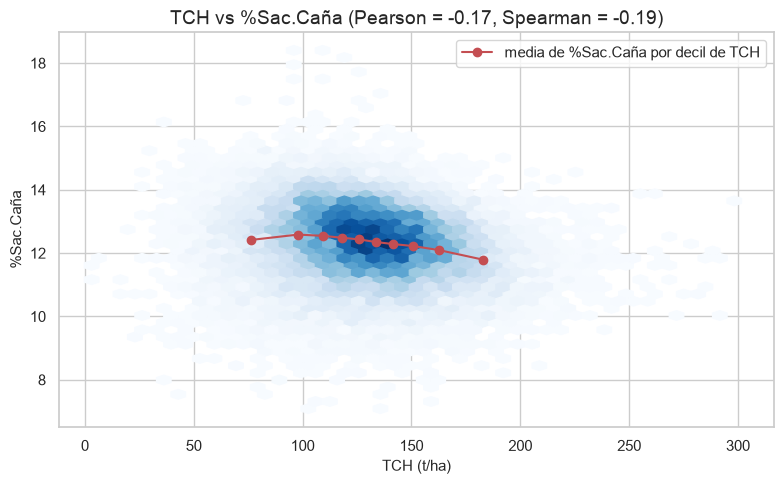

In [12]:
# Relación entre los dos targets: TCH (cantidad) vs %Sac.Caña (calidad).
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes; usa las filas con ambos targets.
u_t = df_suertes[["TCH", "%Sac.Caña", "Destino 1=Semilla", "Cultivo"]].dropna(subset=["TCH", "%Sac.Caña"])
u_r_p = u_t["TCH"].corr(u_t["%Sac.Caña"], method="pearson")
u_r_s = u_t["TCH"].corr(u_t["%Sac.Caña"], method="spearman")
print("--- 1. Correlación entre targets (n =", len(u_t), ") ---")
print(f"Pearson = {u_r_p:.3f} (r² = {u_r_p**2:.3f}) | Spearman = {u_r_s:.3f}")

print("\n--- 2. Consistencia interna: ¿se sostiene sin semilla y por cultivo? ---")
u_mol = u_t[u_t["Destino 1=Semilla"] == 0]
print("Solo molino (Destino = 0): Pearson =", round(u_mol["TCH"].corr(u_mol["%Sac.Caña"]), 3), "| n =", len(u_mol))
for u_cul, u_g in u_mol.groupby("Cultivo"):
    print(f"  {u_cul}: Pearson = {u_g['TCH'].corr(u_g['%Sac.Caña']):.3f} | n = {len(u_g)}")

u_dec = pd.qcut(u_t["TCH"], 10, duplicates="drop")
u_tab = u_t.groupby(u_dec, observed=True).agg(
    TCH_mediana=("TCH", "median"), Sac_media=("%Sac.Caña", "mean"), n=("TCH", "size"))
print("\n%Sac.Caña media por decil de TCH:")
display(u_tab.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hexbin(u_t["TCH"], u_t["%Sac.Caña"], gridsize=45, cmap="Blues", mincnt=1)
ax.plot(u_tab["TCH_mediana"], u_tab["Sac_media"], color="#C44E52", marker="o",
        label="media de %Sac.Caña por decil de TCH")
ax.set_xlabel("TCH (t/ha)")
ax.set_ylabel("%Sac.Caña")
ax.set_title(f"TCH vs %Sac.Caña (Pearson = {u_r_p:.2f}, Spearman = {u_r_s:.2f})")
ax.legend()
plt.tight_layout()
plt.show()


**Relación entre `TCH` y `%Sac.Caña`**

Cantidad y calidad son objetivos distintos; antes de modelar se mide cuánto se parecen.

Con n = **20.578** filas que tienen ambos targets, Pearson = **−0.168** (r² = **0.028**) y Spearman = **−0.188**. El TCH explica solo el **2.8 %** de la variación de la sacarosa: la asociación es débil y negativa.

Sin semillero (Destino = 0, n = **20.577**) Pearson sigue en **−0.168**. Por cultivo (mismo subconjunto): `Normal` **−0.173** (n = 19.888) y `Organico` **−0.039** (n = 687). El signo se mantiene; en orgánico la magnitud se acerca a cero.

Por decil de TCH, la `%Sac.Caña` media pasa de **12.41** en el decil bajo (TCH mediana **76.36**) a **11.79** en el alto (mediana **182.80**). Más caña no implica más dulce: en los lotes más productivos la sacarosa media es un poco menor.

Los predictores tampoco coinciden (paso 10, tablas `corr_tch` y `corr_sac`): `Edad Ult Cos` Pearson **0.298** vs TCH y no entra al top 15 vs sacarosa; `Dosis Madurante` Pearson **0.288** vs `%Sac.Caña` y no entra al top 15 vs TCH.

**Decisión.** TCH y `%Sac.Caña` se modelan como dos problemas separados; no se usa un target como predictor del otro; el set candidato de X es común, y cada modelo pesa las X a su manera: los coeficientes de los pasos 18–23 muestran qué predictores importan para cada target. Confianza **Alta** (r² = 2.8 %).

**¿Cambia esto las secciones 18–23?** No: ya son dos regresiones separadas con las mismas X. **No se reescribe el resto del notebook.**


## 8. Edad: `Edad Ult Cos` vs fechas de siembra y corte

Se calcula la edad en meses desde `F.Siembra` hasta `F.Ult.Corte` y se compara con `Edad Ult Cos` (completa, 0 nulos). La pregunta es si son el mismo concepto o dos edades distintas.


,count,mean,std,min,25%,50%,75%,max
Edad Ult Cos,21027.0,13.011110,1.979070,1.310000,11.930000,12.620000,13.860000,78.190000
edad_desde_siembra,21027.0,67.568387,52.054611,5.519507,29.913758,53.880903,86.899384,410.184805
diferencia,21027.0,-54.557277,52.127486,-396.814805,-74.050893,-40.636448,-16.094620,-0.027864


Correlación Edad Ult Cos vs meses desde siembra: -0.018
Correlación meses desde siembra vs n.º de corte: 0.962


,n,Edad Ult Cos (media),meses desde siembra (media),MAE
Cod.Estado #,,,,
0,2677.0,13.686802,14.033902,0.347100
1,2823.0,13.061219,27.075174,14.013955
2,2925.0,12.911874,40.239240,27.327367
3,2820.0,12.931195,52.478471,39.547276
4,2378.0,12.822267,65.101846,52.279579
5,1791.0,12.930469,77.223021,64.292552
6,1337.0,12.823455,90.325289,77.501834
7,1006.0,12.830994,101.884202,89.053208


Plantilla (corte 0): n=2677 | % con |diff| < 0.2 meses: 97.7% | MAE=0.347


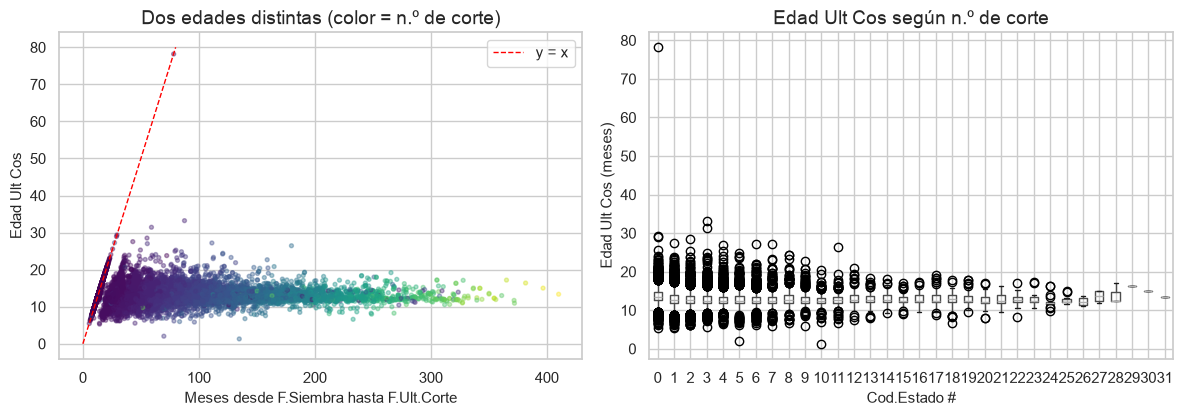

In [13]:
df_suertes["edad_desde_siembra"] = (
    (df_suertes["F.Ult.Corte"] - df_suertes["F.Siembra"]).dt.days / (365.25 / 12)
)

cmp_edad = pd.DataFrame({
    "Edad Ult Cos": df_suertes["Edad Ult Cos"],
    "edad_desde_siembra": df_suertes["edad_desde_siembra"],
})
cmp_edad["diferencia"] = cmp_edad["Edad Ult Cos"] - cmp_edad["edad_desde_siembra"]
display(cmp_edad.describe().T)

print("Correlación Edad Ult Cos vs meses desde siembra:",
      round(df_suertes["Edad Ult Cos"].corr(df_suertes["edad_desde_siembra"]), 3))
print("Correlación meses desde siembra vs n.º de corte:",
      round(df_suertes["edad_desde_siembra"].corr(df_suertes["Cod.Estado #"]), 3))

por_corte = (
    df_suertes.groupby("Cod.Estado #")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "Edad Ult Cos (media)": g["Edad Ult Cos"].mean(),
            "meses desde siembra (media)": g["edad_desde_siembra"].mean(),
            "MAE": (g["Edad Ult Cos"] - g["edad_desde_siembra"]).abs().mean(),
        }),
        include_groups=False,
    )
    .head(8)
)
display(por_corte)

plantilla = df_suertes["Cod.Estado #"] == 0
dif_plant = (df_suertes.loc[plantilla, "Edad Ult Cos"] - df_suertes.loc[plantilla, "edad_desde_siembra"]).abs()
print(
    f"Plantilla (corte 0): n={int(plantilla.sum())} | "
    f"% con |diff| < 0.2 meses: {100 * (dif_plant < 0.2).mean():.1f}% | "
    f"MAE={dif_plant.mean():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(
    df_suertes["edad_desde_siembra"],
    df_suertes["Edad Ult Cos"],
    c=df_suertes["Cod.Estado #"],
    cmap="viridis",
    s=8,
    alpha=0.4,
)
axes[0].plot([0, 80], [0, 80], color="red", linestyle="--", linewidth=1, label="y = x")
axes[0].set_xlabel("Meses desde F.Siembra hasta F.Ult.Corte")
axes[0].set_ylabel("Edad Ult Cos")
axes[0].set_title("Dos edades distintas (color = n.º de corte)")
axes[0].legend()

df_suertes.boxplot(column="Edad Ult Cos", by="Cod.Estado #", ax=axes[1])
axes[1].set_title("Edad Ult Cos según n.º de corte")
axes[1].set_xlabel("Cod.Estado #")
axes[1].set_ylabel("Edad Ult Cos (meses)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Qué muestra este paso**

No son la misma variable. Restar fechas **no reproduce** `Edad Ult Cos` (correlación ≈ 0; la derivada llega a 400 meses).

- **`Edad Ult Cos`** ≈ 13 meses en todos los cortes: edad de **este ciclo** (siembra o último corte → cosecha).
- **Meses desde `F.Siembra`** crece con `Cod.Estado #` (corr ≈ 0.96): edad de la **cepa** desde que se plantó el lote (1986…), no la del tallo que se está cortando.

Solo en **plantilla (corte 0)** coinciden: 97.6% de las filas con diferencia &lt; 0.2 meses. En corte 1 en adelante la cepa ya lleva varios ciclos y las fechas de siembra ya no son la edad a cosecha.

**Decisión.** El predictor agronómico de productividad de *este* corte es **`Edad Ult Cos`**. `F.Siembra` y `F.Ult.Corte` no entran crudas al lineal. Se deja `edad_desde_siembra` como variable derivada (edad de cepa), casi redundante con el número de corte: el VIF dirá si se puede usar junto a `Cod.Estado #`.

Siguiente: univariado del resto de `cols_candidatos` (zona, variedad, suelo, lluvias, madurante, riego).


## 9. Univariado de los candidatos

Distribución de las variables señaladas como predictores agronómicos (salvo la edad, ya vista). Interesa cómo están partidas las categorías, si hay colas raras y si un **cero** es dato real o un nulo disfrazado (dosis, riego, lluvias).


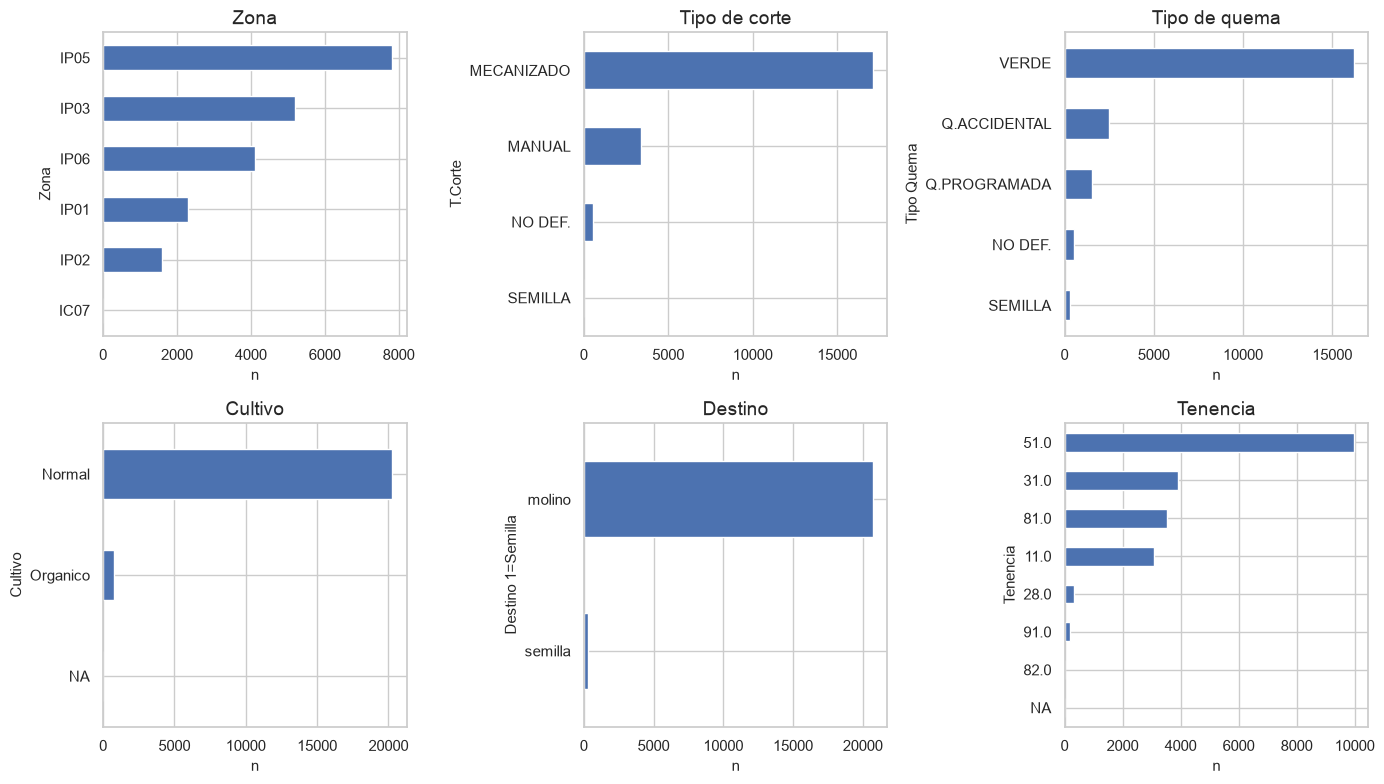

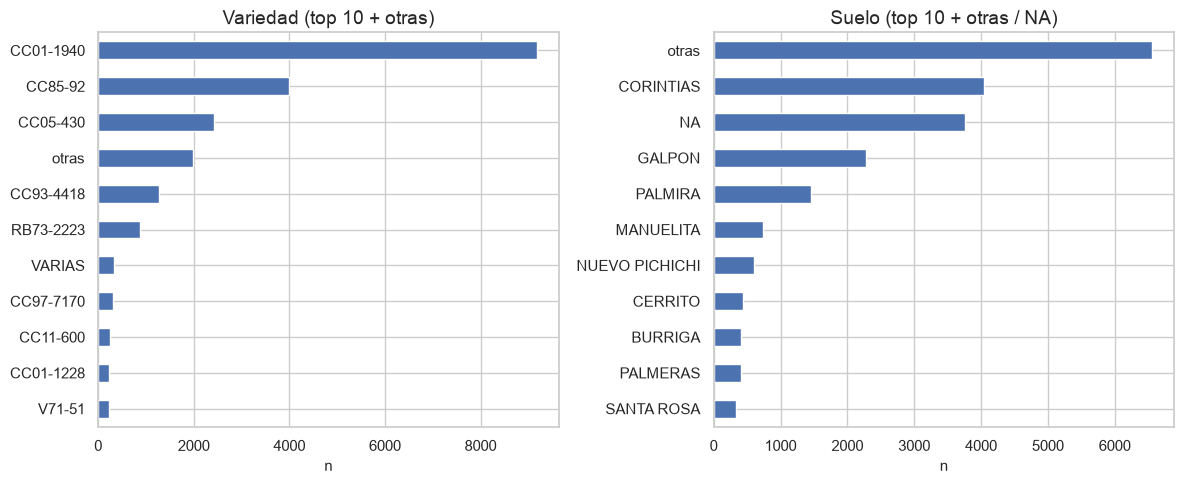

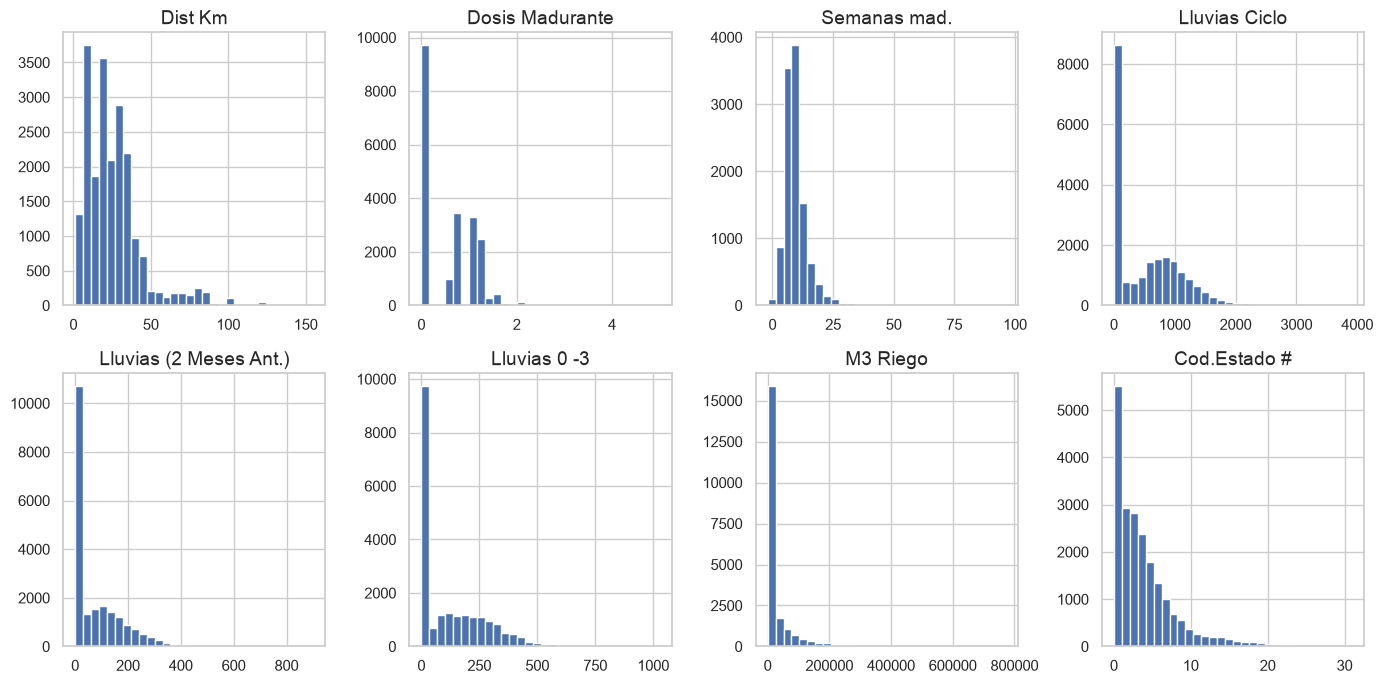

,columna,nulos,% nulos,ceros
0,Dosis Madurante,104,0.494602,9685.0
1,Semanas mad.,9775,46.487849,2.0
2,Producto,9778,46.502116,NaN
3,Num.Riegos,12589,59.870643,0.0
4,M3 Riego,0,0.000000,12557.0
5,Lluvias Ciclo,0,0.000000,7739.0
6,Lluvias (2 Meses Ant.),0,0.000000,10064.0
7,Suelo,3758,17.872259,NaN


Dosis = 0 y Producto nulo: 9671
Dosis nula y Producto nulo: 104
Num.Riegos nulo y M3 Riego = 0: 12557
Num.Riegos nulo y M3 Riego > 0: 32
Semanas mad. < 0: 13
Variedad CC01-1940: 43.6%


In [14]:
def barras_top(serie, titulo, ax, top=10, incluir_na=True):
    """Barras de los `top` niveles más frecuentes; el resto se funde en 'otras'. Por defecto top=10 e incluye NA."""
    vc = serie.value_counts(dropna=False) if incluir_na else serie.value_counts(dropna=True)
    vc.index = vc.index.map(lambda x: "NA" if pd.isna(x) else str(x))
    if len(vc) > top:
        otros = vc.iloc[top:].sum()
        vc = pd.concat([vc.iloc[:top], pd.Series({"otras": otros})])
    vc.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(titulo)
    ax.set_xlabel("n")


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
barras_top(df_suertes["Zona"], "Zona", axes[0, 0], top=10)
barras_top(df_suertes["T.Corte"], "Tipo de corte", axes[0, 1], top=10)
barras_top(df_suertes["Tipo Quema"], "Tipo de quema", axes[0, 2], top=10)
barras_top(df_suertes["Cultivo"], "Cultivo", axes[1, 0], top=10)
barras_top(df_suertes["Destino 1=Semilla"].map({0: "molino", 1: "semilla"}), "Destino", axes[1, 1], top=10)
barras_top(df_suertes["Tenencia"], "Tenencia", axes[1, 2], top=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
barras_top(df_suertes["Variedad"], "Variedad (top 10 + otras)", axes[0], top=10)
barras_top(df_suertes["Suelo"], "Suelo (top 10 + otras / NA)", axes[1], top=10)
plt.tight_layout()
plt.show()

num_univar = [
    "Dist Km", "Dosis Madurante", "Semanas mad.",
    "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Lluvias 0 -3",
    "M3 Riego", "Cod.Estado #",
]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_univar):
    s = df_suertes[col].dropna()
    ax.hist(s, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

cero_na = []
for col in ["Dosis Madurante", "Semanas mad.", "Producto", "Num.Riegos", "M3 Riego",
            "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Suelo"]:
    s = df_suertes[col]
    n_na = int(s.isna().sum())
    n_cero = int((s == 0).sum()) if pd.api.types.is_numeric_dtype(s) else np.nan
    cero_na.append({"columna": col, "nulos": n_na, "% nulos": 100 * n_na / len(df_suertes),
                    "ceros": n_cero})
display(pd.DataFrame(cero_na))

print("Dosis = 0 y Producto nulo:", int(((df_suertes["Dosis Madurante"] == 0) & df_suertes["Producto"].isna()).sum()))
print("Dosis nula y Producto nulo:", int((df_suertes["Dosis Madurante"].isna() & df_suertes["Producto"].isna()).sum()))
print("Num.Riegos nulo y M3 Riego = 0:", int((df_suertes["Num.Riegos"].isna() & (df_suertes["M3 Riego"] == 0)).sum()))
print("Num.Riegos nulo y M3 Riego > 0:", int((df_suertes["Num.Riegos"].isna() & (df_suertes["M3 Riego"] > 0)).sum()))
print("Semanas mad. < 0:", int((df_suertes["Semanas mad."] < 0).sum()))
print("Variedad CC01-1940:", f"{100 * (df_suertes['Variedad'] == 'CC01-1940').mean():.1f}%")

**Qué muestra este paso**

**Categorías.** Cosecha sobre todo mecanizada y en verde. Destino semilla es raro (294 filas), coherente con los TCH extremos. `Cultivo` orgánico es ~3.6%. `Zona` está desbalanceada (IP05 domina; `IC07` es 1 fila). `Variedad`: 58 niveles, pero **CC01-1940** es el 43.6% y las 5 más frecuentes ~84% — en el lineal habrá que agrupar cola en “otras”. `Suelo`: 102 tipos y **3.758 NA**; también agrupar.

**Cero vs nulo (calidad, para imputar después).**

- **Maduración:** dosis 0 (9.685) coincide casi con `Producto` nulo. “Sin dato” / dosis 0 = **no se maduró**. Los 104 NA de dosis son el mismo caso. `Semanas mad.` nula en paralelo; hay valores **negativos** (error puntual).
- **Riego:** `Num.Riegos` nulo cuando `M3 Riego` = 0 (12.557 filas). El nulo es **cero riegos**, no un hueco al azar. Solo 32 filas tienen m³ > 0 y número nulo.
- **Lluvias:** 0 nulos, pero muchos ceros (`Lluvias Ciclo` 7.739; dos meses antes 10.064). Puede ser sequía o estación en cero; se mira en el bivariado con TCH/sacarosa, no se imputa.

**Decisión.** Los candidatos siguen. Recodificaciones pendientes para el modelo: agrupar variedades y suelos raros; `Dosis Madurante` NA → 0; `Num.Riegos` NA → 0 si m³ = 0. Eso se formaliza en imputación. Siguiente: **relaciones** con cada target (TCH vs edad; sacarosa vs lluvias de maduración; matriz de correlación). Ahí se decide qué es fuga (`Rdto`, `TCHM`, laboratorio).


In [15]:
# Verificación de unidades. Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
cols_unidades = ["Edad Ult Cos", "Dosis Madurante", "Lluvias Ciclo", "Lluvias (2 Meses Ant.)", "Area Neta"]
print("--- 1. Perfil (rango observado) ---")
display(df_suertes[cols_unidades].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(3))
print("Nulos:", df_suertes[cols_unidades].isna().sum().to_dict())
print("Ceros:", {c: int((df_suertes[c] == 0).sum()) for c in cols_unidades})

print("\nEdad Ult Cos: p5–p95 =",
      round(df_suertes["Edad Ult Cos"].quantile(0.05), 2), "–",
      round(df_suertes["Edad Ult Cos"].quantile(0.95), 2),
      "| min/max =", df_suertes["Edad Ult Cos"].min(), df_suertes["Edad Ult Cos"].max())
print("  ¿Cabe en meses 10–18? masa en p5–p95 sí. ¿Semanas 40–75? no (mediana 12.6). ¿Días 300–550? no.")

print("\nDosis Madurante > 0:")
display(df_suertes.loc[df_suertes["Dosis Madurante"] > 0, "Dosis Madurante"]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T.round(3))

print("\n--- 2. Consistencia interna ---")
plant = df_suertes["Cod.Estado #"] == 0
delta_mes = (df_suertes.loc[plant, "F.Ult.Corte"] - df_suertes.loc[plant, "F.Siembra"]).dt.days / 30.437
edad_p = df_suertes.loc[plant, "Edad Ult Cos"]
print("Plantilla (corte 0): n =", int(plant.sum()),
      "| mediana |Edad Ult Cos − (F.Ult.Corte−F.Siembra).days/30.437| =",
      round((edad_p - delta_mes).abs().median(), 3))

dosis_prod = (
    df_suertes.assign(Producto=df_suertes["Producto"].astype("string").str.strip().str.upper())
    .groupby("Producto")["Dosis Madurante"]
    .agg(mediana="median", media="mean", min="min", max="max", n="count")
    .sort_values("n", ascending=False)
    .head(8)
)
print("Dosis por Producto (top 8):")
display(dosis_prod.round(3))

print("\nProducto: value_counts completo (tras unificar BONUS):")
prod_u = df_suertes["Producto"].astype("string").str.strip().str.upper()
display(prod_u.value_counts(dropna=False).rename("n").to_frame())

# Flag actual: (Dosis > 0) OR (Producto no nulo). ¿Cuántos Producto no son madurante?
no_madurante = {
    "FERTILIZANTE LIQUIDO RENDIMIENTO",
    "AGROFOSK-M",
    "FERTILIZANTE ORGÁNICO PATER-M",
    "HERBICIDA CLICK 40 SC",
    "AMINA 2-4-D",
    "TRANSLOK",  # fertilizante foliar (llenado), no regulador
}
coadyuvante = {"COADYUVANTE  DOUCE", "COADYUVANTE DOUCE"}
madurada = (df_suertes["Dosis Madurante"].fillna(0) > 0) | df_suertes["Producto"].notna()
n_mad = int(madurada.sum())
es_no = prod_u.isin(no_madurante)
es_coad = prod_u.str.replace(r"\s+", " ", regex=True).eq("COADYUVANTE DOUCE")
print("madurada=1 (definición actual):", n_mad)
print("Producto no madurante (fertilizante / herbicida de arroz / 2,4-D / Translok): n =",
      int(es_no.sum()), f"| % de madurada=1 = {100*es_no.sum()/n_mad:.2f}%")
print("  de ellos con Dosis>0:", int((es_no & (df_suertes["Dosis Madurante"].fillna(0) > 0)).sum()),
      "| solo Producto.notna (Dosis≤0):", int((es_no & (df_suertes["Dosis Madurante"].fillna(0) <= 0)).sum()))
print("Coadyuvante DOUCE (no es el i.a. madurante): n =", int(es_coad.sum()),
      f"| % de madurada=1 = {100*es_coad.sum()/n_mad:.2f}%")
print("Si el flag solo cambia el brazo Producto.notna → nombre de madurante, delta =",
      int(n_mad - ((df_suertes["Dosis Madurante"].fillna(0) > 0) | prod_u.str.contains(
          r"BONUS|TRONNUSPAC|FUSILADE|ROUND-UP|GLIFOLAQ|BIO SAFE|OTROS MADURANTES|ENSAYO",
          regex=True, na=False)).sum()),
      "(casi todo lo cubre Dosis>0).")

tch_calc = df_suertes["TonUltCorte"] / df_suertes["Area Neta"]
print("Area Neta: max |TCH − TonUltCorte/Area Neta| =", (df_suertes["TCH"] - tch_calc).abs().max())
print("  Si Area Neta estuviera en m², TCH mediano sería",
      round((df_suertes["TonUltCorte"] / (df_suertes["Area Neta"] / 10_000)).median(), 1),
      "t/ha (absurdo).")


--- 1. Perfil (rango observado) ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Edad Ult Cos,21027.0,13.011,1.979,1.310,10.58,11.93,12.62,13.860,16.43,19.250,78.19
Dosis Madurante,20923.0,0.536,0.540,0.000,0.00,0.00,0.60,1.000,1.30,1.700,5.00
Lluvias Ciclo,21027.0,526.176,551.550,0.000,0.00,0.00,450.00,921.000,1495.70,2065.740,3917.00
Lluvias (2 Meses Ant.),21027.0,75.116,98.054,0.000,0.00,0.00,24.00,131.000,271.00,379.000,902.00
Area Neta,21027.0,8.643,7.050,0.004,0.81,3.31,7.00,12.075,22.33,30.877,65.00


Nulos: {'Edad Ult Cos': 0, 'Dosis Madurante': 104, 'Lluvias Ciclo': 0, 'Lluvias (2 Meses Ant.)': 0, 'Area Neta': 0}
Ceros: {'Edad Ult Cos': 0, 'Dosis Madurante': 9685, 'Lluvias Ciclo': 7739, 'Lluvias (2 Meses Ant.)': 10064, 'Area Neta': 0}

Edad Ult Cos: p5–p95 = 10.58 – 16.43 | min/max = 1.31 78.19
  ¿Cabe en meses 10–18? masa en p5–p95 sí. ¿Semanas 40–75? no (mediana 12.6). ¿Días 300–550? no.

Dosis Madurante > 0:


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Dosis Madurante,11238.0,0.999,0.284,0.05,0.5,0.8,1.0,1.2,1.5,2.0,5.0



--- 2. Consistencia interna ---
Plantilla (corte 0): n = 2677 | mediana |Edad Ult Cos − (F.Ult.Corte−F.Siembra).days/30.437| = 0.062
Dosis por Producto (top 8):


,mediana,media,min,max,n
Producto,,,,,
BONUS 250 EC REGULADOR FISIOLÓGICO,1.0,1.001,0.2,2.5,10381
COADYUVANTE DOUCE,1.0,0.866,0.3,5.0,380
FERTILIZANTE LIQUIDO RENDIMIENTO,0.6,0.741,0.2,2.0,179
FUSILADE 2000 BL,0.6,0.789,0.1,1.6,84
AGROFOSK-M,2.0,1.981,1.0,2.0,54
MADURANTE REGULADOR TRONNUSPAC 250 EC,0.7,0.860,0.5,1.4,36
FERTILIZANTE ORGÁNICO PATER-M,2.0,1.677,0.3,2.0,31
ROUND-UP MONSANTO 747 GRANULADO,1.3,1.159,0.6,1.4,29



Producto: value_counts completo (tras unificar BONUS):


,n
Producto,
BONUS 250 EC REGULADOR FISIOLÓGICO,10381
<NA>,9778
COADYUVANTE DOUCE,380
FERTILIZANTE LIQUIDO RENDIMIENTO,179
FUSILADE 2000 BL,84
AGROFOSK-M,54
MADURANTE REGULADOR TRONNUSPAC 250 EC,36
FERTILIZANTE ORGÁNICO PATER-M,31
ROUND-UP MONSANTO 747 GRANULADO,29


madurada=1 (definición actual): 11252
Producto no madurante (fertilizante / herbicida de arroz / 2,4-D / Translok): n = 274 | % de madurada=1 = 2.44%
  de ellos con Dosis>0: 273 | solo Producto.notna (Dosis≤0): 1
Coadyuvante DOUCE (no es el i.a. madurante): n = 380 | % de madurada=1 = 3.38%
Si el flag solo cambia el brazo Producto.notna → nombre de madurante, delta = 14 (casi todo lo cubre Dosis>0).
Area Neta: max |TCH − TonUltCorte/Area Neta| = 9.99637819631971e-07
  Si Area Neta estuviera en m², TCH mediano sería 1294796.0 t/ha (absurdo).


In [16]:
# Categorías: Suelo y Tenencia. Mismo formato de evidencia que D.S. / Cerca de (perfil → consistencia → sector → decisión).
print("--- Suelo: top 30 por frecuencia ---")
suelo = df_suertes["Suelo"].astype("string").str.strip()
print("nulos =", int(suelo.isna().sum()), f"({100 * suelo.isna().mean():.1f}%)",
      "| niveles =", suelo.nunique(dropna=True))
display(suelo.value_counts(dropna=False).head(30).rename("n").to_frame())

nom = df_suertes["Nombre"].astype("string").str.strip().str.upper()
suel_u = suelo.str.upper()
inter_nombre = sorted(set(suel_u.dropna()) & set(nom.dropna()))
print("Niveles Suelo que también aparecen como Nombre (topónimo compartido, no prueba de ID):",
      len(inter_nombre), inter_nombre)

print("\n--- Tenencia: códigos ---")
ten = df_suertes["Tenencia"]
print("nulos =", int(ten.isna().sum()), "| niveles =", ten.nunique(dropna=True))
display(ten.value_counts(dropna=False).rename("n").to_frame())
display(df_suertes.groupby("Tenencia")[["TCH", "%Sac.Caña"]].agg(["mean", "count"]).round(2))


--- Suelo: top 30 por frecuencia ---
nulos = 3758 (17.9%) | niveles = 102


,n
Suelo,
CORINTIAS,4042
<NA>,3758
GALPON,2282
PALMIRA,1457
MANUELITA,742
NUEVO PICHICHI,599
CERRITO,431
BURRIGA,415
PALMERAS,407


Niveles Suelo que también aparecen como Nombre (topónimo compartido, no prueba de ID): 9 ['ARANJUEZ', 'BRITANIA', 'CHAMBURO', 'CHONTADURO', 'CORINTO', 'LA PAZ', 'MARSELLA', 'SAN CAMILO', 'SANTA ELENA']

--- Tenencia: códigos ---
nulos = 1 | niveles = 7


,n
Tenencia,
51.0,9968
31.0,3916
81.0,3528
11.0,3089
28.0,326
91.0,186
82.0,13
NaN,1


TCH       %Sac.Caña      
            mean count      mean count
Tenencia                              
11.0      126.30  3089     11.90  2788
28.0      122.99   326     12.55   319
31.0      130.68  3916     12.44  3882
51.0      132.67  9968     12.44  9881
81.0      123.67  3528     12.17  3509
82.0      128.35    13     10.95    13
91.0      121.70   186     12.35   185

**Unidades y categorías raras (cierre del univariado)**

Mismo orden de evidencia que las variables sin ficha: perfil → consistencia interna → nomenclatura de sector → decisión.

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Edad Ult Cos` | Observado: mediana **12.62**, p5–p95 **10.58–16.43**, min 1.31, máx 78.19 (n = 21.027, 0 nulos). No cae en 40–75 (semanas) ni en 300–550 (días). En plantilla (corte 0, n = 2.677) la mediana de \|edad − días(F.Ult.Corte−F.Siembra)/30.437\| es **0.062**. Cenicaña: cosecha a 12–14 meses; madurante a 10–12. | **Meses de este ciclo.** | **Alta.** El rango real lo decide, no solo la analogía agronómica. El 78.19 es cola; el 99 % está ≤ 19.25. |
| `Dosis Madurante` | Con dosis > 0 (n = 11.238): mediana **1.0**, p25–p75 **0.8–1.2**, p95 1.5, máx 5.0. `BONUS 250 EC` (10.381 filas) mediana 1.0–1.1. El **250** del nombre es concentración (**250 g/L** de trinexapac-etil), no la dosis de campo. Hay etiqueta `PRODUCTO ENSAYO EN LITROS`. Literatura: trinexapac 250 g/L se aplica ~**0.8–1.0 L/ha**; Cenicaña ajusta dosis por variedad/clima, no un único valor. El resto de `Producto` (n>10) se interpreta debajo: no todo lo anotado es un madurante. | **L/ha de producto comercial.** | **Razonable–alta.** Encaja el rango y el “250 = g/L”. No hay ficha de unidad en el diccionario. |
| `Lluvias Ciclo` | Mediana 450, p75 921, p95 1.496, máx 3.917; **7.739 ceros**. Valle del río Cauca: ~**1.000–1.500 mm/año** (Asocaña ~1.400; Cenicaña: Rozo 795, Viterbo 1.970). Un ciclo de ~13 meses puede sumar ese orden. En cm sería 4.5 m de agua; no. | **Milímetros en el ciclo.** | **Alta** para mm. Los ceros ya se anotaron (sequía o estación en cero), no cambian la unidad. |
| `Lluvias (2 Meses Ant.)` | Mediana 24, p75 131, p95 271, máx 902; 10.064 ceros. Dos meses húmedos en la región son ~100–300 mm (noviembre 2010: 297 mm regionales). 902 es cola alta, no km ni cm. | **Milímetros en ~60 días.** | **Alta** para mm. |
| `Area Neta` | \(\max\|TCH − TonUltCorte/Area Neta\| \approx 10^{-6}\). Si estuviera en m², el TCH mediano sería ~1.3 millones t/ha. Mediana 7.0, máx 65. | **Hectáreas.** | **Alta.** Esa identidad es la prueba de que el denominador de TCH está en ha, no en m². |


**Resto de `Producto` (no solo BONUS).** `value_counts` completo: 17 etiquetas no nulas (11.249 filas). Además de BONUS:

- **Sí son madurantes químicos en caña (Cenicaña: glifosato, fluazifop-p-butil, trinexapac-etil).** `MADURANTE REGULADOR TRONNUSPAC 250 EC` (36; mismo 250 g/L de trinexapac). `FUSILADE 2000 BL` (84; fluazifop-p-butil): es herbicida graminicida, **pero en Colombia está registrado como madurante de caña a 0.5–0.6 L/ha** (4–6 semanas antes del corte); la mediana aquí es **0.6**, la dosis de maduración, no la de maleza (1.5–2.0 L/ha). Hasta los 90, Fusilade 2000 y Roundup eran los únicos madurantes registrados en el país. `ROUND-UP MONSANTO 747 GRANULADO` (29; mediana 1.3): glifosato; Cenicaña lo usa como testigo comercial (0.75–1.5 L/ha). `MADURANTE BIO SAFE ORGANIC` (17) y `OTROS MADURANTES` (4) se autodescriben. `PRODUCTO ENSAYO EN LITROS` (18) es ensayo, unidad litros. `GLIFOLAQ` (1) es glifosato.
- **No son madurantes.** `FERTILIZANTE LIQUIDO RENDIMIENTO` (179; foliar). `AGROFOSK-M` (54; fosfato/potasio foliar, no un regulador). `FERTILIZANTE ORGÁNICO PATER-M` (31). `TRANSLOK` (7; foliar de llenado). `HERBICIDA CLICK 40 SC` (1; bispiribac, arroz). `AMINA 2-4-D` (2; herbicida auxínico, no está en la terna Cenicaña).
- **No es el principio activo.** `COADYUVANTE DOUCE` (380): surfactante de tanque. El lote *pudo* madurarse con otro producto no anotado; el nombre solo no prueba maduración.
- **Indeterminado** (n chico): `baykal` (22), `GREEN LIFE` (3).

**Impacto en `madurada` = (Dosis > 0) ∨ (Producto no nulo).** `madurada = 1` en **11.252** filas. Producto claramente no madurante: **274** filas (fertilizantes, incluido Translok, + CLICK + 2,4-D) = **2.44 %** de las `madurada=1`. Casi todas tienen también Dosis > 0: si solo se restringe el brazo `Producto.notna()`, el flag **apenas se mueve (14 filas, 0.12 %)**: 13 `baykal` con dosis 0 y 1 CLICK. Incluir el coadyuvante sumaría 380 (3.38 %); el conjunto no-madurante+coadyuvante sería 5.81 %, pero el coadyuvante no se puede tratar como falso positivo seguro.

**Decisión sobre el flag: (a) limitación documentada, no se cambia.** 274 filas son más que “unas decenas”, pero el 2.4 % no mueve el VIF de alerta (~8.5) ni los signos del OLS: esas filas ya tienen dosis > 0 y `madurada=1` a la vez, que es exactamente el patrón de colinealidad. Una corrección estricta (lista de exclusión + anular dosis en no-madurantes) se deja escrita por si se reabre el lineal; **no se reajusta 18–23 aquí**. Lista de exclusión si se reabre: `FERTILIZANTE LIQUIDO RENDIMIENTO`, `AGROFOSK-M`, `FERTILIZANTE ORGÁNICO PATER-M`, `TRANSLOK`, `HERBICIDA CLICK 40 SC`, `AMINA 2-4-D`. `FUSILADE` y `ROUND-UP` **no** entran en esa lista.


| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Suelo` | 102 niveles, 3.758 nulos (17.9 %). Top: CORINTIAS (4.042), GALPON (2.282), PALMIRA, MANUELITA, NUEVO PICHICHI, CERRITO, BURRIGA, PALMERAS. Cenicaña / IGAC–CVC: **conjuntos/consociaciones** del estudio semidetallado (Galpón GL, Burriga BU, Manuelita MN, Corintias, etc.). Solo **9** nombres coinciden con `Nombre` de finca (topónimo compartido: Marsella, Chontaduro, …). `CERRITO-NIMA` es asociación de series, no un ID. | Nomenclatura de **suelos**, no de hacienda. La cardinalidad alta es la del mapa de series, no un identificador disfrazado. | **Razonable–alta.** **No** se trata como `Nombre`/`Hacienda`. Agrupar cola en `OTRAS` sigue siendo válido (niveles con n chico). |
| `Tenencia` | Códigos **11, 28, 31, 51, 81, 82, 91** (más 1 nulo). El 51 cubre 9.968 filas. DANE/ENA habla de propia, arrendada, aparcería, usufructo, comodato — **sin estos números**. El diccionario del Excel no los traduce. | Relación jurídica lote–productor, **etiqueta desconocida**. | **Ambigua residual** (como `D.S.` en filas `DS`): entra dummy, pero no se puede decir “51 = propia”. |

**¿Cambia esto las secciones 18–23?** No en signos, magnitudes ni métricas. `Edad Ult Cos` **sí está en meses**, así que “+5 t/ha por mes” se sostiene. Dosis y lluvias quedan en L/ha y mm. El ruido de fertilizante en `Producto` (**2.4 %** de `madurada=1`) es limitación del flag, no un recálculo: el OLS ya tiró `madurada` por VIF y se quedó con `Dosis Madurante`. `Tenencia` sigue ambigua. **No se reescribe el resto del notebook.**


In [17]:
# Auditoría de columnas que nunca entraron a cols_candidatos.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
pcts = [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

print("--- 1. Perfil: Vejez, TAH/TAHM, KATRHM, Edad.Precosecha ---")
cols_core = ["Vejez", "TAH", "TAHM", "KATRHM", "%ATR", "Edad.Precosecha", "Edad Ult Cos", "TCH", "%Sac.Caña", "Rdto", "Ton.Azucar"]
display(df_suertes[cols_core].describe(percentiles=pcts).T.round(3))
print("Nulos:", df_suertes[cols_core].isna().sum().to_dict())

print("\nVejez: p5–p95 =",
      round(df_suertes["Vejez"].quantile(0.05), 3), "–",
      round(df_suertes["Vejez"].quantile(0.95), 3),
      "| min/max =", df_suertes["Vejez"].min(), df_suertes["Vejez"].max())
print("  ¿Cabe en horas (~0–72, cola a ~200)? masa en p25–p50 sí (2.1–2.7). ¿Días 1–10? no explica p95=57 ni el cruce con quema. ¿Semanas? no (mediana 2.7).")

print("\n--- 2. Consistencia interna ---")
print("Vejez por Tipo Quema:")
display(df_suertes.groupby("Tipo Quema")["Vejez"].describe(percentiles=[0.5, 0.95]).round(2))
print("Vejez por T.Corte:")
display(df_suertes.groupby("T.Corte")["Vejez"].describe(percentiles=[0.5, 0.95]).round(2))

m_tah = df_suertes[["TAH", "Ton.Azucar", "Area Neta"]].notna().all(axis=1)
tah_ha = df_suertes.loc[m_tah, "Ton.Azucar"] / df_suertes.loc[m_tah, "Area Neta"]
print("TAH vs Ton.Azucar/Area Neta: n =", int(m_tah.sum()),
      "| max |diff| =", (df_suertes.loc[m_tah, "TAH"] - tah_ha).abs().max())

m_rdto = df_suertes[["TAH", "TCH", "Rdto"]].notna().all(axis=1) & (df_suertes["Rdto"] > 0)
tah_rdto = df_suertes.loc[m_rdto, "TCH"] * df_suertes.loc[m_rdto, "Rdto"] / 100
print("TAH vs TCH×Rdto/100: n =", int(m_rdto.sum()),
      "| mediana |diff| =", (df_suertes.loc[m_rdto, "TAH"] - tah_rdto).abs().median())

m_sac = df_suertes[["TAH", "TCH", "%Sac.Caña"]].notna().all(axis=1) & (df_suertes["%Sac.Caña"] > 0)
tah_sac = df_suertes.loc[m_sac, "TCH"] * df_suertes.loc[m_sac, "%Sac.Caña"] / 100
ratio_sac = df_suertes.loc[m_sac, "TAH"] / tah_sac
print("TAH / (TCH×%Sac.Caña/100): mediana =", round(ratio_sac.median(), 4),
      "| p25–p75 =", round(ratio_sac.quantile(0.25), 4), "–", round(ratio_sac.quantile(0.75), 4),
      "(recuperación de fábrica < pol en caña)")

m_hm = df_suertes[["TAHM", "TAH", "Edad Ult Cos"]].notna().all(axis=1) & (df_suertes["Edad Ult Cos"] > 0)
tahm_edad = df_suertes.loc[m_hm, "TAH"] / df_suertes.loc[m_hm, "Edad Ult Cos"]
print("TAHM vs TAH/Edad Ult Cos: n =", int(m_hm.sum()),
      "| max |diff| =", (df_suertes.loc[m_hm, "TAHM"] - tahm_edad).abs().max())

m_k = df_suertes[["KATRHM", "TCHM", "%ATR"]].notna().all(axis=1)
katr_calc = df_suertes.loc[m_k, "TCHM"] * df_suertes.loc[m_k, "%ATR"] / 100 * 1000
print("KATRHM vs TCHM×%ATR/100×1000: n =", int(m_k.sum()),
      "| mediana |diff| =", (df_suertes.loc[m_k, "KATRHM"] - katr_calc).abs().median(),
      "| max |diff| =", (df_suertes.loc[m_k, "KATRHM"] - katr_calc).abs().max())

m_pre = df_suertes[["Edad.Precosecha", "Edad Ult Cos"]].notna().all(axis=1)
delta_pre = df_suertes.loc[m_pre, "Edad Ult Cos"] - df_suertes.loc[m_pre, "Edad.Precosecha"]
print("\nEdad.Precosecha vs Edad Ult Cos: n ambas =", int(m_pre.sum()),
      "| corr =", round(df_suertes.loc[m_pre, ["Edad.Precosecha", "Edad Ult Cos"]].corr().iloc[0, 1], 3))
print("  Edad Ult − Precosecha: mediana =", round(delta_pre.median(), 3),
      "| % Precosecha < Ult =", round((df_suertes.loc[m_pre, "Edad.Precosecha"] < df_suertes.loc[m_pre, "Edad Ult Cos"]).mean(), 3))
print("  Precosecha p5–p95 =",
      round(df_suertes["Edad.Precosecha"].quantile(0.05), 2), "–",
      round(df_suertes["Edad.Precosecha"].quantile(0.95), 2),
      "| ¿meses 10–18? sí. ¿semanas 40–75? no. ¿días 300–550? no.")

print("\n--- Fertilizantes (subconjunto no nulo) y Fosfato Jugo ---")
cols_fert = ["Urea 46%", "MEZ", "Fosfato Jugo", "Fert.Nitrogen.", "Boro Granul.",
             "MicroZinc", "NITO_XTEND", "Sul.Amonio", "NITRAX-S", "Vinaza"]
fert_tab = df_suertes[cols_fert].describe(percentiles=pcts).T
fert_tab["nulos"] = df_suertes[cols_fert].isna().sum()
fert_tab["pct_nulos"] = (100 * df_suertes[cols_fert].isna().mean()).round(2)
display(fert_tab.round(3))

print("Si las dosis N fueran kg totales del lote, kg/ha = valor/Area Neta (mediana):")
for c in ["Urea 46%", "MEZ", "Boro Granul.", "MicroZinc", "NITO_XTEND", "Sul.Amonio", "NITRAX-S", "Vinaza"]:
    m = df_suertes[c].notna() & (df_suertes["Area Neta"] > 0)
    perha = df_suertes.loc[m, c] / df_suertes.loc[m, "Area Neta"]
    print(f"  {c}: n={int(m.sum())}  crudo p50={df_suertes.loc[m, c].median():.1f}  /ha p50={perha.median():.1f}")

print("\n--- Estación meteorológica ---")
cols_clima = [
    "Temp. Media 0-3", "Temp. Media Ciclo", "Temp Max Ciclo", "Temp Min Ciclo",
    "Humedad Rel Media 0-3 ", "Humedad Rel Media Ciclo",
    "Oscilacion Temp Med 0-3", "Oscilacion Temp Ciclo", "Sum Oscilacion Temp Ciclo",
    "Radicion Solar 0-3", "Radiacion Solar Ciclo",
    "Precipitacion 0_3", "Precipitacion Ciclo",
    "Evaporacion 0-3", "Evaporacion Ciclo",
]
clima_tab = df_suertes[cols_clima].describe(percentiles=pcts).T
clima_tab["nulos"] = df_suertes[cols_clima].isna().sum()
clima_tab["pct_nulos"] = (100 * df_suertes[cols_clima].isna().mean()).round(2)
display(clima_tab.round(3))

m_osc = df_suertes[["Oscilacion Temp Ciclo", "Temp. Media Ciclo"]].notna().all(axis=1)
print("Oscilacion Temp Ciclo vs Temp. Media Ciclo: max |diff| =",
      (df_suertes.loc[m_osc, "Oscilacion Temp Ciclo"] - df_suertes.loc[m_osc, "Temp. Media Ciclo"]).abs().max(),
      "| iguales =", (df_suertes.loc[m_osc, "Oscilacion Temp Ciclo"] == df_suertes.loc[m_osc, "Temp. Media Ciclo"]).all())
print("Radiación ciclo / 0-3 (ambas > 0): mediana =",
      round((df_suertes.loc[(df_suertes["Radiacion Solar Ciclo"] > 0) & (df_suertes["Radicion Solar 0-3"] > 0), "Radiacion Solar Ciclo"]
             / df_suertes.loc[(df_suertes["Radiacion Solar Ciclo"] > 0) & (df_suertes["Radicion Solar 0-3"] > 0), "Radicion Solar 0-3"]).median(), 3))
print("  ¿cal/cm²·día (Cenicaña ~400–450)? mediana ciclo =",
      round(df_suertes["Radiacion Solar Ciclo"].median(), 1),
      "| ¿MJ/m²·día 15–20? no. ¿horas de brillo 5–8? no.")


--- 1. Perfil: Vejez, TAH/TAHM, KATRHM, Edad.Precosecha ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Vejez,18582.0,12.294,20.994,0.017,1.429,2.108,2.737,10.757,57.282,96.347,205.650
TAH,20786.0,13.889,3.805,0.000,7.584,11.690,14.015,16.298,19.611,22.422,72.168
TAHM,20786.0,1.071,0.285,0.000,0.601,0.909,1.088,1.253,1.490,1.671,5.192
KATRHM,20505.0,1372.454,341.454,49.089,811.661,1165.487,1383.493,1586.078,1881.360,2114.788,15466.533
%ATR,20505.0,13.719,1.452,7.750,11.777,13.016,13.753,14.472,15.475,16.264,144.450
Edad.Precosecha,8919.0,12.360,1.421,0.000,11.070,11.530,12.090,12.940,14.820,16.490,23.520
Edad Ult Cos,21027.0,13.011,1.979,1.310,10.580,11.930,12.620,13.860,16.430,19.250,78.190
TCH,21027.0,129.609,32.846,1.574,75.360,108.691,129.480,150.408,182.745,210.731,401.046
%Sac.Caña,20578.0,12.320,1.146,7.086,10.330,11.619,12.371,13.088,14.065,14.849,18.400
Rdto,20760.0,10.734,1.517,0.000,8.687,10.117,10.891,11.598,12.537,13.223,15.894


Nulos: {'Vejez': 2445, 'TAH': 241, 'TAHM': 241, 'KATRHM': 522, '%ATR': 522, 'Edad.Precosecha': 12108, 'Edad Ult Cos': 0, 'TCH': 0, '%Sac.Caña': 449, 'Rdto': 267, 'Ton.Azucar': 241}

Vejez: p5–p95 = 1.429 – 57.282 | min/max = 0.017 205.65
  ¿Cabe en horas (~0–72, cola a ~200)? masa en p25–p50 sí (2.1–2.7). ¿Días 1–10? no explica p95=57 ni el cruce con quema. ¿Semanas? no (mediana 2.7).

--- 2. Consistencia interna ---
Vejez por Tipo Quema:


,count,mean,std,min,50%,95%,max
Tipo Quema,,,,,,,
NO DEF.,64.0,11.85,22.99,1.16,2.86,38.21,116.04
Q.ACCIDENTAL,2268.0,47.73,31.49,0.02,42.35,105.67,205.65
Q.PROGRAMADA,1448.0,33.13,18.15,0.18,33.24,62.22,147.33
SEMILLA,97.0,9.93,16.14,0.43,2.41,44.84,89.73
VERDE,14705.0,4.79,8.66,0.02,2.47,19.95,143.70


Vejez por T.Corte:


...

TAH vs Ton.Azucar/Area Neta: n = 20786 | max |diff| = 9.99389872191614e-07
TAH vs TCH×Rdto/100: n = 20576 | mediana |diff| = 5.954873300062502e-05
TAH / (TCH×%Sac.Caña/100): mediana = 0.8815 | p25–p75 = 0.8708 – 0.8896 (recuperación de fábrica < pol en caña)
TAHM vs TAH/Edad Ult Cos: n = 20786 | max |diff| = 9.993898717475247e-07
KATRHM vs TCHM×%ATR/100×1000: n = 20505 | mediana |diff| = 7.21539997812215e-05 | max |diff| = 0.000486367998746573

Edad.Precosecha vs Edad Ult Cos: n ambas = 8919 | corr = 0.592
  Edad Ult − Precosecha: mediana = 0.59 | % Precosecha < Ult = 0.898
  Precosecha p5–p95 = 11.07 – 14.82 | ¿meses 10–18? sí. ¿semanas 40–75? no. ¿días 300–550? no.

--- Fertilizantes (subconjunto no nulo) y Fosfato Jugo ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,nulos,pct_nulos
Urea 46%,723.0,18488.379,457926.014,19.000,100.0,386.000,881.0,2000.0,4645.000,7135.691,1.231439e+07,20304,96.56
MEZ,971.0,481.806,542.391,1.000,50.0,150.000,350.0,600.0,1400.000,2480.000,8.400000e+03,20056,95.38
Fosfato Jugo,19169.0,332.501,1605.182,0.000,158.0,232.868,289.0,359.0,543.152,792.489,1.437281e+05,1858,8.84
Fert.Nitrogen.,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21027,100.00
Boro Granul.,1285.0,118.158,112.947,1.000,20.0,40.000,80.0,160.0,300.000,543.200,1.180000e+03,19742,93.89
MicroZinc,1149.0,128.935,110.225,1.000,20.0,50.000,100.0,160.0,350.000,500.000,9.000000e+02,19878,94.54
NITO_XTEND,3679.0,2360.858,2855.790,33.000,200.0,750.000,1600.0,3100.0,7050.000,11050.000,9.970000e+04,17348,82.50
Sul.Amonio,1357.0,2447.356,2342.688,7.000,200.0,850.000,1700.0,3400.0,7000.000,10694.000,2.005000e+04,19670,93.55
NITRAX-S,748.0,1530.279,1469.083,1.300,200.0,579.500,1121.0,2000.0,4615.600,6997.500,1.160000e+04,20279,96.44
Vinaza,4098.0,74481.323,69189.672,5.921,9000.0,30177.500,53100.0,97420.0,201980.500,346289.400,7.775400e+05,16929,80.51


Si las dosis N fueran kg totales del lote, kg/ha = valor/Area Neta (mediana):
  Urea 46%: n=723  crudo p50=881.0  /ha p50=194.8
  MEZ: n=971  crudo p50=350.0  /ha p50=53.3
  Boro Granul.: n=1285  crudo p50=80.0  /ha p50=14.5
  MicroZinc: n=1149  crudo p50=100.0  /ha p50=15.7
  NITO_XTEND: n=3679  crudo p50=1600.0  /ha p50=244.4
  Sul.Amonio: n=1357  crudo p50=1700.0  /ha p50=251.2
  NITRAX-S: n=748  crudo p50=1121.0  /ha p50=172.7
  Vinaza: n=4098  crudo p50=53100.0  /ha p50=6098.5

--- Estación meteorológica ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,nulos,pct_nulos
Temp. Media 0-3,4530.0,23.376,1.254,22.040,22.608,22.857,23.100,23.358,24.949,29.956,32.362,16497,78.46
Temp. Media Ciclo,4530.0,24.556,2.472,22.353,22.704,22.946,23.202,25.660,30.128,31.122,32.358,16497,78.46
Temp Max Ciclo,4530.0,34.588,0.985,32.600,33.300,33.700,34.500,35.400,36.000,37.000,38.300,16497,78.46
Temp Min Ciclo,4530.0,15.416,0.488,13.900,14.500,15.200,15.400,15.600,16.300,16.700,17.300,16497,78.46
Humedad Rel Media 0-3,4530.0,81.177,2.849,60.341,75.901,80.110,81.576,83.132,84.522,85.538,86.495,16497,78.46
Humedad Rel Media Ciclo,4530.0,80.765,2.752,63.327,75.057,80.038,81.292,82.440,83.715,84.213,84.816,16497,78.46
Oscilacion Temp Med 0-3,4530.0,16.060,1.300,12.500,14.200,15.200,15.700,16.800,18.700,19.100,19.700,16497,78.46
Oscilacion Temp Ciclo,4530.0,24.556,2.472,22.353,22.704,22.946,23.202,25.660,30.128,31.122,32.358,16497,78.46
Sum Oscilacion Temp Ciclo,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21027,100.00
Radicion Solar 0-3,4530.0,435.119,21.307,352.013,398.531,421.345,436.591,449.274,468.104,478.579,500.212,16497,78.46


Oscilacion Temp Ciclo vs Temp. Media Ciclo: max |diff| = 0.0 | iguales = True
Radiación ciclo / 0-3 (ambas > 0): mediana = 1.011
  ¿cal/cm²·día (Cenicaña ~400–450)? mediana ciclo = 439.1 | ¿MJ/m²·día 15–20? no. ¿horas de brillo 5–8? no.


**Columnas fuera de `cols_candidatos` (cierre de la auditoría a las 85)**

Mismo orden: perfil → consistencia interna → nomenclatura de sector → decisión. Ninguna de estas variables entra al lineal; el objetivo es documentar unidad y por qué el descarte se sostiene.

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Vejez` | n = 18.582 (11.6 % nulos). Mediana **2.74**, p25 **2.11**, p75 **10.76**, p95 **57.28**, máx **205.65**. No es entera. `VERDE` mediana **2.47**; `Q.ACCIDENTAL` **42.35**; `Q.PROGRAMADA` **33.24**. `MECANIZADO` **2.57** vs `MANUAL` **37.70**. En días, 42 (quema accidental) y 205 (máx.) no calzan con patio de ingenio; en horas, 2.5 h en verde y 42 h (~1.8 d) en quema no programada sí: la cola 205 h = 8.6 días entra en la literatura de deterioro a 7–11 días. | **Horas corte/quema → molino** (deterioro poscosecha). | **Alta.** No es fuga: es logística anterior al laboratorio. Nunca fue candidata; el recorte del paso 14 la dejó fuera. No reabre 18–23. |
| `TAH` | n = 20.786. Mediana **14.02**, p5–p95 **7.58–19.61** (Cenicaña ~13.6–14.5 TAH). Identidad: \(\max\|TAH − Ton.Azucar/Area Neta\| \approx 10^{-6}\). También \(TAH = TCH \times Rdto/100\) (mediana \(\|diff\| \approx 6 \times 10^{-5}\)). Frente a \(TCH \times \%Sac.Caña/100\) la razón es **0.88** (p25–p75 0.87–0.89): el pol en caña no es el azúcar comercial. | **Toneladas de azúcar por hectárea** (azúcar recuperado, no sacarosa en tallo). | **Alta.** La exclusión por fuga (Ronda 3) **se confirma**: es el target de azúcar del mismo corte. |
| `TAHM` | Mediana **1.09** (Cenicaña ~1.08). Identidad: \(TAHM = TAH / Edad\ Ult\ Cos\) (máx. \(\|diff\| \approx 10^{-6}\)), el mismo patrón que `TCHM` = TCH/edad. | **Toneladas de azúcar por hectárea por mes** de este ciclo. | **Alta.** Fuga: reescala `TAH` con la edad. |
| `KATRHM` | n = 20.505. Mediana **1.383**. Identidad: \(KATRHM = TCHM \times \%ATR/100 \times 1000\) (máx. \(\|diff\| < 5 \times 10^{-4}\)). `%ATR` mediana 13.75 % (un outlier 144.45 arrastra un KATRHM 15.467). ATR = azúcares totales recuperables (laboratorio). 1.383 kg/ha·mes ≡ 1.38 t/ha·mes, el orden de `TAHM` en otra base analítica. | **kg de ATR por hectárea por mes.** | **Alta.** Fuga: función de TCH, `%ATR` del mismo corte y edad. La exclusión se sostiene. |
| `Edad.Precosecha` | n = 8.919 (57.6 % nulos). Mediana **12.09**, p5–p95 **11.07–14.82**, máx 23.52. No cae en 40–75 ni 300–550. vs `Edad Ult Cos`: corr **0.59**; mediana (Ult − Pre) = **0.59** meses; Pre < Ult en **89.8 %**. | **Meses a la muestra precosecha**, no al corte. Relacionada con la edad de cosecha, no es la misma serie. | **Alta** para meses. Salió del lineal por hueco + no ser la edad de cosecha (paso 14), no por unidad. |

**Fertilizantes y `Fosfato Jugo`** (párrafo por columna; no entran al modelo: 80–100 % nulos, salvo fosfato).

- **`Urea 46%`.** n = 723 (96.6 % nulos). El 46 % es N del producto, no la unidad de la columna. Crudo: mediana 881 (alto para kg/ha). Crudo/`Area Neta`: mediana **195 kg/ha** (Cenicaña ~100–300 kg urea/ha). Lectura razonable: **kg de producto en el lote**. Un valor 1.23×10⁷ es error de captura. Sigue fuera por nulos.
- **`MEZ`.** n = 971. Mediana 350; /ha mediana 53. Mezcla física (N-P-K u otra); **kg de producto en el lote**, confianza media. Fuera por nulos.
- **`Fosfato Jugo`.** n = 19.169 (**8.8 % nulos**, no es el bloque vacío). Mediana **289**, p25–p75 **233–359**. Eso es **mg P₂O₅/L (ppm) en jugo de molino** (clarificación ~300 ppm; ICUMSA GS7-15), no un fertilizante de campo. Ya salió en Ronda 3 como laboratorio del corte; esta lectura **refuerza** la fuga, no la reabre.
- **`Fert.Nitrogen.`.** 21.027 nulos: columna **vacía**. No hay unidad que verificar.
- **`Boro Granul.`.** n = 1.285. Mediana 80; /ha ~15 kg/ha. Micronutriente; **kg de producto en el lote**. Fuera por nulos.
- **`MicroZinc`.** n = 1.149. Mediana 100; /ha ~16 kg/ha. Igual: **kg en el lote**. Fuera por nulos.
- **`NITO_XTEND`.** n = 3.679 (82.5 % nulos). Urea estabilizada (Nitro Xtend, ~40 % N). Mediana 1.600; /ha **244 kg/ha** (fichas ~190–400 kg/ha). **kg de producto en el lote**. Fuera por nulos.
- **`Sul.Amonio`.** n = 1.357. SAM 21 % N. Mediana 1.700; /ha **251 kg/ha**. **kg de producto en el lote**. Fuera por nulos.
- **`NITRAX-S`.** n = 748. Fertilizante 28-4-0+6S; etiqueta caña ~250 kg/ha. Mediana 1.121; /ha **173 kg/ha**. **kg de producto en el lote**. Fuera por nulos.
- **`Vinaza`.** n = 4.098 (80.5 % nulos). Mediana **53.100**. Como L/ha ≈ **53 m³/ha**, calza con carro-tanque (35–50 m³/ha). Como kg totales / ha daría ~6 m³/ha, bajo. Unidad más plausible: **L/ha (o kg/ha de líquido)**. Fuera por nulos.

**Estación meteorológica** (14 columnas, **78.46 % nulos**, n = 4.530 cuando hay dato; `Sum Oscilacion Temp Ciclo` está **100 % vacía**).

- **Temperaturas.** Media 0–3 / ciclo ~23.1 / 23.2 °C; máx ciclo 34.5; mín 15.4. Coherente con **°C** del valle (RMA Cenicaña ~23–24 °C).
- **Humedad relativa.** Medianas 81.6 % y 81.3 %. Coherente con **%**. El nombre `Humedad Rel Media 0-3 ` trae espacio final (no se renombra).
- **Oscilación 0–3.** Mediana 15.7 °C: rango diurno. **`Oscilacion Temp Ciclo` es un clon de `Temp. Media Ciclo`** (máx. \|diff\| = 0): no es una oscilación. Hallazgo de calidad, no de unidad.
- **Radiación.** Medianas 437 (0–3) y 439 (ciclo). Cenicaña publica **cal/cm²·día** (~400–450; 2020: 414 media). No es MJ/m²·día (15–20) ni horas de brillo (5–8). Ciclo/0–3 ≈ **1.01**: es **media diaria**, no la suma del ciclo. Typo: `Radicion Solar 0-3`.
- **Precipitación.** 0–3 mediana 297 mm; ciclo **1.181 mm** (Valle ~1.000–1.500 mm/año). **mm acumulados** en la ventana. Distinta de `Lluvias Ciclo` del lote (corr ~0.34).
- **Evaporación.** 0–3 mediana 441 mm; ciclo **1.885 mm** (~4–5 mm/día × ~90 / ~400 días). **mm de tanque**, acumulados.

**¿Cambia esto una decisión ya tomada (18–23 u otras)?** No. `TAH`/`TAHM`/`KATRHM` **sí son** azúcar/ATR del mismo corte: la fuga de la Ronda 3 queda cerrada (ahora con identidades, no solo Pearson). `Edad.Precosecha` **sí está en meses**, distinta de `Edad Ult Cos` por ~0.6 meses. Fertilizantes y estación siguen fuera por nulos; el fosfato de jugo, además, es laboratorio. `Vejez` en horas no se usó en el OLS: no hay coeficiente que reinterpretar. La oscilación-ciclo clonada no llega al modelo. **No se reescribe el resto del notebook.**


In [18]:
# IC07 (1 fila) y prefijos de Variedad. Orden: 1 perfil → 2 consistencia → 3 sector (markdown) → 4 decisión.
print("--- 1. Perfil: Zona ---")
print(df_suertes["Zona"].value_counts(dropna=False).to_string())
print("IP07 en el Excel:", int((df_suertes["Zona"].astype("string").str.upper() == "IP07").sum()),
      "| IP04:", int((df_suertes["Zona"].astype("string").str.upper() == "IP04").sum()))

ic07 = df_suertes["Zona"].astype("string").str.upper() == "IC07"
print("\nFilas Zona = IC07:", int(ic07.sum()))
fila = df_suertes.loc[ic07].iloc[0]
print("\n--- Fila IC07 (campos no nulos) ---")
vista = fila[fila.notna()]
display(vista.to_frame("valor"))

cols_ctx = ["Período", "Hacienda", "Nombre", "Suerte", "Zona", "Tenencia", "Suelo",
            "Variedad", "Area Neta", "Dist Km", "Cerca de", "Cosechó",
            "TCH", "%Sac.Caña", "Destino 1=Semilla", "T.Corte", "Tipo Quema", "Vejez"]
cols_ctx = [c for c in cols_ctx if c in df_suertes.columns]
print("\n--- Contexto pedido ---")
display(df_suertes.loc[ic07, cols_ctx])

print("\n--- 2. Consistencia interna ---")
hac, nom = fila["Hacienda"], fila["Nombre"]
print("Misma Hacienda", hac, "en el histórico: n =", int((df_suertes["Hacienda"] == hac).sum()))
print("Mismo Nombre", repr(nom), ": n =", int((df_suertes["Nombre"] == nom).sum()))

nom_u = df_suertes["Nombre"].astype("string").str.upper()
manu = nom_u.str.contains("MANUELITA", na=False)
print("Nombres *MANUELITA*:", int(manu.sum()), "filas;",
      df_suertes.loc[manu, "Nombre"].nunique(), "fincas distintas")
print(df_suertes.loc[manu, "Zona"].value_counts(dropna=False).to_string())
print("Haciendas MANUELITA vecinas a 81698 (81690–81710):")
vecinas = df_suertes.loc[manu & df_suertes["Hacienda"].between(81690, 81710),
                         ["Hacienda", "Nombre", "Zona", "Período", "Suerte"]].drop_duplicates()
display(vecinas.sort_values("Hacienda"))

incauca = nom_u.str.contains("INCAUCA", na=False)
print("Nombres *INCAUCA* (proveedores con esa etiqueta): n =", int(incauca.sum()))
print(df_suertes.loc[incauca, "Zona"].value_counts(dropna=False).to_string())
print("Dist Km IC07 =", fila["Dist Km"],
      "| mediana IP03 =", round(df_suertes.loc[df_suertes["Zona"] == "IP03", "Dist Km"].median(), 1),
      "| mediana IP05 =", round(df_suertes.loc[df_suertes["Zona"] == "IP05", "Dist Km"].median(), 1),
      "| mediana IP01 =", round(df_suertes.loc[df_suertes["Zona"] == "IP01", "Dist Km"].median(), 1))

print("\n--- Variedad: prefijos (contexto, no cambia el agrupamiento) ---")
var = df_suertes["Variedad"].astype("string").str.strip().str.upper()
pref = var.str.extract(r"^([A-Z]+)", expand=False)
print(pref.value_counts(dropna=False).to_string())
print("Niveles de Variedad:", int(var.nunique()),
      "| min_n=200 del agrupamiento ya hecho en el paso 14.")


--- 1. Perfil: Zona ---
Zona
IP05    7827
IP03    5184
IP06    4113
IP01    2307
IP02    1595
IC07       1
IP07 en el Excel: 0 | IP04: 0

Filas Zona = IC07: 1

--- Fila IC07 (campos no nulos) ---


,valor
Período,202201
Hacienda,81698
Nombre,SAN MIGUEL MANUELITA
Zona,IC07
Tenencia,81.0
Suerte,004
Area Neta,0.83
Dist Km,39.9
Variedad,VARIAS
Cod.Estado #,1



--- Contexto pedido ---


,Período,Hacienda,Nombre,Suerte,Zona,Tenencia,Suelo,Variedad,Area Neta,Dist Km,Cerca de,Cosechó,TCH,%Sac.Caña,Destino 1=Semilla,T.Corte,Tipo Quema,Vejez
13685,202201,81698,SAN MIGUEL MANUELITA,004,IC07,81.0,NaN,VARIAS,0.83,39.9,Palmira,AI08,199.036144,10.279,0,MECANIZADO,VERDE,1.674



--- 2. Consistencia interna ---
Misma Hacienda 81698 en el histórico: n = 1
Mismo Nombre 'SAN MIGUEL MANUELITA' : n = 1
Nombres *MANUELITA*: 68 filas; 43 fincas distintas
Zona
IP05    65
IP01     1
IC07     1
IP02     1
Haciendas MANUELITA vecinas a 81698 (81690–81710):


,Hacienda,Nombre,Zona,Período,Suerte
13685,81698,SAN MIGUEL MANUELITA,IC07,202201,004
13683,81699,ANTOJO AIM MANUELITA,IP05,202201,002


Nombres *INCAUCA* (proveedores con esa etiqueta): n = 541
Zona
IP05    519
IP01     18
IP03      2
IP02      2
Dist Km IC07 = 39.9 | mediana IP03 = 29.6 | mediana IP05 = 29.2 | mediana IP01 = 7.4

--- Variedad: prefijos (contexto, no cambia el agrupamiento) ---
Variedad
CC        19398
RB          877
VARIAS      324
V           222
PR          129
SP           35
RD           22
Q            16
CO            3
MZC           1
Niveles de Variedad: 58 | min_n=200 del agrupamiento ya hecho en el paso 14.


**`Zona = IC07` y prefijos de `Variedad`**

Mismo orden: perfil → consistencia interna → nomenclatura de sector → decisión.

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Zona = IC07` | **1 fila** de 21.027 (paso 5: “posible código de otro ingenio o error”). Registro: Hacienda **81698**, Nombre **SAN MIGUEL MANUELITA**, Suerte 004, Período 202201, Variedad `VARIAS`, Suelo nulo, `Area Neta` 0.83 ha, `Dist Km` 39.9, `Cerca de` Palmira, `Cosechó` AI08, TCH **199.0**, `%Sac.Caña` **10.28**, destino molino, verde/mecanizado, `Vejez` 1.67 h. Esa hacienda y ese nombre **no vuelven a aparecer**. Las demás fincas `*MANUELITA*` (68 filas) están en **IP05** (casi todas); la vecina **81699 ANTOJO AIM MANUELITA** es IP05. No existe **IP07** ni **IP04** en el Excel. El typo documentado del paso 5 fue `ip05`→`IP05` (mayúsculas), no un cambio de letra. C y P no son teclas vecinas; pasar de IP05 a IC07 serían dos sustituciones. Hay **541** filas `*INCAUCA*` y **todas** ya están en zonas IP (sobre todo IP05): el Excel sí muele caña de fincas etiquetadas Incauca, pero las recodifica a IP. | Dos lecturas siguen abiertas. (1) **Prefijo de otro ingenio:** IP = Ingenio Providencia es el patrón de las 6 zonas; IC = Ingenio del Cauca / Incauca es la analogía natural. Providencia e Incauca usan apps hermanas del mismo proveedor (Vectorial: `com.proveedorescanaapp` vs `com.proveedorescanaincapp`). Cenicaña, en cambio, abrevia Incauca como **CA** y las zonas agroecológicas son del tipo 2C1, no IC07. El nombre de *esta* finca es MANUELITA, no INCAUCA. (2) **Typo de IP07:** débil: no hay zona IP07 que recibir la corrección, y el lote no reaparece como IP. | **Ambigua residual** (como las filas `DS` de `D.S.` y los códigos de `Tenencia`). No se afirma “es Incauca” ni “es IP07”. **No cambia** fusionar en `OTRAS`: 1 fila no sostiene un dummy propio; 18–23 no se reescriben. |

**`Variedad` (contexto agronómico; no toca el modelo).** Los códigos siguen la convención de bancos de germoplasma: letras del programa + año + número de selección. En este Excel: **CC** 19.398 (Cenicaña Colombia; p. ej. CC01-1940, CC85-92), **RB** 877 (Brasil, RIDESA / “República do Brasil”; el material comercial RB es germoplasma brasileño, no un ID de finca), **V** 222 (Venezuela; aquí V71-51). Aparecen también PR (Puerto Rico), SP (São Paulo), RD (República Dominicana), Q (Australia) y `VARIAS` (324). Eso explica la cardinalidad (58 niveles) y por qué **CC01-1940** concentra el 43.6 %. El agrupamiento por frecuencia (`agrupar_cola`, min_n = 200) **sigue siendo el criterio correcto**: el origen del prefijo no pide un dummy por país ni reabrir el set de X. Confianza: **Alta** para CC y RB, **Razonable** para el resto de prefijos.

**¿Cambia 18–23?** No. `IC07` ya entra a `OTRAS`; el OLS no tiene un coeficiente “IC07”. Los prefijos de variedad no alteran `Variedad_agrup`.


In [19]:
# Unidad y significado de Semanas mad., M3 Riego y Dist Km (predictores del lineal).
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes: no imputa ni agrega columnas.
u_pcts = [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

# ---------- A. Semanas mad. ----------
print("=== A. Semanas mad. ===")
print("--- 1. Perfil (rango observado) ---")
u_sem = df_suertes["Semanas mad."]
display(u_sem.describe(percentiles=u_pcts).to_frame().T.round(3))
print("Nulos:", int(u_sem.isna().sum()), "| ceros:", int((u_sem == 0).sum()), "| negativos:", int((u_sem < 0).sum()))

print("\n--- 2. Consistencia interna ---")
u_f = df_suertes[["Semanas mad.", "Fec.Madur.", "F.Ult.Corte"]].dropna()
u_dif = (u_f["Semanas mad."] - (u_f["F.Ult.Corte"] - u_f["Fec.Madur."]).dt.days / 7).abs()
print("n con las tres columnas =", len(u_f),
      "| mediana |Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7| =", round(u_dif.median(), 4),
      "| máx =", round(u_dif.max(), 4),
      "| % con dif < 0.01 =", round(100 * (u_dif < 0.01).mean(), 2))
print("Semanas mad. < 0:", int((u_sem < 0).sum()),
      "| Fec.Madur. posterior a F.Ult.Corte:", int((df_suertes["Fec.Madur."] > df_suertes["F.Ult.Corte"]).sum()))
u_madurada = (df_suertes["Dosis Madurante"].fillna(0) > 0) | df_suertes["Producto"].notna()
print("Fec.Madur. no nula vs madurada = (Dosis > 0) ∨ (Producto no nulo):")
display(pd.crosstab(df_suertes["Fec.Madur."].notna().rename("Fec.Madur. no nula"),
                    u_madurada.rename("madurada")))
u_prod = df_suertes["Producto"].astype("string").str.strip().str.upper()
print("Semanas mad. por Producto (top 6 por n):")
display(
    df_suertes.assign(_prod=u_prod).groupby("_prod")["Semanas mad."]
    .agg(mediana="median", p5=lambda s: s.quantile(0.05), p95=lambda s: s.quantile(0.95), n="count")
    .sort_values("n", ascending=False).head(6).round(2)
)

# ---------- B. M3 Riego ----------
print("\n=== B. M3 Riego ===")
u_r = df_suertes.loc[(df_suertes["M3 Riego"] > 0) & (df_suertes["Area Neta"] > 0),
                     ["M3 Riego", "Area Neta", "Num.Riegos", "Lluvias Ciclo"]].copy()
u_r["m3_ha"] = u_r["M3 Riego"] / u_r["Area Neta"]
u_r["mm_equiv"] = u_r["m3_ha"] / 10          # 1 mm de lámina de agua = 10 m³/ha
u_r["mm_por_riego"] = u_r["mm_equiv"] / u_r["Num.Riegos"].where(u_r["Num.Riegos"] > 0)
print("--- 1. Perfil (filas con M3 Riego > 0; M3 Riego = 0 es sin riego) ---")
print("n =", len(u_r))
display(u_r[["M3 Riego", "m3_ha", "mm_equiv", "mm_por_riego"]].describe(percentiles=u_pcts).T.round(1))

print("\n--- 2. Consistencia interna: ¿total del lote o por hectárea? ---")
for u_met in ["pearson", "spearman"]:
    print(f"{u_met:9s} corr(M3 Riego, Area Neta) =", round(u_r["M3 Riego"].corr(u_r["Area Neta"], method=u_met), 3),
          "| corr(m3_ha, Area Neta) =", round(u_r["m3_ha"].corr(u_r["Area Neta"], method=u_met), 3))
print("Mediana mm_equiv =", round(u_r["mm_equiv"].median(), 1),
      "| mediana Lluvias Ciclo (mismas filas) =", round(u_r["Lluvias Ciclo"].median(), 1), "(ambas en mm)")

# ---------- C. Dist Km ----------
print("\n=== C. Dist Km ===")
print("--- 1. Perfil (rango observado) ---")
u_d = df_suertes["Dist Km"]
display(u_d.describe(percentiles=u_pcts).to_frame().T.round(2))
print("Nulos:", int(u_d.isna().sum()), "| ceros:", int((u_d == 0).sum()), "| min/max =", u_d.min(), u_d.max())

print("\n--- 2. Consistencia interna: ¿se comporta como distancia a un punto fijo? ---")
u_nun = df_suertes.groupby("Hacienda")["Dist Km"].nunique()
u_con = int((u_nun > 0).sum())
print("Haciendas con dato:", u_con, "| con más de un valor distinto:", int((u_nun > 1).sum()),
      f"({100 * (u_nun > 1).sum() / u_con:.1f}%)")
u_rng = df_suertes.groupby("Hacienda")["Dist Km"].agg(lambda s: s.max() - s.min())
print("Rango (máx − mín) de Dist Km dentro de cada hacienda:")
display(u_rng.describe(percentiles=[0.5, 0.95]).to_frame().T.round(2))
print("Dist Km por Zona:")
display(df_suertes.groupby("Zona")["Dist Km"].agg(["count", "min", "median", "max"]).round(1))
print("Dist Km por Cerca de (top 10 por n):")
display(df_suertes.groupby("Cerca de")["Dist Km"].agg(["count", "min", "median", "max"])
        .sort_values("count", ascending=False).head(10).round(1))


=== A. Semanas mad. ===
--- 1. Perfil (rango observado) ---


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Semanas mad.,11252.0,9.589,5.585,-2.0,3.571,6.571,8.571,11.143,19.0,31.286,96.286


Nulos: 9775 | ceros: 2 | negativos: 13

--- 2. Consistencia interna ---
n con las tres columnas = 11252 | mediana |Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7| = 0.0 | máx = 0.0 | % con dif < 0.01 = 100.0
Semanas mad. < 0: 13 | Fec.Madur. posterior a F.Ult.Corte: 13
Fec.Madur. no nula vs madurada = (Dosis > 0) ∨ (Producto no nulo):


madurada,False,True
Fec.Madur. no nula,,
False,9775,0
True,0,11252


Semanas mad. por Producto (top 6 por n):


...

,count,mean,std,min,50%,95%,max
Dist Km,923.0,0.01,0.3,0.0,0.0,0.0,9.0


Dist Km por Zona:


,count,min,median,max
Zona,,,,
IC07,1,39.9,39.9,39.9
IP01,2307,1.8,7.4,65.4
IP02,1595,1.1,10.7,100.0
IP03,5182,14.7,29.6,139.0
IP05,7824,3.6,29.2,155.0
IP06,4113,4.5,13.4,120.0


Dist Km por Cerca de (top 10 por n):


,count,min,median,max
Cerca de,,,,
El Cerrito,7178,1.1,10.1,25.9
Palmira,6064,3.6,27.0,50.0
Guacari,2280,14.7,22.1,90.0
Buga,1841,24.0,32.2,53.2
Ginebra,825,7.6,13.3,24.0
Yumbo,442,29.2,29.2,35.0
Yotoco,436,40.0,45.5,68.0
Candelaria,250,20.0,32.8,82.4
Andalucia,224,78.5,86.2,120.0


**`Semanas mad.`, `M3 Riego` y `Dist Km`: unidad y significado**

Mismo orden de evidencia que las demás variables: perfil → consistencia interna → nomenclatura de sector → decisión. Las tres son predictores del lineal y su unidad no aparece en el diccionario, o aparece con una redacción ambigua.

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Semanas mad.` | n = 11.252; mediana **8.57**; p5–p95 **3.57–19.00**; 13 negativos. Identidad (n = 11.252): mediana \|Semanas mad. − (F.Ult.Corte − Fec.Madur.).days/7\| = **0.0000**, máx. **0.0000**, **100 %** con dif < 0.01. Los 13 negativos = 13 `Fec.Madur.` posteriores al corte (error de captura; nulo en el paso 13). Cruce `Fec.Madur.` × `madurada`: **11.252 / 11.252**. Ventana ≈ 4–10 semanas (Fusilade 4–6, paso 9; Plata y Buenaventura 1985, Polado/Polaris/Roundup, 7.ª–8.ª semana; Pronutiva/UPL 6–10): el p5–p95 la envuelve, pero la cola la excede (p75 **11.14**, p95 **19.00**, p99 **31.29**, máx. **96.29** semanas). Como la identidad se cumple en todas las filas, la cola es dispersión real entre fechas, no un error de escala. | **Semanas entre la aplicación del madurante y el corte.** El diccionario (“hasta alcanzar la madurez”) no coincide. “Más semanas” = más exposición al madurante, no que la caña tardó más en madurar. | **Alta.** |
| `M3 Riego` | Con M3 > 0 (n = 8.470): Pearson **0.59** y Spearman **0.578** vs `Area Neta`; en m³/ha caen a **−0.056** y **−0.089** (la relación con el tamaño del lote desaparece al dividir por el área). Lámina mediana **647.3 mm** (p25–p75 **329–1.009**) vs `Lluvias Ciclo` **913.0 mm** (mismas filas; 1 mm = 10 m³/ha); por riego, mediana **126.5 mm**. El sector da el régimen hídrico anual (≈ 1.000–1.200 mm), no una lámina por riego. La cola no es plausible como lámina: p99 **6.643 mm** y máx. **502.020 mm** por ciclo; mín. **0.9 mm**. Ceros = sin riego, paso 9. | **m³ totales del lote en el ciclo.** `Area Neta` sale del lineal (TCH ya es por hectárea, paso 14): el signo positivo en 18–23 no se lee como “más riego por hectárea”. **(a) limitación documentada, no se reajusta 18–23 aquí.** Alternativa: `m3_ha = M3 Riego / Area Neta` (0 si M3 = 0), fila a fila, en `cols_x_num` y en las reglas de los pasos 13 y 16; con esa cola exigiría tratar antes los extremos (áreas muy chicas o m³ incoherentes con el área). | **Razonable–alta** para el significado; la cola es dato dudoso. |
| `Dist Km` | n = 21.022 (5 nulos). Mediana **21.9**, p5–p95 **5.3–64.9**, máx **155.0** (km). 923 haciendas con dato; **1 (0.1 %)** con más de un valor; rango interno mediana **0.0**. Medianas IP01 **7.4** vs IP05 **29.2**. Por `Cerca de` crecen al alejarse de El Cerrito, donde está el Ingenio Providencia (El País): El Cerrito **10.1**, Guacarí **22.1**, Buga **32.2**, Tuluá **76.2**, Andalucía **86.2**. Diccionario: “planta procesadora u otro punto”; pasos 6, 14 y 18–23: “distancia al ingenio”. | Distancia (km) a un punto fijo por hacienda, probablemente el ingenio. El coeficiente en 18–23 se lee “por km” con esa salvedad. | Unidad **Razonable–alta.** Referencia **Razonable** (el orden por municipio coincide con El Cerrito; el diccionario no lo confirma). |

**¿Cambia esto las secciones 18–23?** Signos, magnitudes y métricas no cambian: no se reajusta nada. Cambia la interpretación de `Semanas mad.` (exposición al madurante), `M3 Riego` (volumen del lote) y `Dist Km` (km a un punto no confirmado). **No se reescribe el resto del notebook.**


In [20]:
# Niveles de Tipo Quema, T.Corte y Cultivo, con "NO DEF." y nulos.
# Orden: 1 perfil → 2 consistencia interna → 3 sector (markdown) → 4 decisión (markdown).
# Solo lectura sobre df_suertes.
u_anio = df_suertes["Período"] // 100

print("--- 1. Perfil (niveles, con nulos) ---")
for u_col in ["Tipo Quema", "T.Corte", "Cultivo"]:
    print(df_suertes[u_col].value_counts(dropna=False).rename(u_col).to_frame().T.to_string(), "\n")

print("--- 2. Consistencia interna ---")
print("Tipo Quema × T.Corte")
display(pd.crosstab(df_suertes["Tipo Quema"], df_suertes["T.Corte"], margins=True))
print("Tipo Quema × Destino 1=Semilla")
display(pd.crosstab(df_suertes["Tipo Quema"], df_suertes["Destino 1=Semilla"]))
for u_col in ["Tipo Quema", "T.Corte"]:
    u_nd = df_suertes[u_col].eq("NO DEF.")
    print(f"\n{u_col} = NO DEF. (n = {int(u_nd.sum())}, {100 * u_nd.mean():.1f} %): % por año y por zona")
    display((u_nd.groupby(u_anio).mean() * 100).round(1).to_frame("% por año").T)
    display((u_nd.groupby(df_suertes["Zona"]).mean() * 100).round(1).to_frame("% por zona").T)


--- 1. Perfil (niveles, con nulos) ---
Tipo Quema  VERDE  Q.ACCIDENTAL  Q.PROGRAMADA  NO DEF.  SEMILLA
Tipo Quema  16204          2470          1536      523      294 

T.Corte  MECANIZADO  MANUAL  NO DEF.  SEMILLA
T.Corte       17121    3363      542        1 

Cultivo  Normal  Organico  NaN
Cultivo   20266       759    2 

--- 2. Consistencia interna ---
Tipo Quema × T.Corte


T.Corte,MANUAL,MECANIZADO,NO DEF.,SEMILLA,All
Tipo Quema,,,,,
NO DEF.,118,126,279,0,523
Q.ACCIDENTAL,1046,1418,6,0,2470
Q.PROGRAMADA,1139,389,8,0,1536
SEMILLA,10,34,249,1,294
VERDE,1050,15154,0,0,16204
All,3363,17121,542,1,21027


Tipo Quema × Destino 1=Semilla


Destino 1=Semilla,0,1
Tipo Quema,,
NO DEF.,523,0
Q.ACCIDENTAL,2470,0
Q.PROGRAMADA,1536,0
SEMILLA,0,294
VERDE,16204,0



Tipo Quema = NO DEF. (n = 523, 2.5 %): % por año y por zona


Período,2017,2018,2019,2020,2021,2022,2023,2024
% por año,11.2,1.9,2.2,0.5,1.4,1.3,1.0,0.5


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% por zona,0.0,1.0,0.7,2.0,4.0,1.8



T.Corte = NO DEF. (n = 542, 2.6 %): % por año y por zona


Período,2017,2018,2019,2020,2021,2022,2023,2024
% por año,11.8,1.1,1.5,0.9,0.8,1.7,1.6,1.7


Zona,IC07,IP01,IP02,IP03,IP05,IP06
% por zona,0.0,2.4,1.3,1.3,3.4,3.2


**`Tipo Quema`, `T.Corte` y `Cultivo`: niveles y `NO DEF.`**

Mismo orden de evidencia: perfil → consistencia interna → nomenclatura de sector → decisión.

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `Tipo Quema` | n = 21.027, 0 nulos. `VERDE` **16.204**, `Q.ACCIDENTAL` **2.470**, `Q.PROGRAMADA` **1.536**, `NO DEF.` **523** (**2.5 %**), `SEMILLA` **294**. Cruce con `Destino 1=Semilla`: las 294 `SEMILLA` son las 294 con destino 1; ningún otro nivel tiene destino semilla. El 85 % de esas 294 (249) tiene `T.Corte` = `NO DEF.`. `NO DEF.` se concentra en **2017** (**11.2 %** vs 0.5–2.2 % el resto de años) y sube en IP05 (**4.0 %**). `Q.PROGRAMADA` es **7.3 %** de las filas (1.536 / 21.027). Asocaña (2024) describe las quemas programadas como precosecha en cerca del **20 %** de las hectáreas: la práctica es minoritaria frente al verde (**77.1 %** de filas), con un % de lotes por debajo de esa referencia (orientativa). | `VERDE` = cosecha en verde (sin quema previa). `Q.PROGRAMADA` = quema controlada de precosecha. `Q.ACCIDENTAL` = fuego no planificado (`Vejez` mediana **42.35** h frente a **2.47** h en verde, paso 9). `SEMILLA` duplica el destino y no es una práctica de quema (el paso 16 lo recodifica a `VERDE`). `NO DEF.` = “no definido”: vacío de captura, concentrado en 2017; se conserva como categoría propia (“sin dato de manejo”), sin imputar con la moda ni eliminar. | **Alta** para `VERDE` y `Q.PROGRAMADA`. **Razonable–alta** para `Q.ACCIDENTAL`. **Razonable** para `NO DEF.` (significado inferido de la etiqueta). |
| `T.Corte` | `MECANIZADO` **17.121**, `MANUAL` **3.363**, `NO DEF.` **542** (**2.6 %**), `SEMILLA` **1**. Cruce con `Tipo Quema`: el verde es casi todo mecanizado (15.154 / 16.204); la quema programada es más manual (1.139 frente a 389 mecanizadas). La fila `SEMILLA` de `T.Corte` cae en `Tipo Quema = SEMILLA` y pasa a `OTRAS`. `NO DEF.` se concentra en **2017** (**11.8 %** vs 0.8–1.7 %); por zona sube en IP05 (**3.4 %**) e IP06 (**3.2 %**). De las 542 `NO DEF.`, 249 (**46 %**) son `Tipo Quema` = `SEMILLA` (el **85 %** de los 294 lotes de semilla tiene `T.Corte` = `NO DEF.`), 279 (**51 %**) también tienen `Tipo Quema` = `NO DEF.` y 14 son otros. | Mecanizado frente a manual. `SEMILLA` (1 fila) → `OTRAS`. `NO DEF.` = “no definido”: `NO DEF.` mezcla dos casos: lotes de semilla (249), donde el corte no se clasifica como mecanizado o manual (inferido), y filas sin tipo de corte ni de quema (279), el vacío de captura; se conserva como categoría propia (“sin dato de manejo”), sin imputar con la moda ni eliminar. | **Alta** para `MECANIZADO` y `MANUAL`. **Razonable** para `NO DEF.` (significado inferido de la etiqueta y del cruce con semilla). |
| `Cultivo` | `Normal` **20.266**, `Organico` **759**, **2** nulos (imputados por zona en el paso 13). | Sistema de producción. El orgánico baja `%Sac.Caña` (~**10.6** vs ~**12.4**, paso 11). | **Alta.** |

**¿Cambia esto las secciones 18–23?** Las decisiones del set de X no cambian: `NO DEF.` sigue como nivel propio. `T.Corte` = `NO DEF.` solapa con `Destino 1=Semilla` (249 de 294); el VIF de esa dummy en train es **3.05** (paso 17), bajo el umbral de 5: el set de X no cambia. **No se reescribe el resto del notebook.**


## 10. Relaciones con `TCH` y `%Sac.Caña`

Se cruzan predictores y targets con dispersión y matriz de correlación: TCH vs edad, sacarosa vs lluvias de maduración. Además de Pearson se calcula Spearman, por si la relación no es lineal (p. ej. un óptimo de edad). El ranking vs el target también muestra si alguna columna **es el resultado de la misma cosecha** (fuga), no un predictor.


Correlación con TCH (todas las numéricas del set de trabajo)


,Pearson,Spearman
TAH,0.866,0.895
TCHM,0.830,0.835
KATRHM,0.768,0.791
TAHM,0.738,0.763
TonUltCorte,0.321,0.341
Edad Ult Cos,0.298,0.304
Ton.Azucar,0.296,0.318
Cod.Estado #,-0.226,-0.291
edad_desde_siembra,-0.213,-0.273
Edad.Precosecha,0.169,0.172


Correlación con %Sac.Caña


,Pearson,Spearman
Rdto,0.970,0.982
%Sac.Muestreadora,0.769,0.903
%ATR,0.764,0.981
%AR Jugo,-0.457,-0.436
Dosis Madurante,0.288,0.290
Brix,0.279,0.843
Sac.Caña Precosecha,0.230,0.281
TAH,0.222,0.194
TCHM,-0.221,-0.225
TAHM,0.195,0.181


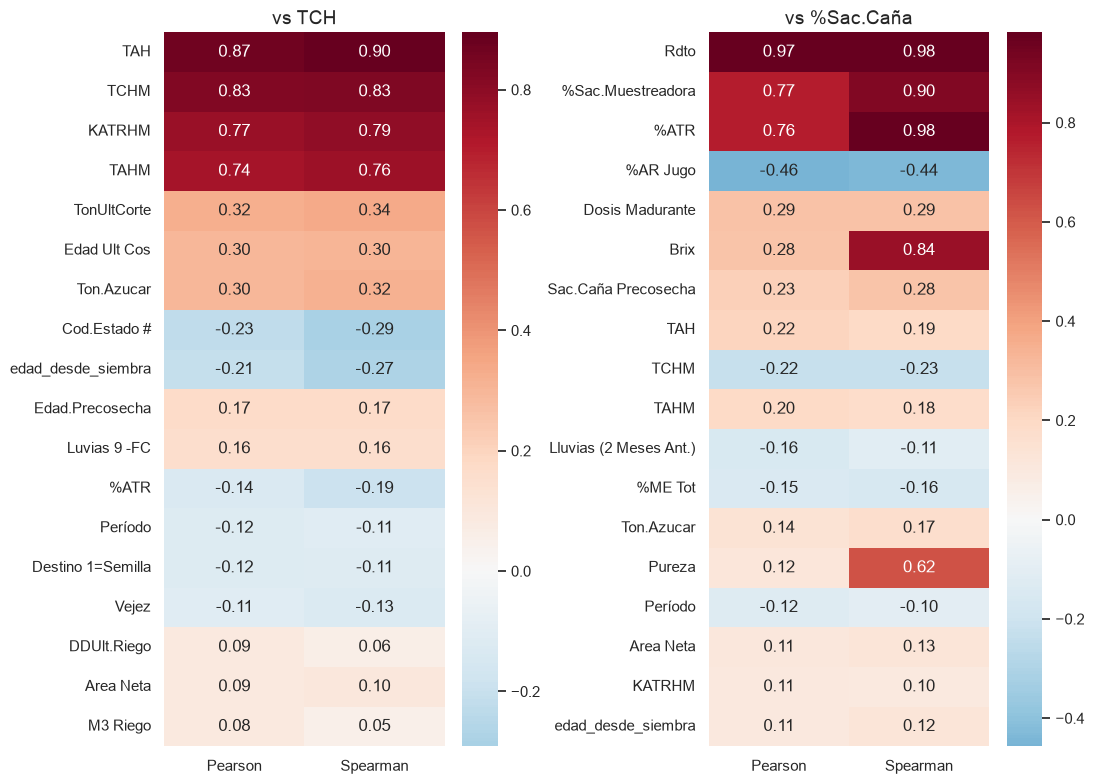

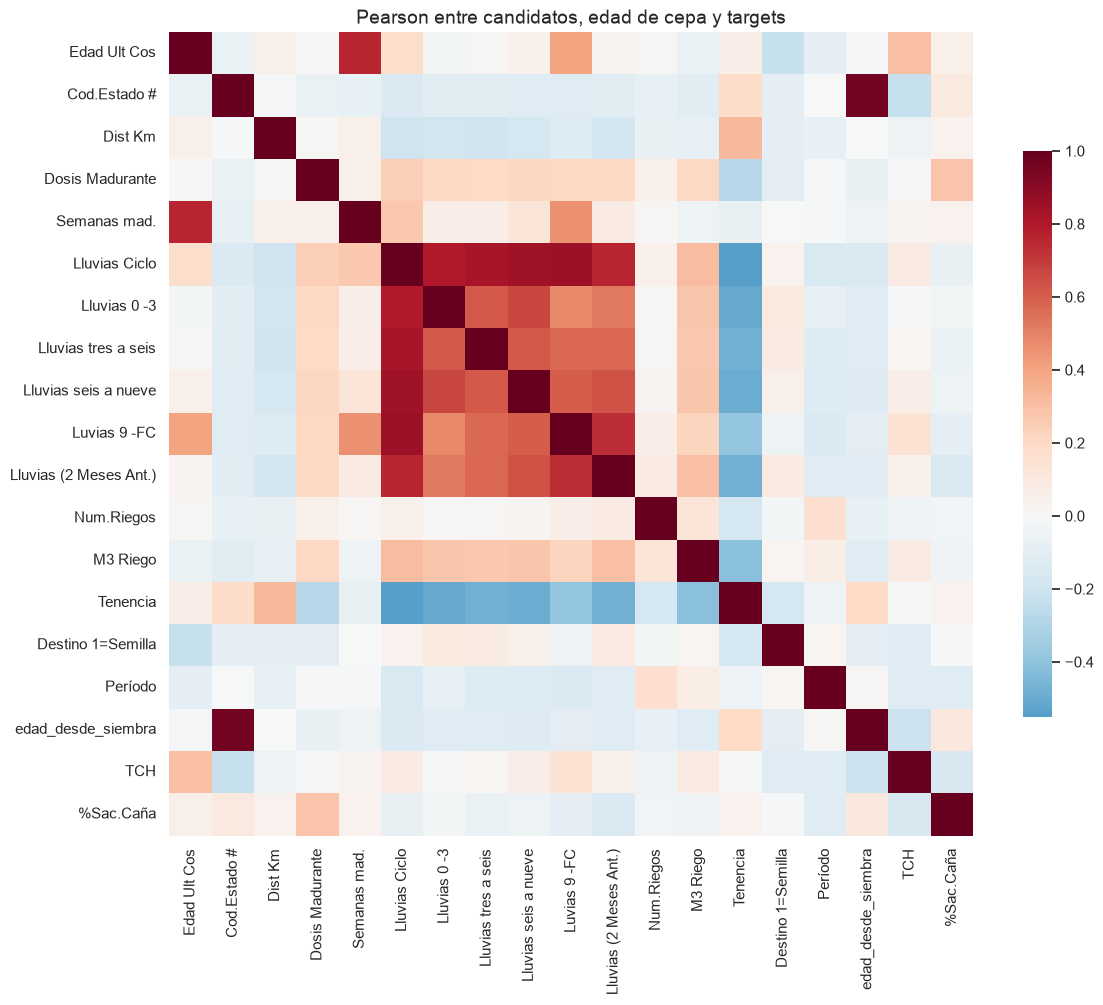

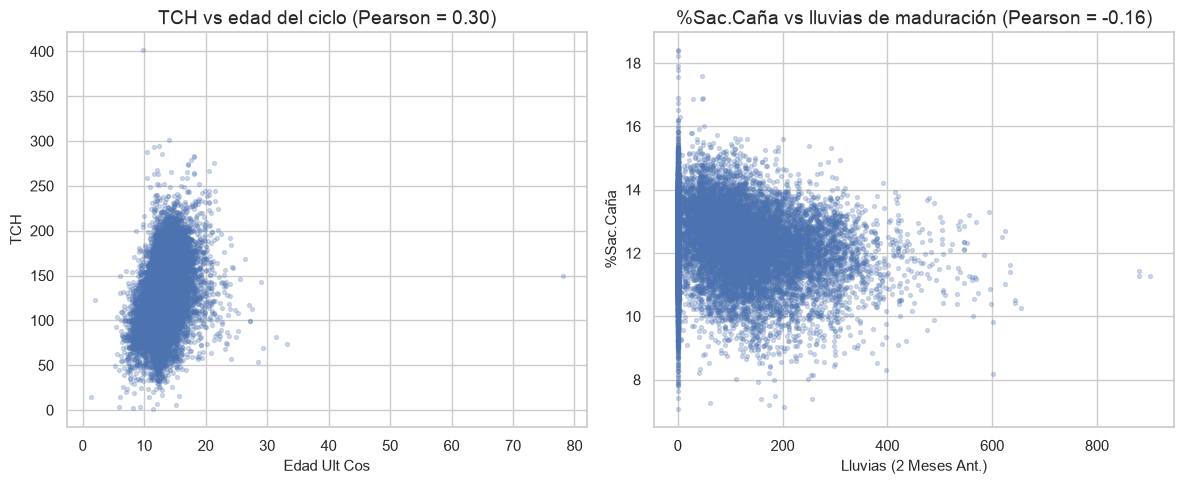

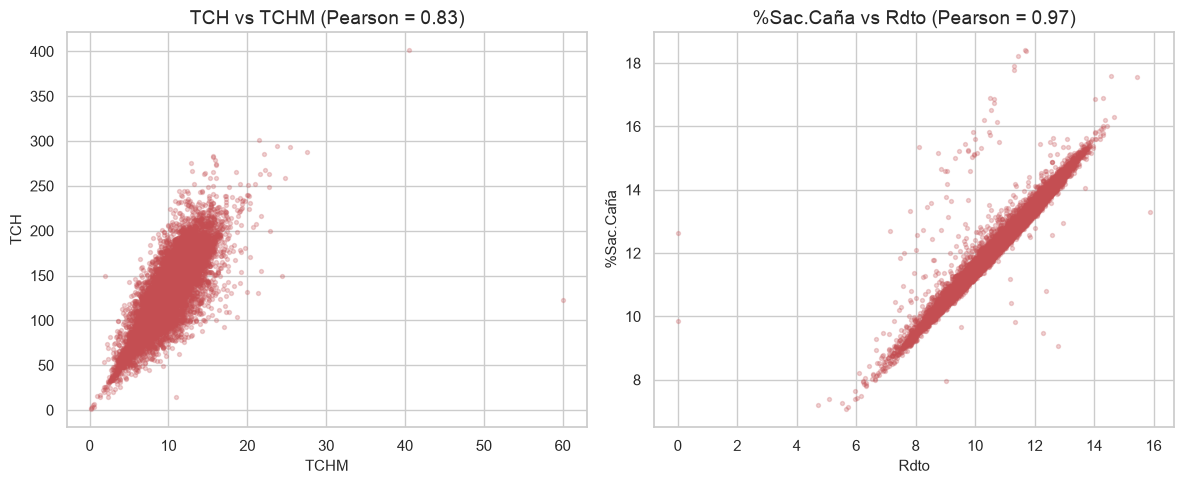


--- Trazabilidad | 10. Relaciones (fuga) ---
Motivo:            resultado / laboratorio de la misma cosecha
Columnas antes:    54
Columnas borradas: 17
Columnas quedan:   37
Borradas: ['TCHM', 'TAH', 'TAHM', 'KATRHM', 'TonUltCorte', 'Ton.Azucar', 'Rdto', '%Sac.Muestreadora', '%ATR', '%AR Jugo', 'Brix', 'Pureza', '%Fibra Caña', '%ME Min', '%ME Veg', '%ME Tot', 'Fosfato Jugo']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TCH', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo', 'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC']


In [21]:
num_cols = [
    c for c in list(dict.fromkeys(cols_trabajo_2 + ["edad_desde_siembra"]))
    if c in df_suertes.columns
    and pd.api.types.is_numeric_dtype(df_suertes[c])
    and c not in ["TCH", "%Sac.Caña"]
]
X_num = df_suertes[num_cols]


def tabla_corr(y):
    """Pearson (lineal) y Spearman (rango) de cada numérica contra un target. Spearman aguanta relaciones monótonas no lineales."""
    t = pd.DataFrame({
        "Pearson": X_num.corrwith(y, method="pearson"),
        "Spearman": X_num.corrwith(y, method="spearman"),
    })
    t["|Pearson|"] = t["Pearson"].abs()
    return t.sort_values("|Pearson|", ascending=False).drop(columns="|Pearson|")


corr_tch = tabla_corr(df_suertes["TCH"])
corr_sac = tabla_corr(df_suertes["%Sac.Caña"])

print("Correlación con TCH (todas las numéricas del set de trabajo)")
display(corr_tch.head(15).round(3))
print("Correlación con %Sac.Caña")
display(corr_sac.head(15).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 8))
sns.heatmap(
    corr_tch.head(18)[["Pearson", "Spearman"]],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
)
axes[0].set_title("vs TCH")
sns.heatmap(
    corr_sac.head(18)[["Pearson", "Spearman"]],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
)
axes[1].set_title("vs %Sac.Caña")
plt.tight_layout()
plt.show()

# Matriz entre candidatos numéricos + targets (sin el bloque de toneladas/azúcar)
cols_matriz = [c for c in cols_candidatos if c in num_cols] + ["edad_desde_siembra", "TCH", "%Sac.Caña"]
cols_matriz = [c for c in cols_matriz if c in df_suertes.columns]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df_suertes[cols_matriz].corr(numeric_only=True),
    cmap="RdBu_r", center=0, square=True, ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Pearson entre candidatos, edad de cepa y targets")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_suertes["Edad Ult Cos"], df_suertes["TCH"], s=8, alpha=0.25, color="#4C72B0")
axes[0].set_xlabel("Edad Ult Cos")
axes[0].set_ylabel("TCH")
r_e = df_suertes["TCH"].corr(df_suertes["Edad Ult Cos"])
axes[0].set_title(f"TCH vs edad del ciclo (Pearson = {r_e:.2f})")

lluvia_mad = "Lluvias (2 Meses Ant.)"
axes[1].scatter(df_suertes[lluvia_mad], df_suertes["%Sac.Caña"], s=8, alpha=0.25, color="#4C72B0")
axes[1].set_xlabel(lluvia_mad)
axes[1].set_ylabel("%Sac.Caña")
r_l = df_suertes["%Sac.Caña"].corr(df_suertes[lluvia_mad])
axes[1].set_title(f"%Sac.Caña vs lluvias de maduración (Pearson = {r_l:.2f})")
plt.tight_layout()
plt.show()

# Contraste: columnas que "predicen" demasiado bien
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_suertes["TCHM"], df_suertes["TCH"], s=8, alpha=0.25, color="#C44E52")
axes[0].set_xlabel("TCHM")
axes[0].set_ylabel("TCH")
axes[0].set_title(f"TCH vs TCHM (Pearson = {df_suertes['TCH'].corr(df_suertes['TCHM']):.2f})")
axes[1].scatter(df_suertes["Rdto"], df_suertes["%Sac.Caña"], s=8, alpha=0.25, color="#C44E52")
axes[1].set_xlabel("Rdto")
axes[1].set_ylabel("%Sac.Caña")
axes[1].set_title(f"%Sac.Caña vs Rdto (Pearson = {df_suertes['%Sac.Caña'].corr(df_suertes['Rdto']):.2f})")
plt.tight_layout()
plt.show()

cols_fuera_fuga = [
    "TCHM", "TAH", "TAHM", "KATRHM", "TonUltCorte", "Ton.Azucar", "Rdto",
    "%Sac.Muestreadora", "%ATR", "%AR Jugo", "Brix", "Pureza",
    "%Fibra Caña", "%ME Min", "%ME Veg", "%ME Tot", "Fosfato Jugo",
]
cols_fuera_fuga = [c for c in cols_fuera_fuga if c in cols_trabajo_2]
cols_trabajo_3 = [c for c in cols_trabajo_2 if c not in cols_fuera_fuga]
registrar_recorte(
    "10. Relaciones (fuga)",
    "resultado / laboratorio de la misma cosecha",
    len(cols_trabajo_2),
    cols_fuera_fuga,
    len(cols_trabajo_3),
)
print("Borradas:", cols_fuera_fuga)
print("Quedan:", cols_trabajo_3)

**Qué muestra este paso**

El ranking (Pearson + Spearman) ordena la evidencia **antes** de decidir.

**Fuga.** Lo más correlacionado con los targets no es clima ni variedad: es el **resultado de esa cosecha**. `Rdto` ≈ `%Sac.Caña` (Pearson ~0.97); `TCHM`/`TAH`/`KATRHM` van con TCH (~0.74–0.87). El scatter rojo es casi una recta: no hay nada que predecir. Laboratorio del mismo corte (`%ATR`, muestreadora, Brix, fibra, ME) mide la misma calidad. Salen de X.

**Predictores agronómicos.**

- **TCH vs `Edad Ult Cos`:** asociación positiva moderada (~0.30). Spearman similar: más edad de ciclo, más tonelaje, sin ser una recta perfecta (el scatter se dispersa; puede haber óptimo).
- **`%Sac.Caña` vs lluvias 2 meses antes:** correlación débil/negativa (~−0.16). Coherente con dilución en maduración; no es el efecto fuerte de `Rdto`.
- Entre candidatos, las lluvias por ventana se parecen entre sí (colinealidad → VIF). `edad_desde_siembra` se parece al n.º de corte, no a `Edad Ult Cos`.
- `Dosis Madurante` entra más en sacarosa que en TCH.

**Decisión.** `cols_trabajo_3` = set 2 menos toneladas, azúcar/ha, TCHM, Rdto y laboratorio de la misma cosecha. **Antes 54 → se borran 17 → quedan 37**. `Sac.Caña Precosecha` se deja: es una medición **antes** del corte, no el target.


## 11. Relaciones de categorías con los targets

Tras sacar las fugas, se mira si zona, corte, quema, variedad y cultivo —factores agronómicos del rendimiento— se asocian con TCH y `%Sac.Caña`. Boxplots por grupo; las colas extremas ya se vieron en el univariado, aquí importa el desplazamiento de la caja.


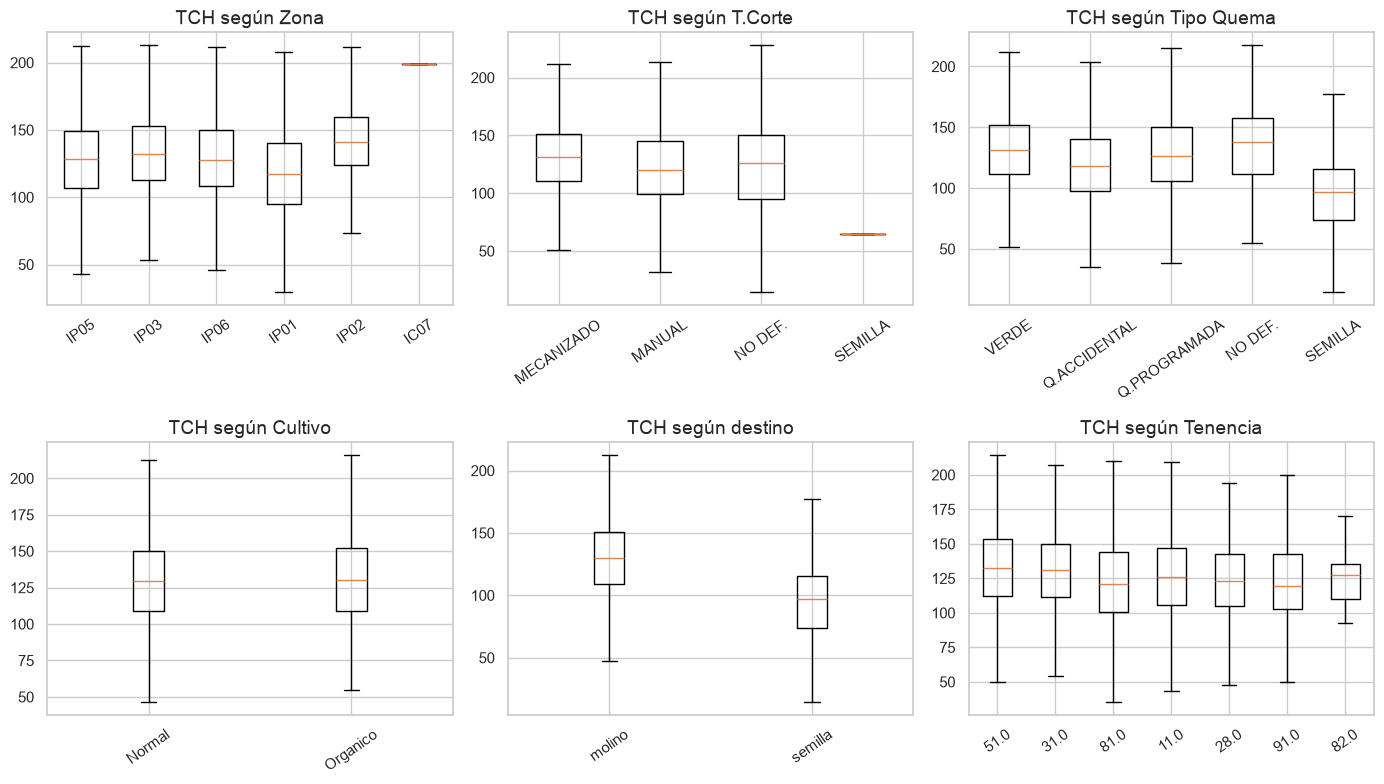

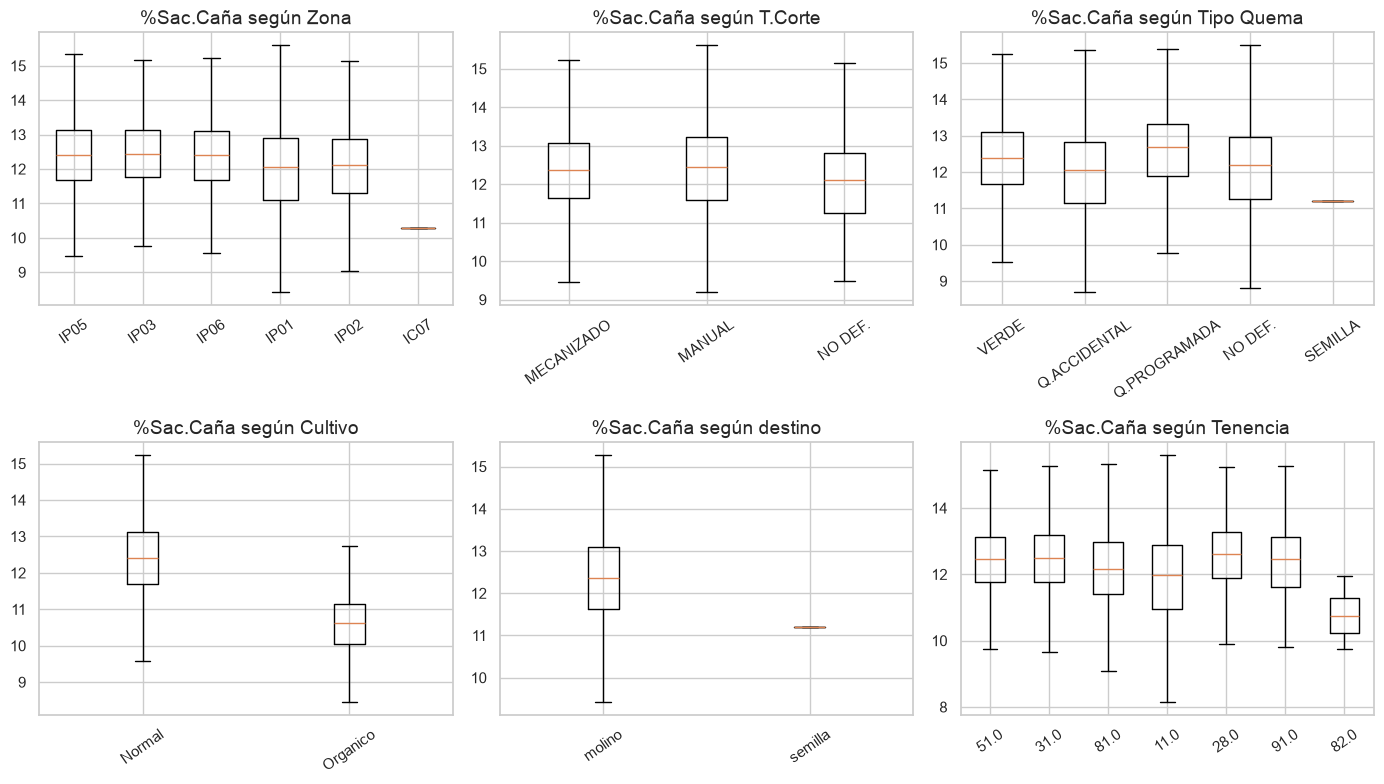

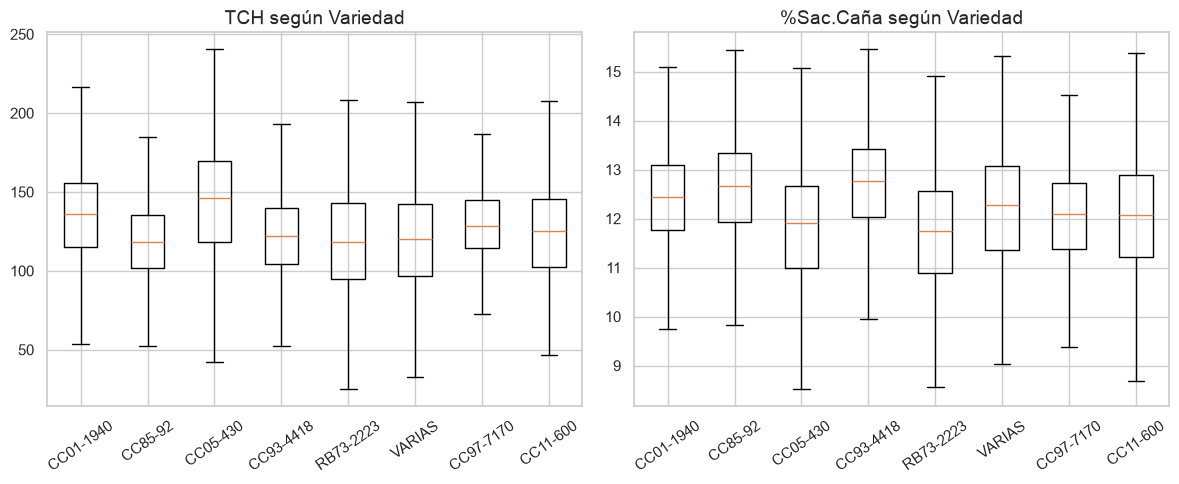

Medias por grupo


,TCH,%Sac.Caña
Zona,,
IC07,199.04,10.28
IP01,117.83,11.98
IP02,142.76,12.06
IP03,133.64,12.42
IP05,128.27,12.38
IP06,128.58,12.37


,TCH,%Sac.Caña
T.Corte,,
MANUAL,123.61,12.38
MECANIZADO,131.00,12.31
NO DEF.,123.01,12.06
SEMILLA,65.04,NaN


,TCH,%Sac.Caña
Tipo Quema,,
NO DEF.,135.80,12.11
Q.ACCIDENTAL,119.39,11.95
Q.PROGRAMADA,129.31,12.59
SEMILLA,96.62,11.19
VERDE,131.59,12.36


,TCH,%Sac.Caña
Cultivo,,
Normal,129.58,12.38
Organico,130.21,10.58
NaN,145.67,12.16


,TCH,%Sac.Caña
Destino 1=Semilla,,
0,130.08,12.32
1,96.62,11.19


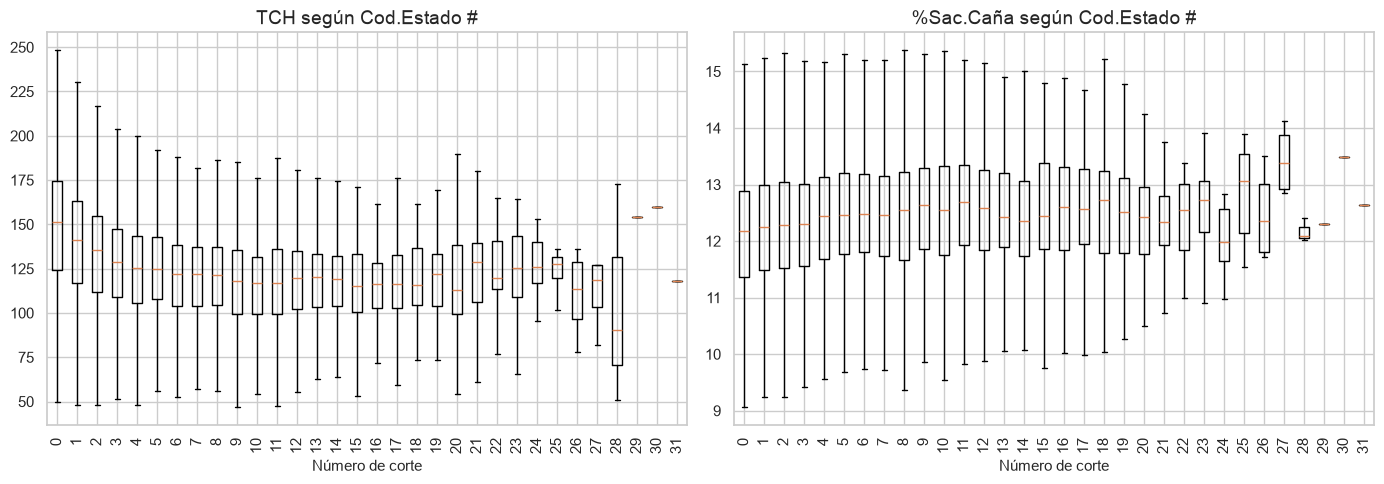

Medias por número de corte:


TCH       %Sac.Caña      
               mean count      mean count
Cod.Estado #                             
0             148.3  2677      12.1  2530
1             139.2  2823      12.2  2721
2             132.8  2925      12.2  2851
3             127.9  2820      12.3  2779
4             124.1  2378      12.4  2361
5             123.7  1791      12.5  1771
6             120.7  1337      12.5  1322
7             120.0  1006      12.4   996
8             120.7   692      12.5   685
9             116.6   560      12.6   559
10            114.9   375      12.5   373
11            117.0   265      12.6   263
12            119.5   229      12.5   226
13            118.1   208      12.5   207
14            117.7   196      12.5   194
15            116.9   149      12.5   148
16            119.5   126      12.5   126
17            119.2   105      12.6   105
18            120.6    94      12.6    93
19            119.8    70      12.4    70
20            116.5    57      12.4    55
21            125.2    39      12.4    38
22            123.5    31      12.4    31
23            123.8    28      12.6    28
24            125.5    19      12.0    19
25            125.8    11      12.8    11
26            111.0     6      12.5     6
27            111.7     4      13.4     4
28            104.6     3      12.2     3
29            154.4     1      12.3     1
30            160.0     1      13.5     1
31            117.9     1      12.6     1

In [22]:
def box_por(df, cat, y, ax, orden=None):
    """Boxplot de `y` por nivel de `cat`. `showfliers=False` para leer el cuerpo, no la cola. `orden` fija el eje (p. ej. número de corte)."""
    datos = df[[cat, y]].dropna()
    if orden is None:
        orden = [c for c in datos[cat].value_counts().index if pd.notna(c)]
    grupos = [datos.loc[datos[cat] == n, y].values for n in orden]
    ax.boxplot(grupos, orientation="vertical", tick_labels=[str(n) for n in orden], showfliers=False)
    ax.set_title(f"{y} según {cat}")
    ax.tick_params(axis="x", rotation=35)


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_por(df_suertes, "Zona", "TCH", axes[0, 0])
box_por(df_suertes, "T.Corte", "TCH", axes[0, 1])
box_por(df_suertes, "Tipo Quema", "TCH", axes[0, 2])
box_por(df_suertes, "Cultivo", "TCH", axes[1, 0])
df_tmp = df_suertes.copy()
df_tmp["destino"] = df_tmp["Destino 1=Semilla"].map({0: "molino", 1: "semilla"})
box_por(df_tmp, "destino", "TCH", axes[1, 1])
box_por(df_suertes, "Tenencia", "TCH", axes[1, 2])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_por(df_suertes, "Zona", "%Sac.Caña", axes[0, 0])
box_por(df_suertes, "T.Corte", "%Sac.Caña", axes[0, 1])
box_por(df_suertes, "Tipo Quema", "%Sac.Caña", axes[0, 2])
box_por(df_suertes, "Cultivo", "%Sac.Caña", axes[1, 0])
box_por(df_tmp, "destino", "%Sac.Caña", axes[1, 1])
box_por(df_suertes, "Tenencia", "%Sac.Caña", axes[1, 2])
plt.tight_layout()
plt.show()

top_var = df_suertes["Variedad"].value_counts().head(8).index
df_var = df_suertes[df_suertes["Variedad"].isin(top_var)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
box_por(df_var, "Variedad", "TCH", axes[0])
box_por(df_var, "Variedad", "%Sac.Caña", axes[1])
plt.tight_layout()
plt.show()

print("Medias por grupo")
for cat in ["Zona", "T.Corte", "Tipo Quema", "Cultivo", "Destino 1=Semilla"]:
    display(df_suertes.groupby(cat, dropna=False)[["TCH", "%Sac.Caña"]].mean().round(2))

# Número de corte (soca), aislado: el efecto suele ser no lineal
orden_corte = sorted(df_suertes["Cod.Estado #"].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
box_por(df_suertes, "Cod.Estado #", "TCH", axes[0], orden=orden_corte)
box_por(df_suertes, "Cod.Estado #", "%Sac.Caña", axes[1], orden=orden_corte)
axes[0].tick_params(axis="x", rotation=90)
axes[1].tick_params(axis="x", rotation=90)
axes[0].set_xlabel("Número de corte")
axes[1].set_xlabel("Número de corte")
plt.tight_layout()
plt.show()

print("Medias por número de corte:")
display(
    df_suertes.groupby("Cod.Estado #")[["TCH", "%Sac.Caña"]]
    .agg(["mean", "count"])
    .round(1)
)

**Qué muestra este paso**

Las categorías agronómicas **sí se mueven** con los targets, no solo las numéricas.

- **Zona:** IP02 tiene más TCH (~143); IP01 menos (~118). Sacarosa más parecida entre zonas (salvo `IC07`, 1 fila).
- **Corte / destino:** mecanizado rinde más que manual. Semilla baja el TCH (~97 vs ~130) y la sacarosa; confirma el paso 7.
- **Quema:** accidental baja TCH y sacarosa frente a verde o programada.
- **Cultivo:** TCH casi igual; **orgánico baja sacarosa** (~10.6 vs ~12.4). Relevante para Providencia (prácticas de sostenibilidad).
- **Variedad (top 8):** CC05-430 y CC01-1940 tiran TCH hacia arriba; CC85-92 y CC93-4418, más sacarosa. No es un solo ranking para los dos objetivos.
- **Número de corte (`Cod.Estado #`):** la plantilla (0) rinde ~148 t/ha; el TCH baja de forma sostenida hasta el corte 9–10 (~115) y después se aplana (los cortes ≥20 son pocos). No es el “sube y luego cae” de los textos agronómicos: aquí la soca pierde desde el primer corte. La sacarosa casi no se mueve (~12.1 → ~12.5). Entra al lineal como tendencia; el tramo no lineal se anota como limitación.

**Decisión.** Se mantienen `Zona`, `T.Corte`, `Tipo Quema`, `Cultivo`, `Destino 1=Semilla`, `Tenencia` y `Variedad` (esta, agrupando cola). `Tenencia` son códigos (11, 28, 31, …), no una escala: va a categóricas, no al VIF numérico. `IC07` y `T.Corte = SEMILLA` (1 fila) se funden en **OTRAS**. Siguiente: VIF sobre los predictores numéricos ya elegidos.


## 12. Multicolinealidad (VIF)

Se calcula el Factor de Inflación de la Varianza sobre las variables **ya seleccionadas** para el lineal. Umbral de alerta: VIF > 5 (grave si > 10). Se compara el bloque de lluvias (ciclo vs ventanas), las dos edades (ciclo vs cepa / n.º de corte) y el resto de numéricas que entran al set final (`Num.Riegos`, `Semanas mad.`, `madurada`). **`Tenencia` no entra aquí:** son códigos de categoría (11, 28, 31, …), no una escala continua; va con las dummy. Las categóricas (zona, suelo, variedad) se miran con Cramér’s V en el cierre, no con VIF: todavía no hay matriz de diseño.


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def tabla_vif(df, cols):
    """VIF de un bloque numérico (dropna + constante). Convención: alerta si VIF>5, grave si VIF>10. No aplica a dummies."""
    X = df[cols].dropna()
    Xc = sm.add_constant(X, has_constant="add")
    filas = []
    for i, nombre in enumerate(Xc.columns):
        if nombre == "const":
            continue
        filas.append({
            "variable": nombre,
            "VIF": variance_inflation_factor(Xc.values, i),
        })
    out = pd.DataFrame(filas).sort_values("VIF", ascending=False)
    out.attrs["n"] = len(X)
    return out


lluvias_todas = [
    "Lluvias Ciclo", "Lluvias 0 -3", "Lluvias tres a seis",
    "Lluvias seis a nueve", "Luvias 9 -FC", "Lluvias (2 Meses Ant.)",
]
print("A) Las 6 lluvias juntas (n =", df_suertes[lluvias_todas].dropna().shape[0], ")")
display(tabla_vif(df_suertes, lluvias_todas).round(2))

print("B) Solo ciclo + lluvias 2 meses antes")
display(tabla_vif(df_suertes, ["Lluvias Ciclo", "Lluvias (2 Meses Ant.)"]).round(2))

# Tenencia es categórica: fuera de este bloque.
# Semanas mad. / Num.Riegos / madurada tienen NA informativos. Un dropna crudo
# deja ~5.5 mil filas y madurada constante (el NA de semanas ≈ no maduró).
# Misma regla corta del paso 13, sobre una copia, para evaluar el set que sí entra.
df_vif = df_suertes.copy()
df_vif["madurada"] = (
    (df_vif["Dosis Madurante"].fillna(0) > 0) | df_vif["Producto"].notna()
).astype(int)
df_vif["Dosis Madurante"] = df_vif["Dosis Madurante"].fillna(0)
df_vif.loc[df_vif["Semanas mad."] < 0, "Semanas mad."] = np.nan
df_vif.loc[df_vif["madurada"] == 0, "Semanas mad."] = (
    df_vif.loc[df_vif["madurada"] == 0, "Semanas mad."].fillna(0)
)
med_semanas_vif = df_vif.loc[df_vif["madurada"] == 1, "Semanas mad."].median()
df_vif["Semanas mad."] = df_vif["Semanas mad."].fillna(med_semanas_vif)
df_vif.loc[df_vif["Num.Riegos"].isna() & (df_vif["M3 Riego"] == 0), "Num.Riegos"] = 0
med_riegos_vif = df_vif.loc[df_vif["M3 Riego"] > 0, "Num.Riegos"].median()
df_vif["Num.Riegos"] = df_vif["Num.Riegos"].fillna(med_riegos_vif)
df_vif["Dist Km"] = df_vif["Dist Km"].fillna(df_vif["Dist Km"].median())

cols_vif_edades = [
    "Edad Ult Cos", "Cod.Estado #", "edad_desde_siembra",
    "Dist Km", "Dosis Madurante", "Semanas mad.", "madurada",
    "Lluvias Ciclo", "Lluvias (2 Meses Ant.)",
    "Num.Riegos", "M3 Riego", "Destino 1=Semilla", "Período",
]
print("C) Set numérico del lineal, con ambas edades (n =", df_vif[cols_vif_edades].dropna().shape[0], ")")
print("Tenencia no entra (códigos de categoría).")
vif_c = tabla_vif(df_vif, cols_vif_edades)
display(vif_c.round(2))

cols_vif_final = [c for c in cols_vif_edades if c != "edad_desde_siembra"]
print("D) Mismo set sin edad_desde_siembra")
display(tabla_vif(df_vif, cols_vif_final).round(2))
print(
    "corr Dosis Madurante vs madurada:",
    round(df_vif["Dosis Madurante"].corr(df_vif["madurada"]), 3),
    "| Num.Riegos vs M3 Riego:",
    round(df_vif["Num.Riegos"].corr(df_vif["M3 Riego"]), 3),
)

s_ventanas = (
    df_suertes["Lluvias 0 -3"]
    + df_suertes["Lluvias tres a seis"]
    + df_suertes["Lluvias seis a nueve"]
    + df_suertes["Luvias 9 -FC"]
)
print(
    "Correlación Lluvias Ciclo vs suma de ventanas 0–cosecha:",
    round(df_suertes["Lluvias Ciclo"].corr(s_ventanas), 6),
)
print(
    "Correlación n.º de corte vs edad_desde_siembra:",
    round(df_suertes["Cod.Estado #"].corr(df_suertes["edad_desde_siembra"]), 3),
)

cols_fuera_vif = [
    "Lluvias 0 -3", "Lluvias tres a seis", "Lluvias seis a nueve", "Luvias 9 -FC",
]
# edad_desde_siembra no está en cols_trabajo_3 (es derivada)
cols_modelo = [
    c for c in (cols_trabajo_3 if "cols_trabajo_3" in dir() else cols_trabajo_2)
    if c not in cols_fuera_vif
]
registrar_recorte(
    "12. VIF",
    "ventanas de lluvia que suman el ciclo",
    len(cols_trabajo_3),
    cols_fuera_vif,
    len(cols_modelo),
)
print("Borradas:", cols_fuera_vif)
print("Quedan:", cols_modelo)
print("Se deja fuera del lineal edad_desde_siembra (redundante con Cod.Estado #).")

A) Las 6 lluvias juntas (n = 21027 )


,variable,VIF
0,Lluvias Ciclo,266558.15
4,Luvias 9 -FC,47670.57
1,Lluvias 0 -3,18446.63
2,Lluvias tres a seis,18186.93
3,Lluvias seis a nueve,17456.51
5,Lluvias (2 Meses Ant.),2.59


B) Solo ciclo + lluvias 2 meses antes


,variable,VIF
0,Lluvias Ciclo,2.39
1,Lluvias (2 Meses Ant.),2.39


C) Set numérico del lineal, con ambas edades (n = 21027 )
Tenencia no entra (códigos de categoría).


,variable,VIF
1,Cod.Estado #,13.92
2,edad_desde_siembra,13.89
6,madurada,8.51
4,Dosis Madurante,7.15
5,Semanas mad.,3.13
7,Lluvias Ciclo,2.84
8,Lluvias (2 Meses Ant.),2.51
0,Edad Ult Cos,1.45
10,M3 Riego,1.23
9,Num.Riegos,1.13


D) Mismo set sin edad_desde_siembra


,variable,VIF
5,madurada,8.51
3,Dosis Madurante,7.15
4,Semanas mad.,3.13
6,Lluvias Ciclo,2.84
7,Lluvias (2 Meses Ant.),2.51
0,Edad Ult Cos,1.42
9,M3 Riego,1.23
8,Num.Riegos,1.13
10,Destino 1=Semilla,1.12
2,Dist Km,1.09


corr Dosis Madurante vs madurada: 0.922 | Num.Riegos vs M3 Riego: 0.279
Correlación Lluvias Ciclo vs suma de ventanas 0–cosecha: 0.999998
Correlación n.º de corte vs edad_desde_siembra: 0.962

--- Trazabilidad | 12. VIF ---
Motivo:            ventanas de lluvia que suman el ciclo
Columnas antes:    37
Columnas borradas: 4
Columnas quedan:   33
Borradas: ['Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC']
Quedan: ['Período', 'Zona', 'Tenencia', 'Suelo', 'Area Neta', 'Dist Km', 'Variedad', 'Cod.Estado #', 'F.Siembra', 'D.S.', 'Ult.Riego', 'Edad Ult Cos', 'F.Ult.Corte', 'Destino 1=Semilla', 'Cultivo', 'Fec.Madur.', 'Producto', 'Dosis Madurante', 'Semanas mad.', 'TCH', 'Sac.Caña Precosecha', 'Edad.Precosecha', '%Sac.Caña', 'Vejez', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó', 'Num.Riegos', 'M3 Riego', 'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo']
Se deja fuera del lineal edad_desde_siembra (redundante con Cod.Estado #).


**Qué muestra este paso**

- **Lluvias:** meter ciclo y las cuatro ventanas juntas infla el VIF a decenas de miles. `Lluvias Ciclo` **es** la suma de `0-3` + `3-6` + `6-9` + `9-FC` (corr ≈ 1). No son predictores distintos. En cambio **ciclo + lluvias de 2 meses antes** queda en VIF ≈ 2.4 (por debajo de 5). Esa pareja cubre el TCH (agua del ciclo) y la sacarosa (humedad en maduración).
- **Edades:** `Cod.Estado #` y `edad_desde_siembra` tienen VIF ≈ 14. Es el mismo fenómeno del paso 8: años de cepa ≈ número de cortes. `Edad Ult Cos` no se pisa con ellas (VIF ≈ 1.4).
- **Maduración:** `madurada` (VIF ≈ 8.5) y `Dosis Madurante` (≈ 7.2) saltan el umbral de alerta porque corr ≈ 0.92: dosis 0 es casi el flag de “no aplicó”. Se dejan las dos (sí/no vs intensidad); el lineal puede tirar el flag si se inestabiliza. `Semanas mad.` queda en ≈ 3.1.
- **Riego:** `Num.Riegos` y `M3 Riego` no se pisan (VIF ≈ 1.1–1.2).
- **Tenencia** no está en esta tabla: es categórica.

**Decisión.** Para el lineal: lluvias = `Lluvias Ciclo` + `Lluvias (2 Meses Ant.)`; edad = `Edad Ult Cos` + `Cod.Estado #`. **Antes 37 → se borran 4 ventanas → quedan 33** (`cols_modelo`). `edad_desde_siembra` no entra al lineal. El VIF se vuelve a calcular sobre el train (con dummies).


## 13. Imputación (variables que entran al modelo)

La estrategia no se limita a la media global: las reglas salen de los pasos 3 y 9. `%Sac.Caña` no se imputa (es un target). Más adelante, medianas y modas se recalculan **solo en entrenamiento**.


In [24]:
df_modelo = df_suertes.copy()

cols_nulos = [
    "Dosis Madurante", "Semanas mad.", "Producto", "Num.Riegos", "M3 Riego",
    "Suelo", "Dist Km", "Tenencia", "Cultivo", "%Sac.Caña", "TCH",
]
nulos_antes = df_modelo[cols_nulos].isna().sum().rename("nulos_antes")


def moda_serie(s):
    """Moda de una serie ignorando NA; NaN si está vacía. Se usa para imputar suelo/tenencia/cultivo por zona."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan


# Maduración: NA o dosis 0 = no se aplicó (coincide con Producto vacío)
df_modelo["madurada"] = (
    (df_modelo["Dosis Madurante"].fillna(0) > 0) | df_modelo["Producto"].notna()
).astype(int)
df_modelo["Dosis Madurante"] = df_modelo["Dosis Madurante"].fillna(0)
df_modelo["Producto"] = df_modelo["Producto"].fillna("SIN MADURANTE")

# Semanas negativas = error; si no maduró, 0; si maduró y falta, mediana de madurados
df_modelo.loc[df_modelo["Semanas mad."] < 0, "Semanas mad."] = np.nan
df_modelo.loc[df_modelo["madurada"] == 0, "Semanas mad."] = (
    df_modelo.loc[df_modelo["madurada"] == 0, "Semanas mad."].fillna(0)
)
med_semanas = df_modelo.loc[df_modelo["madurada"] == 1, "Semanas mad."].median()
df_modelo["Semanas mad."] = df_modelo["Semanas mad."].fillna(med_semanas)

# Riego: nulo + m³ = 0 → cero riegos
df_modelo.loc[df_modelo["Num.Riegos"].isna() & (df_modelo["M3 Riego"] == 0), "Num.Riegos"] = 0
med_riegos = df_modelo.loc[df_modelo["M3 Riego"] > 0, "Num.Riegos"].median()
df_modelo["Num.Riegos"] = df_modelo["Num.Riegos"].fillna(med_riegos)

# Suelo, distancia, tenencia, cultivo: por zona (no la media/moda del ingenio)
df_modelo["Suelo"] = df_modelo["Suelo"].fillna(
    df_modelo.groupby("Zona")["Suelo"].transform(moda_serie)
).fillna("DESCONOCIDO")
df_modelo["Dist Km"] = df_modelo["Dist Km"].fillna(
    df_modelo.groupby("Zona")["Dist Km"].transform("median")
)
df_modelo["Tenencia"] = df_modelo["Tenencia"].fillna(
    df_modelo.groupby("Zona")["Tenencia"].transform(moda_serie)
)
df_modelo["Cultivo"] = df_modelo["Cultivo"].fillna(
    df_modelo.groupby("Zona")["Cultivo"].transform(moda_serie)
)

nulos_despues = df_modelo[cols_nulos].isna().sum().rename("nulos_despues")
display(pd.concat([nulos_antes, nulos_despues], axis=1))

print("madurada = 1:", int(df_modelo["madurada"].sum()),
      "| madurada = 0:", int((df_modelo["madurada"] == 0).sum()))
print("Filas con %Sac.Caña (modelo de calidad):", int(df_modelo["%Sac.Caña"].notna().sum()))
print("Filas con TCH (modelo de productividad):", int(df_modelo["TCH"].notna().sum()))
print("df_modelo:", df_modelo.shape)

,nulos_antes,nulos_despues
Dosis Madurante,104,0
Semanas mad.,9775,0
Producto,9778,0
Num.Riegos,12589,0
M3 Riego,0,0
Suelo,3758,0
Dist Km,5,0
Tenencia,1,0
Cultivo,2,0
%Sac.Caña,449,449


madurada = 1: 11252 | madurada = 0: 9775
Filas con %Sac.Caña (modelo de calidad): 20578
Filas con TCH (modelo de productividad): 21027
df_modelo: (21027, 87)


**Qué muestra este paso**

Se trabaja sobre `df_modelo` (copia). `df_suertes` conserva los nulos originales.

| Columna | Regla | Base en el EDA |
|---|---|---|
| `Dosis Madurante` NA | 0 + flag `madurada` | “Sin dato” coincide con `Producto` vacío: no se aplicó |
| `Producto` NA | `SIN MADURANTE` | Misma lógica |
| `Semanas mad.` | 0 si no maduró; si maduró, mediana de madurados. Negativos → nulo | No es la mediana de todo el ingenio |
| `Num.Riegos` NA | 0 si m³ = 0; si no, mediana de lotes con riego | El nulo era cero riegos |
| `Suelo` | moda **por zona** | Condicionar al sitio, no una moda global del ingenio |
| `Dist Km`, `Tenencia`, `Cultivo` | mediana/moda por zona | Pocos nulos |
| `%Sac.Caña` | **no se imputa** | Target: 20.578 filas en ese modelo |
| Lluvias | no se tocan | 0% nulos |

**Decisión.** Predictores del lineal ya sin huecos (salvo el target de sacarosa). Falta el **cierre**: tabla de qué se quedó y qué salió (nulos, IDs, fuga, VIF) y la lista X para TCH y para sacarosa. Luego: hold-out 80/20 y regresión.


## 14. Set final de predictores

Resumen de lo que entra a los dos lineales, lo que se descartó y por qué. Se agrupan variedades y suelos poco frecuentes para no dummyficar 100 niveles. El hold-out 80/20 y el ajuste van en la sección de modelamiento.


In [25]:
def agrupar_cola(serie, min_n):
    """Niveles con n < min_n pasan a 'OTRAS'. Evita dummies de una sola fila en el lineal (Variedad min_n=200, Suelo=300)."""
    vc = serie.value_counts()
    keep = vc[vc >= min_n].index
    return serie.where(serie.isin(keep), "OTRAS")


df_modelo["Variedad_agrup"] = agrupar_cola(df_modelo["Variedad"], 200)
df_modelo["Suelo_agrup"] = agrupar_cola(df_modelo["Suelo"], 300)
df_modelo["Zona_agrup"] = df_modelo["Zona"].replace({"IC07": "OTRAS"})
df_modelo["T.Corte_agrup"] = df_modelo["T.Corte"].replace({"SEMILLA": "OTRAS"})
# Códigos de tenencia (11, 28, 31, …): texto para que el lineal las dummyfique
df_modelo["Tenencia"] = df_modelo["Tenencia"].astype("Int64").astype(str)

print("T.Corte_agrup:\n", df_modelo["T.Corte_agrup"].value_counts().to_string())
print("Tenencia (categórica):\n", df_modelo["Tenencia"].value_counts().to_string())

cols_x_num = [
    "Edad Ult Cos",
    "Cod.Estado #",
    "Dist Km",
    "Dosis Madurante",
    "Semanas mad.",
    "madurada",
    "Lluvias Ciclo",
    "Lluvias (2 Meses Ant.)",
    "Num.Riegos",
    "M3 Riego",
    "Destino 1=Semilla",
    "Período",
]
cols_x_cat = [
    "Zona_agrup",
    "Variedad_agrup",
    "Suelo_agrup",
    "T.Corte_agrup",
    "Tipo Quema",
    "Cultivo",
    "Tenencia",
]
cols_x = cols_x_num + cols_x_cat

faltan = [c for c in cols_x if c not in df_modelo.columns]
assert not faltan, faltan

nulos_x = df_modelo[cols_x].isna().sum()
print("Nulos en predictores (deben ser 0):")
display(nulos_x[nulos_x > 0] if nulos_x.sum() else nulos_x.to_frame("nulos"))

df_tch = df_modelo.dropna(subset=["TCH"]).copy()
df_sac = df_modelo.dropna(subset=["%Sac.Caña"]).copy()
print(f"Modelo TCH:      n = {len(df_tch):,}  |  predictores = {len(cols_x)}")
print(f"Modelo %Sac.Caña: n = {len(df_sac):,}  |  mismas X, sin imputar el target")
print("Niveles Variedad_agrup:", df_modelo["Variedad_agrup"].nunique(),
      "| Suelo_agrup:", df_modelo["Suelo_agrup"].nunique())

equiv_agrup = {
    "Zona_agrup": "Zona",
    "Variedad_agrup": "Variedad",
    "Suelo_agrup": "Suelo",
    "T.Corte_agrup": "T.Corte",
}
usadas = set(cols_x) | {equiv_agrup.get(c, c) for c in cols_x} | {"madurada"}
predictores_previos = [c for c in cols_modelo if c not in ["TCH", "%Sac.Caña"]]
fuera_lineal = [c for c in predictores_previos if c not in usadas]
registrar_recorte(
    "14. Set final",
    "solo las X del lineal (agrupa cola; deja fechas y extras)",
    len(predictores_previos),
    fuera_lineal,
    len(cols_x),
)
print("Borradas del lineal:", fuera_lineal)
print("X final:", cols_x)
print("X numéricas:", cols_x_num)
print("X categóricas (Tenencia incluida):", cols_x_cat)

print("\nResumen de recortes (Excel original = 85 columnas):")
display(pd.DataFrame(trazabilidad))


def cramers_v(a, b):
    """Asociación 0–1 entre dos categóricas vía chi² de la tabla de contingencia. Complementa el VIF, que solo mira numéricas."""
    tab = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))


cats_asoc = ["Zona_agrup", "Suelo_agrup", "Variedad_agrup"]
cramer = pd.DataFrame(index=cats_asoc, columns=cats_asoc, dtype=float)
for a in cats_asoc:
    for b in cats_asoc:
        cramer.loc[a, b] = 1.0 if a == b else cramers_v(df_modelo[a], df_modelo[b])
print("Cramér's V entre zona, suelo y variedad agrupados (no es VIF):")
display(cramer.round(3))

decisiones = pd.DataFrame([
    ["TCH", "Target productividad", "Se queda", "Indicador de productividad; 0 nulos; n = 21.027"],
    ["%Sac.Caña", "Target calidad", "Se queda", "Indicador de calidad; 449 nulos no imputados; n = 20.578"],
    ["Edad Ult Cos", "Edad del ciclo", "Se queda", "Edad de este ciclo, no F.Siembra (paso 8)"],
    ["Cod.Estado #", "Número de corte", "Se queda", "Número de corte; el texto era duplicado"],
    ["Variedad / Suelo / Zona", "Genética y sitio", "Se queda (agrupadas)", "Factores agronómicos de sitio y genética; cola de niveles → OTRAS"],
    ["Dist Km", "Distancia al ingenio", "Se queda", "Distancia al ingenio; factor de logística"],
    ["Dosis Madurante, Semanas mad., madurada", "Maduración", "Se queda", "Maduración; NA / dosis 0 = no aplicó"],
    ["Producto", "Nombre comercial del madurante", "Fuera", "Candidato (paso 6). NA = no maduró; dosis/semanas/madurada ya cubren el tratamiento; 46% nulos y colinea con aplicó o no"],
    ["Lluvias Ciclo", "Clima del ciclo", "Se queda", "Clima del ciclo; la estación del lote está vacía"],
    ["Lluvias (2 Meses Ant.)", "Clima en maduración", "Se queda", "Humedad en maduración (dilución de sacarosa)"],
    ["Num.Riegos, M3 Riego", "Riego", "Se queda", "Riego; NA de conteo = 0 si m³ = 0"],
    ["T.Corte, Tipo Quema, Cultivo, Tenencia, Destino", "Manejo", "Se queda", "Bivariado: semilla, quema accidental, orgánico. Tenencia = códigos, dummy"],
    ["Período", "Tendencia temporal", "Se queda", "2017–2024"],
    ["Nombre, Hacienda, Suerte", "ID de finca/lote", "Fuera", "Paso 4: identificadores de finca/lote"],
    ["Cod.Estado, Cod. T.Cultivo", "Texto duplicado", "Fuera", "Paso 4"],
    ["Fertilizantes y estación (temp, radiación, …)", "Insumos / clima de sensor", "Fuera", "Paso 3: ≥70% nulos"],
    ["TCHM, TAH, Rdto, Ton.*, laboratorio del corte", "Resultado de la cosecha", "Fuera", "Paso 10: fuga (Rdto≈sacarosa, TCHM≈TCH)"],
    ["Area Neta", "Tamaño del lote (ha)", "Fuera", "TCH ya está por hectárea; extremos 250–401 se concentran en 0.1–2 ha (denominador chico = error de medición, no fuga)"],
    ["Ventanas de lluvia 0-3 … 9-FC", "Partes del ciclo", "Fuera", "Paso 12: VIF; suman Lluvias Ciclo"],
    ["edad_desde_siembra, F.Siembra, F.Ult.Corte", "Fechas / edad de cepa", "Fuera del lineal", "Paso 8 y 12: redundante con n.º de corte"],
    ["%Infest.Diatrea", "Plaga", "Fuera", "Paso 3: 73% nulos (en IPSA sí está)"],
], columns=["Variable", "Rol", "Decisión", "Justificación"])
display(decisiones)


T.Corte_agrup:
 T.Corte_agrup
MECANIZADO    17121
MANUAL         3363
NO DEF.         542
OTRAS             1
Tenencia (categórica):
 Tenencia
51    9969
31    3916
81    3528
11    3089
28     326
91     186
82      13
Nulos en predictores (deben ser 0):


,nulos
Edad Ult Cos,0
Cod.Estado #,0
Dist Km,0
Dosis Madurante,0
Semanas mad.,0
madurada,0
Lluvias Ciclo,0
Lluvias (2 Meses Ant.),0
Num.Riegos,0
M3 Riego,0


Modelo TCH:      n = 21,027  |  predictores = 19
Modelo %Sac.Caña: n = 20,578  |  mismas X, sin imputar el target


Niveles Variedad_agrup: 14 | Suelo_agrup: 10

--- Trazabilidad | 14. Set final ---
Motivo:            solo las X del lineal (agrupa cola; deja fechas y extras)
Columnas antes:    31
Columnas borradas: 13
Columnas quedan:   19
Borradas del lineal: ['Area Neta', 'F.Siembra', 'D.S.', 'Ult.Riego', 'F.Ult.Corte', 'Fec.Madur.', 'Producto', 'Sac.Caña Precosecha', 'Edad.Precosecha', 'Vejez', 'Cerca de', 'Cosechó', 'DDUlt.Riego']
X final: ['Edad Ult Cos', 'Cod.Estado #', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'madurada', 'Lluvias Ciclo', 'Lluvias (2 Meses Ant.)', 'Num.Riegos', 'M3 Riego', 'Destino 1=Semilla', 'Período', 'Zona_agrup', 'Variedad_agrup', 'Suelo_agrup', 'T.Corte_agrup', 'Tipo Quema', 'Cultivo', 'Tenencia']
X numéricas: ['Edad Ult Cos', 'Cod.Estado #', 'Dist Km', 'Dosis Madurante', 'Semanas mad.', 'madurada', 'Lluvias Ciclo', 'Lluvias (2 Meses Ant.)', 'Num.Riegos', 'M3 Riego', 'Destino 1=Semilla', 'Período']
X categóricas (Tenencia incluida): ['Zona_agrup', 'Variedad_agrup', 

,paso,motivo,antes,borradas,quedan
0,3. Completitud,nulos ≥ 70%,85,26,59
1,4. Identificadores,IDs y textos duplicados,59,5,54
2,10. Relaciones (fuga),resultado / laboratorio de la misma cosecha,54,17,37
3,12. VIF,ventanas de lluvia que suman el ciclo,37,4,33
4,14. Set final,solo las X del lineal (agrupa cola; deja fecha...,31,13,19


Cramér's V entre zona, suelo y variedad agrupados (no es VIF):


,Zona_agrup,Suelo_agrup,Variedad_agrup
Zona_agrup,1.000,0.214,0.144
Suelo_agrup,0.214,1.000,0.127
Variedad_agrup,0.144,0.127,1.000


,Variable,Rol,Decisión,Justificación
0,TCH,Target productividad,Se queda,Indicador de productividad; 0 nulos; n = 21.027
1,%Sac.Caña,Target calidad,Se queda,Indicador de calidad; 449 nulos no imputados; ...
2,Edad Ult Cos,Edad del ciclo,Se queda,"Edad de este ciclo, no F.Siembra (paso 8)"
3,Cod.Estado #,Número de corte,Se queda,Número de corte; el texto era duplicado
4,Variedad / Suelo / Zona,Genética y sitio,Se queda (agrupadas),Factores agronómicos de sitio y genética; cola...
5,Dist Km,Distancia al ingenio,Se queda,Distancia al ingenio; factor de logística
6,"Dosis Madurante, Semanas mad., madurada",Maduración,Se queda,Maduración; NA / dosis 0 = no aplicó
7,Producto,Nombre comercial del madurante,Fuera,Candidato (paso 6). NA = no maduró; dosis/sema...
8,Lluvias Ciclo,Clima del ciclo,Se queda,Clima del ciclo; la estación del lote está vacía
9,Lluvias (2 Meses Ant.),Clima en maduración,Se queda,Humedad en maduración (dilución de sacarosa)


**Trazabilidad de columnas (set de trabajo, no se borra el Excel)**

| Paso | Motivo | Antes | Borradas | Quedan |
|---|---|---|---|---|
| Origen | `HISTORICO_SUERTES` | — | — | 85 |
| 3 | nulos ≥ 70% | 85 | 26 | 59 |
| 4 | IDs y textos duplicados | 59 | 5 | 54 |
| 10 | fuga / laboratorio del corte | 54 | 17 | 37 |
| 12 | VIF (ventanas = ciclo) | 37 | 4 | 33 |
| 14 | X del lineal | 33* | extras (fechas, etc.) | **19 predictores** |

\*33 incluye los dos targets. Las 19 X salen de agrupar variedad/suelo/zona/corte y dejar fuera fechas y columnas que no se dummyfican.

**Asociación entre categóricas (Cramér’s V, no VIF).** Zona–suelo ≈ 0.23 (débil-moderada); zona–variedad y suelo–variedad ≈ 0.13. Hay algo de concentración de suelos por zona, no suficiente para tirar una de las tres. El VIF con dummies queda para el train, sobre la matriz de diseño.

**Cierre — listo para modelar**

Dos regresiones independientes (`TCH` y `%Sac.Caña` tienen r = −0.168 entre sí, paso 7), mismas X candidatas:

- **TCH:** 21.027 lotes-cosecha.
- **`%Sac.Caña`:** 20.578 (sin inventar el target).

Predictores: edad de ciclo, n.º de corte, variedad y suelo agrupados, zona, distancia, madurante, lluvias de ciclo y de maduración, riego, tipo de corte/quema, cultivo, **tenencia (códigos, dummy)**, destino y periodo.

Descartes ya justificados: IDs, columnas casi vacías, toneladas/azúcar/laboratorio del mismo corte, ventanas de lluvia que replican el ciclo, **`Producto`** (el tratamiento ya está en dosis/semanas/flag) y **`Area Neta`** (TCH ya es por hectárea; extremos en lotes de 0.1–2 ha).

**Calidad.** Targets casi simétricos, no gaussianos estrictos; outliers de TCH ligados a semilla y lotes chicos (no se borraron). Imputación condicional (dosis/riego = 0; suelo por zona), no media global. `T.Corte = SEMILLA` (1 fila) va a `OTRAS`, no a `NO DEF.`.

**Limitación.** La fertilización importa agronómicamente y aquí casi no está medida. El lineal no podrá usarla. `madurada` y `Dosis Madurante` tienen VIF de alerta (~8.5 y ~7.2); el ajuste decide si basta la dosis.

Antes del hold-out se documenta el significado de cinco columnas que quedaron fuera del lineal **sin ser fuga**: no aparecen en el diccionario (el PDF se corta en `TAH` / `TAHM`) y el recorte del paso 14 las había dejado como extras.


## Variables sin documentación en el diccionario

Cinco columnas (`D.S.`, `Cerca de`, `Cosechó`, `DDUlt.Riego`, `Codigo Estacion`) no son laboratorio del corte ni identificadores, y el diccionario no las describe. La ausencia de ficha no autoriza un descarte silencioso: se reconstruye el significado desde los datos.

**Orden de evidencia** (el código sigue este flujo):

1. **Perfil.** Forma, nulos y asociación cruda con `TCH` / `%Sac.Caña`.
2. **Consistencia interna.** Cruce con columnas ya interpretadas (fechas de riego, `Zona`).
3. **Terminología del sector.** Distancia de siembra, municipios del Valle/Cauca, estación meteorológica (Cenicaña / Tecnicaña / Asocaña).
4. **Decisión.** Entra al lineal, sale por redundancia o poca señal, o se declara ambiguo.

`Brix`, `%ATR`, `Rdto`, `TAH` y `TAHM` ya salieron en el paso 10 (Pearson alto: fuga). Estas cinco no.



--- 1. Perfil: forma, nulos y asociación con TCH / %Sac.Caña ---

=== D.S.  |  dtype=str  |  nulos=13,859 (65.9%)  |  niveles=3 ===
Frecuencias (top 12):
 D.S.
<NA>    13859
1.65     7148
DS         19
1.5         1
Medias por nivel (top 12 por n):
          TCH        %Sac.Caña       
        mean  count      mean  count
D.S.                                
<NA>  130.22  13859     12.37  13746
1.65  128.41   7148     12.22   6812
DS    132.93     19     12.89     19
1.5   106.18      1     11.91      1
  TCH (n≥30): 128.4 … 130.2  (rango 1.8 t/ha)

=== Cerca de  |  dtype=str  |  nulos=126 (0.6%)  |  niveles=31 ===
Frecuencias (top 12):
 Cerca de
El Cerrito    7178
Palmira       6064
Guacari       2280
Buga          1843
Ginebra        825
Yumbo          442
Yotoco         436
Candelaria     253
Andalucia      224
Tulua          219
San Pedro      179
Corinto        155
Medias por nivel (top 12 por n):
                TCH       %Sac.Caña      
              mean count      mean count


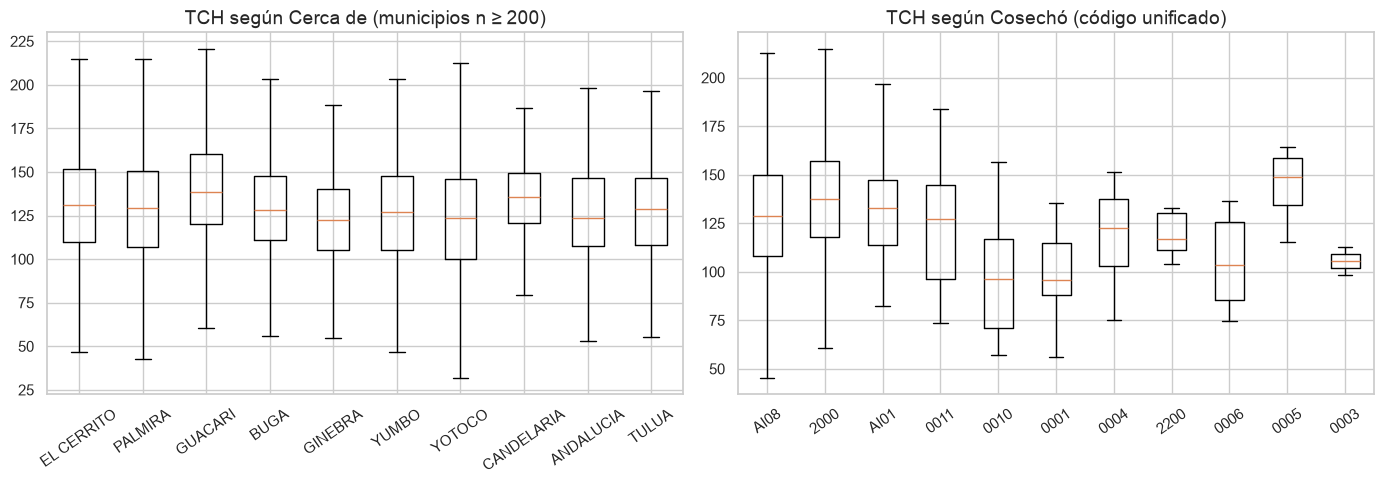

In [26]:
# Trazabilidad de extras sin ficha en el diccionario (no son fuga del paso 10).
# Flujo: 1 perfil → 2 consistencia DDUlt vs fechas → 3 anidamiento Cerca de–Zona → 4 boxplots TCH.
cols_sin_ficha = ["D.S.", "Cerca de", "Cosechó", "DDUlt.Riego", "Codigo Estacion"]


def ficha_sin_pdf(col):
    """Resumen de forma, nulos y asociación cruda con los dos targets (Pearson si numérica; medias si categórica)."""
    s = df_suertes[col]
    print(f"\n=== {col}  |  dtype={s.dtype}  |  nulos={s.isna().sum():,} ({100 * s.isna().mean():.1f}%)  |  niveles={s.nunique(dropna=True)} ===")
    if pd.api.types.is_numeric_dtype(s):
        print(s.describe().round(2).to_string())
        for y in ["TCH", "%Sac.Caña"]:
            pair = df_suertes[[col, y]].dropna()
            print(
                f"  vs {y}: n={len(pair):,}  "
                f"Pearson={pair[col].corr(pair[y]):.3f}  "
                f"Spearman={pair[col].corr(pair[y], method='spearman'):.3f}"
            )
        return
    vc = s.astype("string").str.strip().value_counts(dropna=False)
    print("Frecuencias (top 12):\n", vc.head(12).to_string())
    tmp = df_suertes[[col, "TCH", "%Sac.Caña"]].copy()
    tmp[col] = tmp[col].astype("string").str.strip().str.upper()
    g = (
        tmp.groupby(col, dropna=False)[["TCH", "%Sac.Caña"]]
        .agg(["mean", "count"])
        .sort_values(("TCH", "count"), ascending=False)
    )
    print("Medias por nivel (top 12 por n):\n", g.head(12).round(2).to_string())
    g30 = g[g[("TCH", "count")] >= 30]
    if len(g30):
        print(
            f"  TCH (n≥30): {g30[('TCH','mean')].min():.1f} … {g30[('TCH','mean')].max():.1f}  "
            f"(rango {g30[('TCH','mean')].max() - g30[('TCH','mean')].min():.1f} t/ha)"
        )


print("\n--- 1. Perfil: forma, nulos y asociación con TCH / %Sac.Caña ---")
for c in cols_sin_ficha:
    ficha_sin_pdf(c)

# 2. Consistencia: DDUlt.Riego = (F.Ult.Corte − Ult.Riego).days cuando hay fecha de riego
print("\n--- 2. Consistencia interna: DDUlt.Riego vs fechas de riego y corte ---")
ambas = df_suertes[["DDUlt.Riego", "Ult.Riego", "F.Ult.Corte"]].dropna()
delta = (ambas["F.Ult.Corte"] - ambas["Ult.Riego"]).dt.days
print(
    "\nDDUlt.Riego vs (F.Ult.Corte − Ult.Riego).days: "
    f"n={len(ambas):,}  Pearson={delta.corr(ambas['DDUlt.Riego']):.4f}  "
    f"|diff| medio={(delta - ambas['DDUlt.Riego']).abs().mean():.4f}"
)
print(
    "DDUlt.Riego = 0 cuando Ult.Riego es NA:",
    int((df_suertes.loc[df_suertes["Ult.Riego"].isna(), "DDUlt.Riego"] == 0).all()),
    f"(n NA riego = {df_suertes['Ult.Riego'].isna().sum():,})",
)

# 3. Anidamiento: el municipio (Cerca de) respecto a la zona del ingenio
print("\n--- 3. Anidamiento geográfico: Cerca de vs Zona ---")
print("\nCramér V Cerca de vs Zona:", round(cramers_v(df_suertes["Cerca de"].astype(str), df_suertes["Zona"].astype(str)), 3))
ct = pd.crosstab(df_suertes["Cerca de"].astype("string").str.strip(), df_suertes["Zona"].astype(str).str.upper())
modal = ct.max(axis=1) / ct.sum(axis=1)
print("Fracción del municipio en su zona modal: mediana", round(float(modal.median()), 3), "| media", round(float(modal.mean()), 3))
print("Excepción (menor anidamiento):", modal.idxmin(), f"{100 * modal.min():.1f}%")

# 4. Distribución de TCH: municipios frecuentes y frente de cosecha
print("\n--- 4. TCH por municipio (n ≥ 200) y por frente de cosecha ---")
cerca_n = df_suertes["Cerca de"].astype("string").str.strip().str.upper().value_counts()
muni_ok = cerca_n[cerca_n >= 200].index
df_muni = df_suertes.assign(_muni=df_suertes["Cerca de"].astype("string").str.strip().str.upper())
df_muni = df_muni[df_muni["_muni"].isin(muni_ok)]
df_frente = df_suertes.assign(_frente=df_suertes["Cosechó"].astype("string").str.upper())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
box_por(df_muni, "_muni", "TCH", axes[0], orden=list(cerca_n.loc[muni_ok].index))
axes[0].set_title("TCH según Cerca de (municipios n ≥ 200)")
box_por(df_frente, "_frente", "TCH", axes[1])
axes[1].set_title("TCH según Cosechó (código unificado)")
plt.tight_layout()
plt.show()


**Qué muestra este diagnóstico**

| Variable | Evidencia | Significado | Confianza / decisión |
|---|---|---|---|
| `D.S.` | 65.9 % nulos. Valores: `1.65` (7.148), `DS` (19), `1.5` (1). TCH 128.4 vs 130.2 t/ha entre `1.65` y NA (rango 1.8). En caña del Valle el **distanciamiento entre surcos** típico de cosecha mecánica es 1.50–1.75 m (Cenicaña); `1.65` encaja. `DS` no. | Inferido con confianza razonable como distanciamiento de siembra (m). Las 19 filas `DS` siguen ambiguas. | **Razonable.** **Fuera del lineal:** 66 % nulos y sin separación de TCH. |
| `Cerca de` | 31 valores = municipios del Valle y del norte del Cauca (`El Cerrito`, `Palmira`, `Guacarí`, `Corinto`, `Caloto`, …). 0.6 % nulos. TCH (n≥30): **Caloto 92.0** … **Guacarí 139.7** t/ha (rango **47.7**). Cramér vs `Zona` = **0.585**; mediana del municipio en una sola zona = 100 % (excepción `El Cerrito`, 42 % en IP06). El TCH bajo es sobre todo norte del Cauca (IP05). | Municipio/vereda cercana al lote. Hallazgo real, no ruido. | **Alta.** **Fuera de las 19 X** por anidamiento en `Zona` (31 dummies romperían un OLS interpretable). IP05 ya recoge el patrón Cauca. Queda como refinamiento geográfico. |
| `Cosechó` | Tras unificar mayúsculas (paso 5): `AI08` 92.4 % (19.425), `2000` 6.7 %, el resto <1 % (11 niveles). TCH: AI08 129.0 vs 2000 138.2 (n≥30). Códigos tipo frente (`AI08`, `AI01`, `0011`). | **Cuadrilla / contratista de cosecha.** | **Razonable.** **Fuera del lineal:** casi constante. El +9 t/ha de `2000` no justifica 11 dummies. |
| `DDUlt.Riego` | 0 nulos; 59.8 % ceros. Esos ceros son **exactamente** las 12.557 filas sin `Ult.Riego`. Donde hay fecha: `DDUlt.Riego` = (`F.Ult.Corte` − `Ult.Riego`).days con Pearson **1.000**. Vs TCH Pearson 0.093 / Spearman 0.062; vs sacarosa 0.027. | Días desde el último riego. | **Alta.** **Fuera del lineal** por señal débil y redundancia con `Num.Riegos` / `M3 Riego`. |
| `Codigo Estacion` | 70.1 % nulos (umbral del paso 3). 20 códigos (`GUA`, `GIN`, `BUG`, `PRA`, `999`…). Varios coinciden con el municipio (`BUG`→Buga, `PRA`→Pradera); `999` es un cajón. | Estación meteorológica del ingenio. | **Ambigua residual.** **Fuera** por nulos ≥70 %. Las lluvias del lote (`Lluvias Ciclo`, 2 meses) ya sustituyen la estación vacía. |

**Hallazgo.** `Cerca de` mueve el TCH a escala de municipio (~48 t/ha entre grupos con n≥30). No entra al OLS porque colinea con `Zona` y explota el número de dummies. Si se reabre el set, el candidato geográfico fino es este, no `Codigo Estacion`.

**Ambigüedad residual.** No queda determinado con certeza el significado operacional de `D.S.` en las filas nulas o marcadas `DS`, ni el de `Codigo Estacion` cuando falta o vale `999`. Se excluyen por precaución. `Cerca de`, `Cosechó` y `DDUlt.Riego` sí se interpretaron; salen del lineal por redundancia o poca señal.


**Traspaso al notebook de modelos**

`df_suertes` se guarda en `datos/suertes_limpio.parquet` para `02_modelos_regresion.ipynb`.

- **Lleva** solo transformaciones **sin estado**, que dan el mismo resultado por fila con o sin el resto del histórico: tipado (`Suerte` como texto), placeholders → NaN (paso 3), mayúsculas y espacios en `Zona`, `Cosechó`, `Suelo` y `Producto` (paso 5) y `edad_desde_siembra` (paso 8).
- **No lleva** imputaciones, agrupación de colas por frecuencia ni dummies. `df_vif` y `df_modelo` (pasos 12–13) usan medianas de todas las filas y solo sirven de diagnóstico; los estadísticos del lineal se estiman en train (paso 16).
- Los datos no se suben al repositorio: `datos/` está en `.gitignore`.


In [27]:
# Traspaso al notebook 02: histórico con transformaciones sin estado y nulos originales.
# Orden: 1 guardar → 2 releer → 3 comprobar igualdad.
from pathlib import Path

RUTA_SUERTES = Path("datos/suertes_limpio.parquet")
RUTA_SUERTES.parent.mkdir(exist_ok=True)
df_suertes.to_parquet(RUTA_SUERTES)

df_chk = pd.read_parquet(RUTA_SUERTES)
pd.testing.assert_frame_equal(df_suertes, df_chk)   # ida y vuelta sin cambios de valor, tipo ni índice

print("Guardado:", RUTA_SUERTES, "| filas × columnas =", df_suertes.shape)
print("Nulos originales (sin imputar): Semanas mad. =", int(df_suertes["Semanas mad."].isna().sum()),
      "| Num.Riegos =", int(df_suertes["Num.Riegos"].isna().sum()),
      "| Dosis Madurante =", int(df_suertes["Dosis Madurante"].isna().sum()),
      "| Suelo =", int(df_suertes["Suelo"].isna().sum()))


Guardado: datos/suertes_limpio.parquet | filas × columnas = (21027, 86)
Nulos originales (sin imputar): Semanas mad. = 9775 | Num.Riegos = 12589 | Dosis Madurante = 104 | Suelo = 3758
